# 28-Day Retail Demand Forecasting (TX3 · Food3)
## Applied Forecasting in Complex Systems
By By María González Alegre (14008696), Amelia Soare (15343480) , Djamel Zair (11015934), Samuele Walzer
(15612767).
### Introduction
We forecast **daily unit sales** for each Food3 item in the TX3 store for the next **28 days (F1–F28)**.

The practical question is: **which approach produces the most accurate 28-day-ahead forecasts for this dataset?**

### Hypotheses
1. **H1 :** Across all items, a **tree-based gradient boosting model** trained on lag + calendar/price features will perform better than (lower **RMSE/MAE**) than simple baselines (naïve, seasonal naïve, moving averages) on the 28-day hold-out window.

2. **H2 :** The improvement from the tree-based model depends on **intermittency level** (how often an item has zero sales). 

### Evaluation mapped to the hypotheses
We use a **time-based hold-out**: the **last 28 days** are used for validation (matching F1–F28).

**Evaluate H1**  
Compute **overall RMSE and MAE** on the 28-day hold-out for two approaches.  
First, the best simple baseline.  
Second, the tree-based gradient boosting model.  
H1 is supported if the tree-based model has lower RMSE and MAE than the best baseline.

**Evaluate H2**  
Define four **intermittency groups** using each item’s **zero-share** in the training history, meaning the fraction of days with sales equal to zero.  
For each group, compute RMSE and MAE for the best baseline and for the tree-based model.  
Report the per-group improvement as baseline RMSE minus tree RMSE, and baseline MAE minus tree MAE.  
H2 is supported if these improvements differ across groups, meaning some intermittency levels benefit more than others.

Finally, we run a **true 28-step recursive evaluation** as an additional realism check, because multi-step forecasts feed earlier predictions into later lag features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import Dict, Tuple

from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, make_scorer
import warnings


sns.set_theme(style="whitegrid", palette="viridis")

## Load data
Keeps everything relative to the repository root so the notebook runs in-place.

In [2]:
DATA_DIR = Path("data")

calendar = pd.read_csv(DATA_DIR / "calendar_afcs2025.csv")
sell_prices = pd.read_csv(DATA_DIR / "sell_prices_afcs2025.csv")
sales_train_validation = pd.read_csv(DATA_DIR / "sales_train_validation_afcs2025.csv")

## Feature dataset (reuse from EDA)

We reuse the feature-engineering pipeline developed in the EDA notebook.  
This pipeline reshapes the sales data to long format, joins calendar variables and weekly sell prices, and adds lag features (lag 1, 7, 28).  
The resulting dataset is saved as `sales_features_with_calendar_prices.csv` and used for the forecasting models below.


In [3]:
# Feature table cache: load if it exists and is complete, otherwise build it once and save it

FEATURES_PATH = DATA_DIR / "sales_features_with_calendar_prices.csv"
FORCE_REBUILD_FEATURES = True

def build_sales_long_features():
    # Data prep: add d_index, melt, join calendar & prices, price fill, lags, rolling features, save feature CSV
    calendar_df = calendar.copy()
    calendar_df["d_index"] = calendar_df.index + 1

    day_cols_all = [c for c in sales_train_validation.columns if c.startswith("d_")]
    id_cols = [c for c in sales_train_validation.columns if c not in day_cols_all]

    sales_long = sales_train_validation.melt(
        id_vars=id_cols,
        value_vars=day_cols_all,
        var_name="d_col",
        value_name="sales"
    )

    sales_long["d_index"] = sales_long["d_col"].str.replace("d_", "", regex=False).astype(int)
    sales_long = sales_long.merge(calendar_df, on="d_index", how="left")

    sales_long["base_id"] = (
        sales_long["id"]
        .str.replace("_validation$", "", regex=True)
        .str.replace("_evaluation$", "", regex=True)
    )

    parts = sales_long["base_id"].str.split("_", expand=True)
    sales_long["item_id"] = parts[0] + "_" + parts[1] + "_" + parts[2]
    sales_long["store_id"] = parts[3] + "_" + parts[4]
    sales_long = sales_long.drop(columns=["base_id"])

    sales_long = sales_long.merge(
        sell_prices,
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left"
    )

    sales_long = sales_long.sort_values(["store_id", "item_id", "d_index"])

    # Flag missing prices before filling
    sales_long["sell_price_was_missing"] = sales_long["sell_price"].isna().astype(int)
    missing_before = float(sales_long["sell_price_was_missing"].mean())

    # Forward fill then backward fill prices within each (store_id, item_id)
    sales_long["sell_price"] = (
        sales_long.groupby(["store_id", "item_id"])["sell_price"]
        .transform(lambda s: s.ffill().bfill())
    )
    missing_after = float(sales_long["sell_price"].isna().mean())

    # Compute price change after filling
    sales_long["price_change"] = (
        sales_long.groupby(["store_id", "item_id"])["sell_price"].diff()
    )

    # Lags for sales per series id
    sales_long = sales_long.sort_values(["id", "d_index"])
    for lag in [1, 7, 28]:
        sales_long[f"lag_{lag}"] = sales_long.groupby("id")["sales"].shift(lag)

    # Rolling features based on lagged sales to avoid leakage
    sales_long["sales_lag1"] = sales_long.groupby("id")["sales"].shift(1)
    for window in [7, 28]:
        sales_long[f"roll_mean_{window}"] = (
            sales_long.groupby("id")["sales_lag1"].transform(lambda s: s.rolling(window).mean())
        )
        sales_long[f"roll_std_{window}"] = (
            sales_long.groupby("id")["sales_lag1"].transform(lambda s: s.rolling(window).std())
        )
    sales_long = sales_long.drop(columns=["sales_lag1"])

    sales_long.to_csv(FEATURES_PATH, index=False)

    print(f"Built + saved feature dataset: {FEATURES_PATH} shape={sales_long.shape}")
    print("Sell_price missingness before fill:", missing_before)
    print("Sell_price missingness after fill:", missing_after)
    print("sell_price_was_missing value counts:")
    print(sales_long["sell_price_was_missing"].value_counts(dropna=False))

    return sales_long

# Determine the required last day from the wide training data
required_last_day = max(int(c.replace("d_", "")) for c in sales_train_validation.columns if c.startswith("d_"))

if FEATURES_PATH.exists() and not FORCE_REBUILD_FEATURES:
    sales_long = pd.read_csv(FEATURES_PATH)
    sales_long["d_index"] = sales_long["d_index"].astype(int)
    max_d = int(sales_long["d_index"].max())
    print(f"Loaded cached feature dataset: {FEATURES_PATH} shape={sales_long.shape} | max d_index={max_d}")

    if max_d < required_last_day:
        print(
            f"Cache is incomplete (max d_index={max_d} < required {required_last_day}). Rebuilding..."
        )
        sales_long = build_sales_long_features()
else:
    if FEATURES_PATH.exists() and FORCE_REBUILD_FEATURES:
        print(f"Forcing feature rebuild and overwriting: {FEATURES_PATH}")
    sales_long = build_sales_long_features()

display(sales_long.head())


Forcing feature rebuild and overwriting: data/sales_features_with_calendar_prices.csv
Built + saved feature dataset: data/sales_features_with_calendar_prices.csv shape=(1574399, 27)
Sell_price missingness before fill: 0.20819500012385678
Sell_price missingness after fill: 0.0
sell_price_was_missing value counts:
sell_price_was_missing
0    1246617
1     327782
Name: count, dtype: int64


,id,d_col,sales,d_index,date,wm_yr_wk,weekday,wday,month,year,...,sell_price,sell_price_was_missing,price_change,lag_1,lag_7,lag_28,roll_mean_7,roll_std_7,roll_mean_28,roll_std_28
0,FOODS_3_001_TX_3_validation,d_1,0,1,1/29/2011,11101,Saturday,1,1,2011,...,2.28,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
823,FOODS_3_001_TX_3_validation,d_2,2,2,1/30/2011,11101,Sunday,2,1,2011,...,2.28,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1646,FOODS_3_001_TX_3_validation,d_3,1,3,1/31/2011,11101,Monday,3,1,2011,...,2.28,0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2469,FOODS_3_001_TX_3_validation,d_4,3,4,2/1/2011,11101,Tuesday,4,2,2011,...,2.28,0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3292,FOODS_3_001_TX_3_validation,d_5,0,5,2/2/2011,11101,Wednesday,5,2,2011,...,2.28,0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


## Metrics and plotting helpers

In [4]:

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def make_train_val_frames(sales_df: pd.DataFrame, horizon: int = 28):
    d_cols = [c for c in sales_df.columns if c.startswith("d_")]
    ids = sales_df["id"].astype(str).values

    Y = sales_df[d_cols].astype(float).to_numpy()
    T = Y.shape[1]
    train_T = T - horizon

    train_cols = d_cols[:train_T]
    val_cols = d_cols[train_T:]

    train_df = pd.DataFrame(Y[:, :train_T], index=ids, columns=train_cols)
    val_df = pd.DataFrame(Y[:, train_T:], index=ids, columns=val_cols)

    return train_df, val_df

def pred_naive(train_df: pd.DataFrame, horizon: int):
    last = train_df.iloc[:, -1].to_numpy(dtype=float)
    return np.repeat(last[:, None], horizon, axis=1)

def pred_seasonal_naive(train_df: pd.DataFrame, horizon: int, season: int = 7):
    last_season = train_df.iloc[:, -season:].to_numpy(dtype=float)
    reps = int(np.ceil(horizon / season))
    tiled = np.tile(last_season, reps)
    return tiled[:, :horizon]

def pred_moving_average(train_df: pd.DataFrame, horizon: int, window: int = 7):
    avg = train_df.iloc[:, -window:].to_numpy(dtype=float).mean(axis=1)
    return np.repeat(avg[:, None], horizon, axis=1)

def summarize_baselines(train_df: pd.DataFrame, val_df: pd.DataFrame):
    h = val_df.shape[1]

    preds = {
        "Naive last value": pred_naive(train_df, h),
        "Seasonal naive period 7": pred_seasonal_naive(train_df, h, season=7),
        "Moving average window 7": pred_moving_average(train_df, h, window=7),
        "Moving average window 28": pred_moving_average(train_df, h, window=28),
    }

    Y_val = val_df.to_numpy(dtype=float)

    rows = []
    for name, P in preds.items():
        rows.append({
            "model": name,
            "RMSE": rmse(Y_val, P),
            "MAE": mae(Y_val, P),
        })

    return pd.DataFrame(rows).sort_values("RMSE"), preds

def relative_error_context(val_df: pd.DataFrame, pred: np.ndarray):
    y = val_df.to_numpy(dtype=float)
    mean_level = float(np.mean(y))
    rmse_val = rmse(y, pred)
    mae_val = mae(y, pred)

    return pd.DataFrame([{
        "val_mean_units": mean_level,
        "RMSE": rmse_val,
        "MAE": mae_val,
        "RMSE_over_mean": rmse_val / mean_level if mean_level != 0 else np.nan,
        "MAE_over_mean": mae_val / mean_level if mean_level != 0 else np.nan,
    }])

def plot_forecast_item(item_id: str, train_df: pd.DataFrame, val_df: pd.DataFrame, pred: np.ndarray, tail: int = 120, title: str = None):
    if item_id not in train_df.index:
        raise ValueError(f"item_id not found in train_df index: {item_id}")

    # Align predictions to the validation frame so positional vs label lookups can't mismatch
    pred_df = _to_pred_df(pred, index=val_df.index, columns=val_df.columns, name="pred")

    y_train = train_df.loc[item_id].astype(float)
    y_val = val_df.loc[item_id].astype(float)
    y_pred = pred_df.loc[item_id].astype(float).to_numpy()

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(14, 4))
    plt.plot(x_train, train_tail.values, label="train")
    plt.plot(x_val, y_val.values, label="val")
    plt.plot(x_val, y_pred, label="pred")
    plt.title(title if title is not None else item_id)
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.legend()
    plt.grid(True)
    plt.show()
    
def nice_ts_plot(x, y, title, xlabel, ylabel, figsize=(12, 3)):
    plt.figure(figsize=figsize)
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

def plot_acf_nice(series, lags=35, title=None, figsize=(10, 3), drop_lag0=True):

    x = np.asarray(series, dtype=float)
    fig, ax = plt.subplots(figsize=figsize)

    plot_acf(x, lags=lags, ax=ax, zero=not drop_lag0)

    if title is not None:
        ax.set_title(title)

    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Autocorrelation")

    # Make y-limits a bit less cramped when lag0 is shown
    if not drop_lag0:
        ax.set_ylim(-1.0, 1.05)

    ax.grid(True)
    plt.show()

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


 
# Palette (as you requested)
# ----------------------------
TEAL    = "#1663A2"
MAGENTA = "#BC1052"
GOLD    = "#34676F"
BLUEISH = "#CCAA00"
GRAY    = "#4D4D4D"

# ----------------------------
# Small helpers
# ----------------------------
def _to_pred_df(P, index, columns, name="pred"):
    """
    Convert predictions to a DataFrame aligned to (index, columns).
    Accepts np.ndarray or pd.DataFrame.
    """
    if isinstance(P, pd.DataFrame):
        # Reindex explicitly (prevents silent mismatch)
        return P.reindex(index=index, columns=columns)
    P = np.asarray(P, dtype=float)
    if P.shape != (len(index), len(columns)):
        raise ValueError(f"{name} has shape {P.shape}, expected {(len(index), len(columns))}.")
    return pd.DataFrame(P, index=index, columns=columns)

def horizon_rmse(y_true, y_pred):
    """RMSE per horizon day (axis=0)."""
    err2 = (y_true - y_pred) ** 2
    return np.sqrt(np.mean(err2, axis=0))

def plot_horizon_lines(h, series_dict, title, ylabel="RMSE"):
    plt.figure(figsize=(7.2, 2.8))

    for label, (vals, color, ls) in series_dict.items():
        plt.plot(h, vals, linewidth=2.0, color=color, linestyle=ls, label=label)

    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Horizon day", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, alpha=0.2)

    # legend at the top, clean, one row
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.30),
        ncol=min(4, len(series_dict)),
        frameon=False,
        handlelength=2.6,
        columnspacing=1.2
    )

    # leave extra space for the top legend
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

def plot_group_bar(df, metric="RMSE", title=None):
    x = np.arange(len(df))
    colors = [MAGENTA, TEAL, BLUEISH, GOLD][:len(df)]

    plt.figure(figsize=(7.2, 2.8))
    plt.bar(x, df[metric].astype(float).values, color=colors, alpha=0.95)
    plt.xticks(x, df["group"].astype(str).values, rotation=18, ha="right")
    plt.ylabel(metric, fontsize=11)
    plt.title(title or f"{metric} by intermittency group", fontsize=12, fontweight="bold")
    plt.grid(True, axis="y", alpha=0.2)

    # annotate best model on top of bars
    for i, row in df.reset_index(drop=True).iterrows():
        txt = str(row.get("best_model", ""))
        if txt and txt != "nan":
            plt.text(i, float(row[metric]) * 1.01, txt, ha="center", va="bottom", fontsize=9, color=GRAY)

    plt.tight_layout()
    plt.show()

def resolve_item_id(rid, df):
    # if rid is already a label, we’re good
    if rid in df.index:
        return rid

    # if rid looks like a positional index, convert it
    if isinstance(rid, (int, np.integer)):
        i = int(rid)
        if 0 <= i < len(df.index):
            return df.index[i]

    # otherwise: we actually don't know what this id is
    raise KeyError(f"Item id {rid} not found in index, and not a valid positional index either.")



## Validation (train/val split)
This section evaluates models on the last 28 days of the training data (d_1914..d_1941).


In [5]:
# Evidence for H2 setup: define intermittency groups and summarize price missingness
import numpy as np
import pandas as pd

df = sales_long.sort_values(["id", "d_index"]).copy()

# rolling means of sales (past only)
df["roll_mean_7"]  = df.groupby("id")["sales"].transform(lambda s: s.shift(1).rolling(7).mean())
df["roll_mean_28"] = df.groupby("id")["sales"].transform(lambda s: s.shift(1).rolling(28).mean())

# rolling zero-share (past only)
df["roll_zero_share_28"] = df.groupby("id")["sales"].transform(lambda s: s.shift(1).rolling(28).apply(lambda x: np.mean(x==0), raw=True))

# time since last sale (past only)
def time_since_last_sale(s):
    last = -1
    out = np.empty(len(s), dtype=float)
    for i, v in enumerate(s.values):
        out[i] = (i - last) if last != -1 else np.nan
        if v > 0:
            last = i
    return pd.Series(out, index=s.index)

df["time_since_sale"] = df.groupby("id")["sales"].apply(time_since_last_sale).reset_index(level=0, drop=True)

sales_long = df 
# Wide train matrix for zero-share is best (no leakage from validation)
train_wide, val_wide = make_train_val_frames(sales_train_validation, horizon=28)
Y_train = train_wide.to_numpy(dtype=float)

# Zero share per item
zero_share = (Y_train == 0).mean(axis=1)
zero_share = pd.Series(zero_share, index=train_wide.index, name="zero_share")

# Define 4 groups by quartiles
q25, q50, q75 = zero_share.quantile([0.25, 0.50, 0.75]).values
print("Zero-share cut points (quartiles):")
print(f"25%: {q25:.3f} | 50%: {q50:.3f} | 75%: {q75:.3f}")

def bucket(z):
    if z <= q25:
        return "G1 low intermittency"
    elif z <= q50:
        return "G2 medium intermittency"
    elif z <= q75:
        return "G3 high intermittency"
    else:
        return "G4 very high intermittency"

groups = zero_share.apply(bucket)

print("\nGroup counts:")
display(groups.value_counts().rename("n_items").to_frame())

print("\nZero-share summary:")
print(zero_share.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).to_string())

# Price missingness summary (only if sales_long exists at this point)
if "sales_long" in globals() and "sell_price_was_missing" in sales_long.columns:
    print("\nSell price missingness (before imputation flag):")
    print(f"Overall share of rows with missing price: {sales_long['sell_price_was_missing'].mean():.3f}")
    print("Per-series missingness summary:")
    per_series_price_missing = sales_long.groupby("id")["sell_price_was_missing"].mean()
    print(per_series_price_missing.describe(percentiles=[0.10, 0.50, 0.90]).to_string())
else:
    print("\nNote: sales_long not available yet, skipping price-missingness summary.")


Zero-share cut points (quartiles):
25%: 0.459 | 50%: 0.665 | 75%: 0.825

Group counts:


,n_items
zero_share,
G4 very high intermittency,206
G2 medium intermittency,206
G1 low intermittency,206
G3 high intermittency,205



Zero-share summary:
count    823.000000
mean       0.623266
std        0.243583
min        0.003183
10%        0.259841
25%        0.459151
50%        0.664721
75%        0.824668
90%        0.905570
max        0.985676

Sell price missingness (before imputation flag):
Overall share of rows with missing price: 0.208
Per-series missingness summary:
count    823.000000
mean       0.208195
std        0.249883
min        0.000000
10%        0.000000
50%        0.047569
90%        0.592786
max        0.881861


In [6]:
# Print feature columns available at this point
exclude_cols = {"id", "d_index", "d_col", "sales"}
feature_cols = [c for c in sales_long.columns if c not in exclude_cols]

print("\nFeature columns in sales_long:")
for c in feature_cols:
    print("-", c)



Feature columns in sales_long:
- date
- wm_yr_wk
- weekday
- wday
- month
- year
- event_name_1
- event_type_1
- event_name_2
- event_type_2
- snap_TX
- item_id
- store_id
- sell_price
- sell_price_was_missing
- price_change
- lag_1
- lag_7
- lag_28
- roll_mean_7
- roll_std_7
- roll_mean_28
- roll_std_28
- roll_zero_share_28
- time_since_sale


## What these data characteristics imply for our modelling choices

Intermittency is substantial at item level. The median (most common) item has zero sales on about two thirds of days, and a large fraction of items have zero sales on more than 80 percent of days. Therefore most of the data can be seen as sparse.  
This motivates two design choices:

1. We include simple seasonal baselines and lag features as reference methods, because they capture predictable weekly structure without overfitting sparse item histories.

2. We evaluate performance by intermittency group, because a single overall RMSE can hide that some models work well only for low intermittency items.

Weekly sell prices are also sometimes missing at source. About 21 percent of price rows are missing before imputation, so we keep the missingness flag sell_price_was_missing to separate observed versus imputed price periods when using price as a feature.


## Quick weekly seasonality check (Already Seen in EDA)
### (justifies season = 7 baselines and lag_7 feature, already seen in EDA)
Before running baselines, we verify whether there is a weekly pattern at the store level.  
We plot aggregated daily total sales across all items and the autocorrelation function (ACF).  

This check is done on the full dataset rather than per intermittency group, because it supports global design choices (seasonal baseline with period 7 and lag_7 feature).  
Intermittency groups are used later for evaluation (H2), not for selecting the seasonal period.


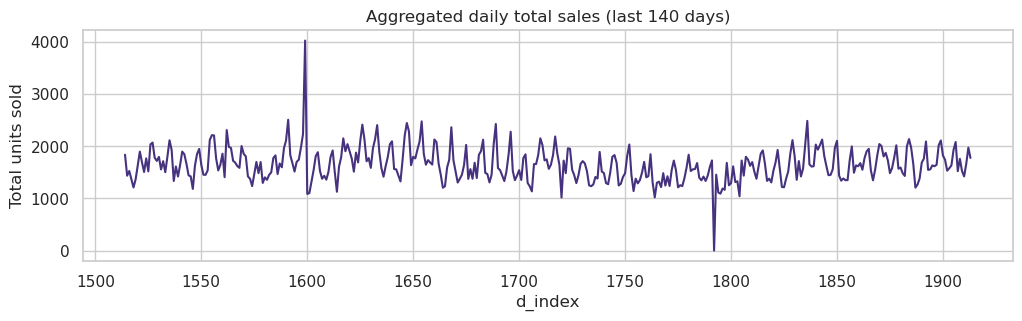

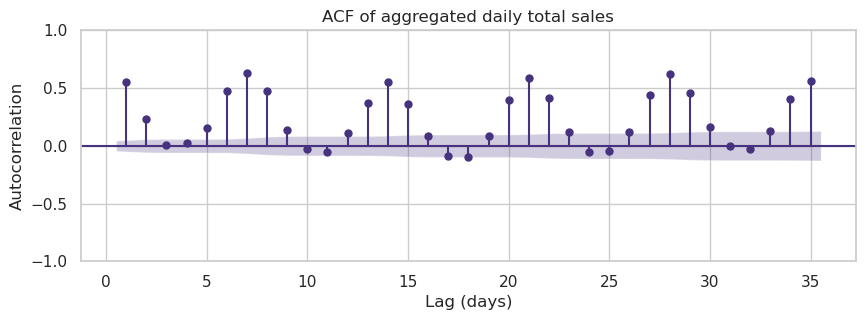

In [7]:
# Weekly structure at aggregate level (supports season=7 baselines and lag_7 feature)

d_cols = [c for c in sales_train_validation.columns if c.startswith("d_")]

daily_total = sales_train_validation[d_cols].astype(float).sum(axis=0)
daily_total.index = daily_total.index.str.replace("d_", "", regex=False).astype(int)
daily_total = daily_total.sort_index()

# Last 140 days (~20 weeks)
x = daily_total.index[-400:]
y = daily_total.values[-400:]
nice_ts_plot(
    x=x,
    y=y,
    title="Aggregated daily total sales (last 140 days)",
    xlabel="d_index",
    ylabel="Total units sold"
)

plot_acf_nice(
    daily_total.values,
    lags=35,
    title="ACF of aggregated daily total sales"
)


## Baseline forecasts 

We validate with a **time-based split** that matches the task: the **last 28 days (F1–F28)** are held out.

Before training any model, we compute **simple rule-based forecasts** that require **no fitting / no learning**:
- **Naïve**: predict each future day as the last observed value.
- **Seasonal naïve (7)**: repeat the last observed week (weekly seasonality).
- **Moving average (7 / 28)**: predict the mean of the last 7 or 28 observed days.

These baselines answer a concrete question:  
**“If we do not train a statistical or ML model and only extrapolate from recent history, how large is the forecast error?”**

**How this tests our hypothesis:**  

**H1 (beats baselines)**  
Baselines are our “no-learning” reference. They answer:  
If we only extrapolate from recent sales history, how large is the 28-day forecast error?  
H1 is supported only if the learned tree-based model achieves **lower RMSE and MAE** than the **best baseline** on the same 28-day hold-out window.

**H2 (intermittency sensitivity)**  
Overall error can hide that some items are easy and others are hard.  
To support H2, we inspect baseline behaviour across **four intermittency groups** defined by each item’s **zero-share** (fraction of days with zero sales).  
We plot one representative item per group (low, medium, high, very high intermittency) to show where smoothing baselines work (stable demand) and where they fail (spikes and long zero stretches).

### Baseline forecasts (H1)

We validate with a **time-based split** that matches the task: the **last 28 days (F1–F28)** are held out.

Before training any statistical or ML model, we compute **rule-based baselines** that require **no fitting / no learning**:
- **Naïve**: predict each future day as the last observed value.
- **Seasonal naïve (7)**: repeat the last observed week.
- **Moving average (7 / 28)**: predict the mean of the last 7 or 28 days.

These baselines establish the **minimum performance bar** for H1.  
H1 is supported only if the learned tree-based model achieves **lower RMSE and MAE** than the **best baseline** on the same 28-day hold-out window.

**WE EXPECT** that Moving Average would perform the best, since the data has no upward or downward trend so its mean does not substantially change. 


In [8]:


# SARIMAX per-item predictor (safe + quiet)
def pred_sarimax_per_item(
    train_df: pd.DataFrame,
    horizon: int,
    order=(1, 0, 0),
    seas=(0, 1, 1, 7),
    maxiter: int = 50,
):
    preds_list = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # hide ConvergenceWarning spam
        for _, row in train_df.iterrows():
            y = pd.to_numeric(row, errors="coerce").fillna(0.0).to_numpy(dtype=float)
            try:
                m = SARIMAX(
                    y,
                    order=order,
                    seasonal_order=seas,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                res = m.fit(disp=False, maxiter=maxiter)
                fc = res.forecast(horizon)
                fc = np.asarray(fc, dtype=float)
            except Exception:
                fc = np.repeat(y[-1], horizon)  # fallback
            fc = np.maximum(fc, 0.0)
            preds_list.append(fc)
    return np.vstack(preds_list)

# Build baseline preds dictionary INCLUDING SARIMAX (hopefully cached)
h = val_wide.shape[1]

SARIMAX_CACHE = DATA_DIR / "sarimax_val_preds.npy"

if SARIMAX_CACHE.exists():
    sarimax_pred = np.load(SARIMAX_CACHE)
    if sarimax_pred.shape != (train_wide.shape[0], h):
        print("SARIMAX cache shape mismatch, recomputing...")
        sarimax_pred = pred_sarimax_per_item(train_wide, h)
        np.save(SARIMAX_CACHE, sarimax_pred)
else:
    sarimax_pred = pred_sarimax_per_item(train_wide, h)
    np.save(SARIMAX_CACHE, sarimax_pred)

preds = {
    "Naive last value": pred_naive(train_wide, h),
    "Seasonal naive period 7": pred_seasonal_naive(train_wide, h, season=7),
    "Moving average window 7": pred_moving_average(train_wide, h, window=7),
    "Moving average window 28": pred_moving_average(train_wide, h, window=28),
    "SARIMAX(1,0,0)(0,1,1)[7]": sarimax_pred,
}

# Create baseline_table from preds (overall metrics)
Y_val = val_wide.to_numpy(dtype=float)

rows = []
for name, P in preds.items():
    rows.append({
        "model": name,
        "RMSE": rmse(Y_val, P),
        "MAE": mae(Y_val, P),
    })

baseline_table = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(baseline_table)

# Best baseline
best_name = baseline_table.loc[0, "model"]
best_pred = preds[best_name]

best_baseline_rmse = float(baseline_table.loc[0, "RMSE"])
best_baseline_mae  = float(baseline_table.loc[0, "MAE"])

print("Stored best baseline metrics for later ML comparison (H1).")
print(f"Best baseline: {best_name} | RMSE={best_baseline_rmse:.4f} | MAE={best_baseline_mae:.4f}")

print("Context for best baseline")
display(relative_error_context(val_wide, best_pred))


,model,RMSE,MAE
0,"SARIMAX(1,0,0)(0,1,1)[7]",2.649734,1.345333
1,Moving average window 28,2.801208,1.346812
2,Moving average window 7,2.951324,1.359889
3,Seasonal naive period 7,3.723713,1.604018
4,Naive last value,4.291501,1.757377


Stored best baseline metrics for later ML comparison (H1).
Best baseline: SARIMAX(1,0,0)(0,1,1)[7] | RMSE=2.6497 | MAE=1.3453
Context for best baseline


,val_mean_units,RMSE,MAE,RMSE_over_mean,MAE_over_mean
0,2.046823,2.649734,1.345333,1.294559,0.657278


## Baseline performance by intermittency group (H2)

To test whether forecast difficulty also depends on intermittency, and if they require different handling techniques, we group items by **zero-share**: the fraction of days in the training window with zero sales.  
we use quartiles to form four equally-sized groups (low, medium, high, very high intermittency).

For each group, we report RMSE/MAE for the **best baseline** and plot one representative item from the group to show typical behaviour.


Zero-share cut points (train only): 25%=0.459 | 50%=0.665 | 75%=0.825


,n_items
zero_share,
G4 very high intermittency,206
G2 medium intermittency,206
G1 low intermittency,206
G3 high intermittency,205


,group,n_items,zero_share_mean,best_model,RMSE,MAE
0,G1 low intermittency,206,0.275491,"SARIMAX(1,0,0)(0,1,1)[7]",4.408876,2.596009
1,G2 medium intermittency,206,0.573104,Moving average window 7,2.277720,1.344289
2,G3 high intermittency,205,0.749946,Moving average window 7,1.378928,0.793031
3,G4 very high intermittency,206,0.895138,Moving average window 7,0.990619,0.537250


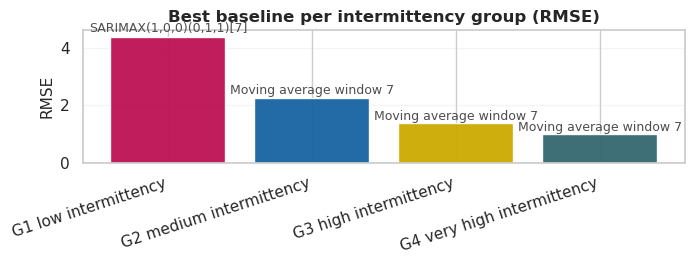

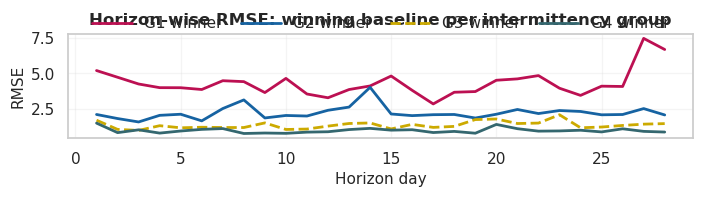

Representative items (median zero-share per group):
G1 low intermittency: FOODS_3_811_TX_3_validation | zero_share=29.5% | best_baseline_in_group=SARIMAX(1,0,0)(0,1,1)[7]
G2 medium intermittency: FOODS_3_248_TX_3_validation | zero_share=58.0% | best_baseline_in_group=Moving average window 7
G3 high intermittency: FOODS_3_031_TX_3_validation | zero_share=75.5% | best_baseline_in_group=Moving average window 7
G4 very high intermittency: FOODS_3_262_TX_3_validation | zero_share=89.4% | best_baseline_in_group=Moving average window 7


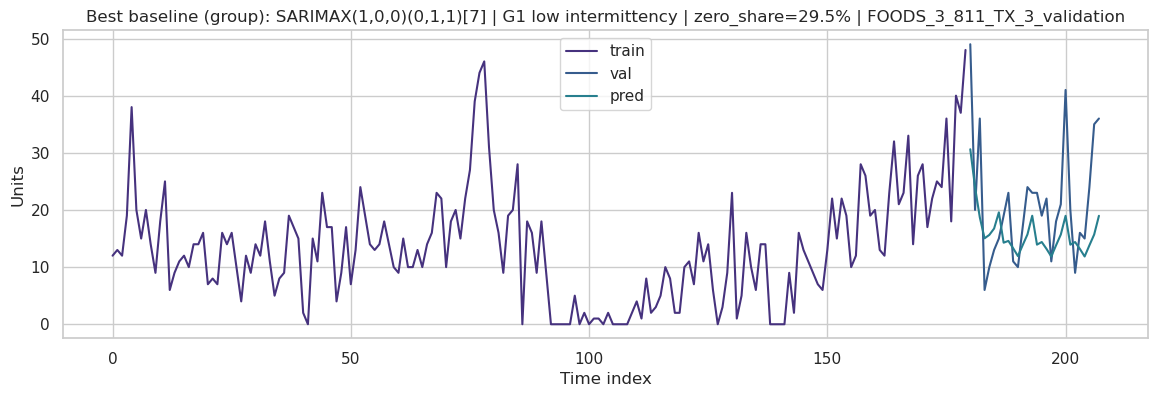

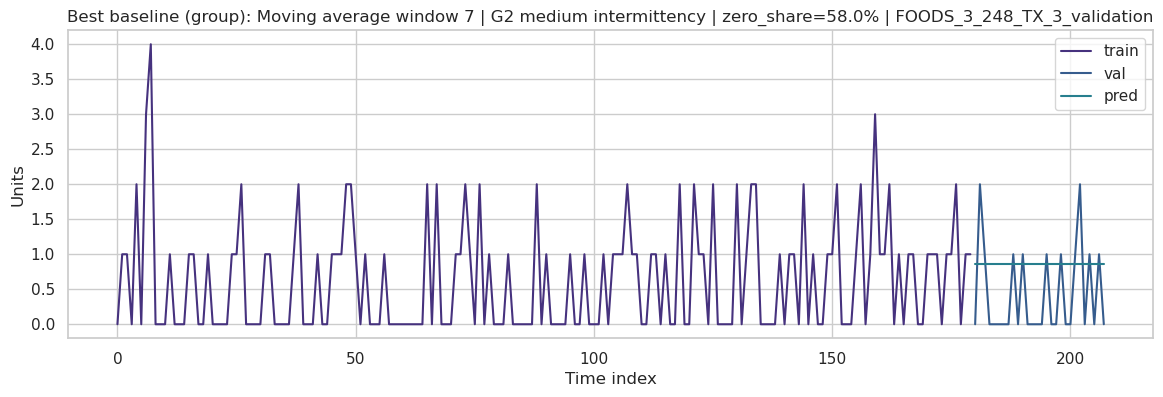

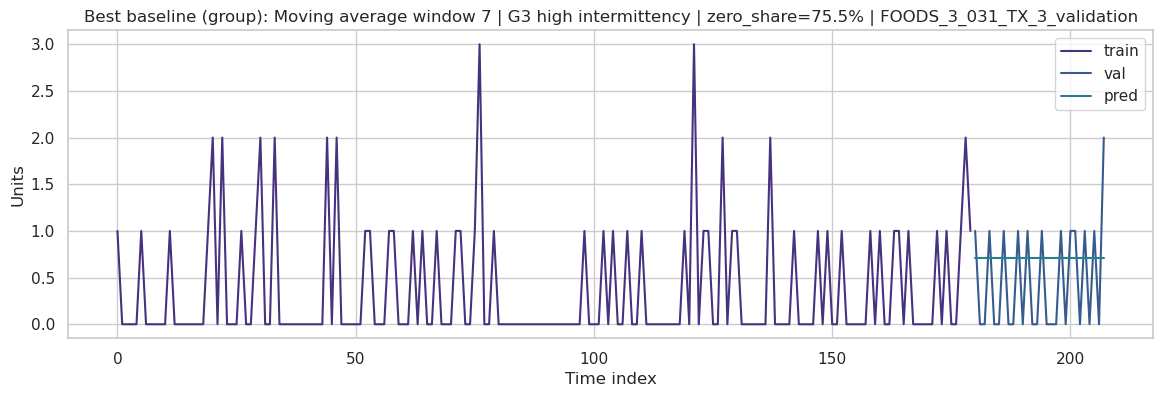

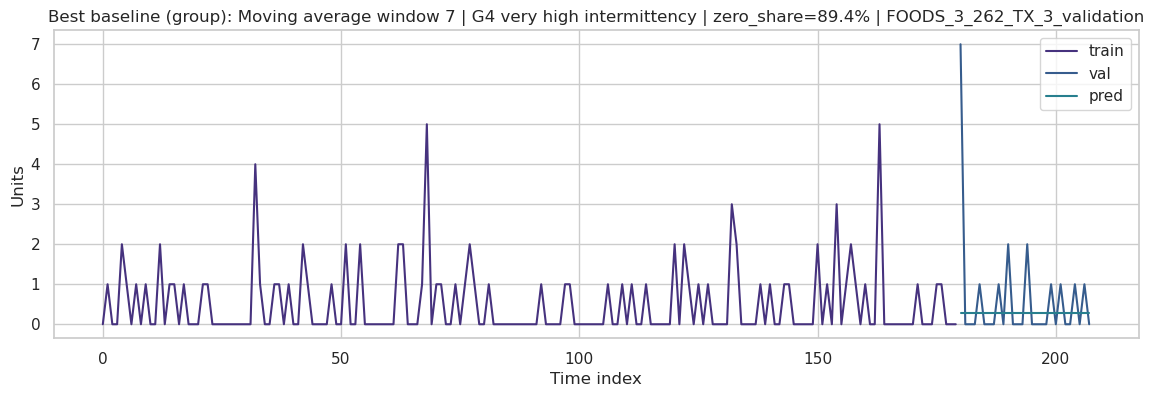

In [9]:


H = val_wide.shape[1]
h = np.arange(1, H + 1)

# If train_wide and val_wide aren’t in the exact same order, everything becomes chaos,
# so we guard that once here.
if not train_wide.index.equals(val_wide.index):
    raise ValueError("train_wide.index and val_wide.index must match exactly for this block.")

# We define intermittency using only the train window (so we don’t peek at the validation horizon)
Y_train = train_wide.to_numpy(dtype=float)
zero_share = pd.Series((Y_train == 0).mean(axis=1), index=train_wide.index, name="zero_share")

q25, q50, q75 = zero_share.quantile([0.25, 0.50, 0.75]).values

def bucket(z):
    if z <= q25:
        return "G1 low intermittency"
    elif z <= q50:
        return "G2 medium intermittency"
    elif z <= q75:
        return "G3 high intermittency"
    else:
        return "G4 very high intermittency"

groups = zero_share.apply(bucket)

print(f"Zero-share cut points (train only): 25%={q25:.3f} | 50%={q50:.3f} | 75%={q75:.3f}")
display(groups.value_counts().rename("n_items").to_frame())

# This is the big practical fix: we align every prediction matrix to val_wide’s index/columns.
# That way our group scoring is actually correct, even if a pred got created in a different order.
preds_df = {}
for name, P in preds.items():
    preds_df[name] = _to_pred_df(P, index=val_wide.index, columns=val_wide.columns, name=f"preds['{name}']")

baseline_names = list(preds_df.keys())

Y_val = val_wide.to_numpy(dtype=float)

group_rows = []
winners = {}
rmse_h_by_group = {}

for g in ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]:
    item_ids = groups[groups == g].index
    if len(item_ids) == 0:
        group_rows.append({
            "group": g, "n_items": 0, "zero_share_mean": np.nan,
            "best_model": None, "RMSE": np.nan, "MAE": np.nan
        })
        continue

    idx = val_wide.index.get_indexer(item_ids)

    # We score all baselines inside this group and then pick the winner (by RMSE)
    scored = []
    for name in baseline_names:
        P = preds_df[name].to_numpy(dtype=float)
        scored.append({
            "model": name,
            "RMSE": rmse(Y_val[idx, :], P[idx, :]),
            "MAE":  mae(Y_val[idx, :], P[idx, :]),
        })

    scored_df = pd.DataFrame(scored).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
    best_g = scored_df.loc[0, "model"]
    winners[g] = best_g

    bestP = preds_df[best_g].to_numpy(dtype=float)
    rmse_h_by_group[g] = horizon_rmse(Y_val[idx, :], bestP[idx, :])

    group_rows.append({
        "group": g,
        "n_items": int(len(idx)),
        "zero_share_mean": float(zero_share.loc[item_ids].mean()),
        "best_model": best_g,
        "RMSE": float(scored_df.loc[0, "RMSE"]),
        "MAE": float(scored_df.loc[0, "MAE"]),
    })

baseline_by_group = pd.DataFrame(group_rows)
display(baseline_by_group)

# Quick visual: which baseline wins per group + how the errors change over the horizon
plot_group_bar(baseline_by_group, metric="RMSE", title="Best baseline per intermittency group (RMSE)")

series = {
    "G1 winner": (rmse_h_by_group.get("G1 low intermittency", np.full(H, np.nan)), MAGENTA, "-"),
    "G2 winner": (rmse_h_by_group.get("G2 medium intermittency", np.full(H, np.nan)), TEAL, "-"),
    "G3 winner": (rmse_h_by_group.get("G3 high intermittency", np.full(H, np.nan)), BLUEISH, "--"),
    "G4 winner": (rmse_h_by_group.get("G4 very high intermittency", np.full(H, np.nan)), GOLD, "-"),
}
plot_horizon_lines(h, series, title="Horizon-wise RMSE: winning baseline per intermittency group")

# Then we pick one “typical” item per group (closest to the median zero-share) and plot it.
rep_items = []
for g in ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]:
    zs_g = zero_share[groups == g]
    if zs_g.empty:
        continue
    target = zs_g.median()
    rid = (zs_g - target).abs().sort_values().index[0]
    rep_items.append((g, rid, float(zs_g.loc[rid])))

print("Representative items (median zero-share per group):")
for g, rid, zs in rep_items:
    print(f"{g}: {rid} | zero_share={zs:.1%} | best_baseline_in_group={winners.get(g)}")

for g, rid, zs in rep_items:
    best_g_name = winners[g]
    best_g_pred_df = preds_df[best_g_name]

    rid_fixed = resolve_item_id(rid, train_wide)

    plot_forecast_item(
        rid_fixed,
        train_wide,
        val_wide,
        best_g_pred_df,
        tail=180,
        title=f"Best baseline (group): {best_g_name} | {g} | zero_share={zs:.1%} | {rid_fixed}"
    )


## Data characteristics used for evaluation design (supports H2)

To evaluate H2, we quantify how intermittent (how high in zero demand days) each item’s demand is.  
Intermittency is measured using zero share, meaning the fraction of days in the training history where an item sells zero units.

We use the distribution of zero share to define four intermittency groups and report RMSE and MAE per group.  
In addition, we summarize how often weekly sell prices were missing and therefore imputed, because sell price is used as an explanatory feature and missingness can affect model behaviour.


## Interpretation of baseline results (H1 + H2)

### H1: Overall baseline reference
Across all items and all 28 validation days, the best “no-learning” method is a **28-day moving average** (RMSE 2.80, MAE 1.35).  
This sets the reference level for H1: the tree-based model must achieve **lower RMSE and MAE** on the same hold-out window to justify added complexity.

To interpret scale: the mean validation demand is **2.05 units per item per day**, so RMSE 2.80 is large relative to the typical level (RMSE/mean ≈ 1.37). This motivates using lag structure and known covariates (weekday, SNAP, price) to adapt to predictable variation.

### H2: Baseline error differs strongly by intermittency group
Baseline error is not uniform across items. Using zero-share quartiles:

- **Low intermittency (G1)** has the largest error (RMSE 4.75, MAE 2.64).
- **Very high intermittency (G4)** has the smallest error (RMSE 1.03, MAE 0.56).

This happens because highly intermittent items are zero on most days, so a smoothing baseline that predicts near-zero can look accurate even if it does not capture rare spikes.  
This is exactly why H2 matters: we will test whether the tree-based model provides larger gains for the low/medium intermittency groups where demand variation is more systematic and predictable.


## Tree based models with lag plus calendar plus price features (tests H1 and H2)

The baselines only extrapolate from past sales and do not use known drivers such as weekday effects, SNAP, events, or price signals.  
To test H1, we train supervised tree based models that can learn non linear interactions between these covariates and recent demand history.

We use one shared feature set for every model so the comparison is fair.

**Target**
Daily unit sales per item.

**Features**
Lag_1, lag_7, lag_28  
Calendar signals: weekday, month, year, wday, SNAP, event name and type  
Price signals: sell_price, price_change, and an indicator for imputed prices

**Split and evaluation shape**
We keep the last 28 days as the hold out window, matching F1 to F28.  
Baselines are evaluated as an items by 28 days matrix.  
To compare fairly, we evaluate every tree model in the exact same matrix shape and compute RMSE and MAE on that matrix.

**Models for comparison**

HistGradientBoostingRegressor  
XGBoost regressor  
LightGBM regression  


**How this maps to the hypotheses**
1. H1 is supported if the best tree model has lower RMSE and MAE than the best baseline on the same 28 day hold out.  
2. H2 is evaluated by repeating the same baseline versus best tree comparison inside each intermittency group.


In [10]:

H = 28

CAT_COLS = ["weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"]
NUM_COLS = [
    "lag_1", "lag_7", "lag_28",
    "sell_price", "price_change", "sell_price_was_missing",
    "wday", "month", "year", "snap_TX",
]
FEATURE_COLS = NUM_COLS + CAT_COLS

def make_ml_train_val_from_sales_long(sales_long: pd.DataFrame, horizon: int = 28, n_days: int = 730):
    df = sales_long.copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Weefill missing categoricals with a stable token.
    for c in CAT_COLS:
        df[c] = df[c].fillna("none").astype(str)

    # Welimit history for runtime, but keep the last N days plus the hold-out horizon.
    max_d = int(df["d_index"].max())
    min_d = max(1, max_d - (n_days + horizon) + 1)
    df = df[df["d_index"] >= min_d].copy()

    # W do a leak-free split: train is everything up to cutoff, val is the last horizon days.
    cutoff = int(df["d_index"].max() - horizon)
    train_df = df[df["d_index"] <= cutoff].copy()
    val_df   = df[df["d_index"] >  cutoff].copy()

    # Lags must exist; otherwise we drop those rows.
    train_df = train_df.dropna(subset=["lag_1", "lag_7", "lag_28"])
    val_df   = val_df.dropna(subset=["lag_1", "lag_7", "lag_28"])

    X_train = train_df[FEATURE_COLS]
    y_train = train_df["sales"].astype(np.float32).values

    X_val = val_df[FEATURE_COLS]
    y_val = val_df["sales"].astype(np.float32).values

    return train_df, val_df, X_train, y_train, X_val, y_val, cutoff

train_long, val_long, X_train, y_train, X_val, y_val, cutoff = make_ml_train_val_from_sales_long(
    sales_long, horizon=H, n_days=730
)

print("Cutoff d_index:", cutoff)
print("Train rows:", len(X_train), "Val rows:", len(X_val))
print("Features:", len(FEATURE_COLS))

Cutoff d_index: 1885
Train rows: 600790 Val rows: 23044
Features: 15


In [11]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

from sklearn.ensemble import HistGradientBoostingRegressor

#If you dont have it 
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost not available:", e)

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except Exception as e:
    HAS_LGB = False
    print("LightGBM not available:", e)


def build_val_long_exact(sales_long: pd.DataFrame, cutoff: int, horizon: int, ids: pd.Index):
    # We take exactly the last H days after cutoff for exactly the same ids as val_wide.
    val_days = list(range(cutoff + 1, cutoff + horizon + 1))
    val_long_exact = sales_long[
        (sales_long["d_index"].isin(val_days)) &
        (sales_long["id"].isin(ids))
    ].copy()

    # Sanity check: full (id, day) grid must exist
    expected = len(ids) * horizon
    got = len(val_long_exact)
    if got != expected:
        all_pairs = pd.MultiIndex.from_product([ids, val_days], names=["id", "d_index"])
        have_pairs = pd.MultiIndex.from_frame(val_long_exact[["id", "d_index"]])
        missing = all_pairs.difference(have_pairs)

        print(f"val_long_exact incomplete: expected={expected}, got={got}, missing={len(missing)} cells")
        print("First 20 missing (id, d_index):", list(missing[:20]))
        raise ValueError("Validation grid incomplete. Something upstream filtered sales_long or ids mismatch.")

    return val_long_exact


# One shared preprocessing step so model comparison is fair
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUM_COLS),
        ("cat", ord_enc, CAT_COLS),
    ],
    remainder="drop",
)

# Ensure ids match between wide and long
train_wide.index = train_wide.index.astype(str)
val_wide.index   = val_wide.index.astype(str)
sales_long["id"] = sales_long["id"].astype(str)

# Build the exact validation long table for the baseline grid
val_long_exact = build_val_long_exact(
    sales_long=sales_long,
    cutoff=cutoff,
    horizon=H,
    ids=val_wide.index,
)

print("val_long_exact rows:", len(val_long_exact), "| expected:", len(val_wide.index) * H)


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


val_long_exact rows: 23044 | expected: 23044


## Model candidate selection

1. Fit each candidate model inside a shared preprocessing pipeline so the training/validation features are identical.
2. Use the fitted pipeline to predict the exact validation grid (id × d_index), clip negatives to zero, and pivot predictions back to the wide (items × 28 days) shape aligned to val_wide.
3. Compute RMSE/MAE against the validation truth for each model, collect results, sort by RMSE, and identify the best-performing tree model

In [12]:
def eval_model_against_val_wide(
    name: str,
    estimator,
    X_train,
    y_train,
    val_long_exact: pd.DataFrame,
    val_wide: pd.DataFrame,
    preprocess,
):
    # Fit with identical preprocessing
    pipe = Pipeline(steps=[("prep", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)

    # Predict exactly the validation rows (same ids x same 28 days)
    X_val_exact = val_long_exact[FEATURE_COLS]
    pred_long = pipe.predict(X_val_exact)
    pred_long = np.maximum(pred_long, 0.0)

    # Pivot into (items x 28 days) and align to val_wide columns
    pred_df = val_long_exact[["id", "d_index"]].copy()
    pred_df["pred"] = pred_long

    Y_pred_wide = pred_df.pivot(index="id", columns="d_index", values="pred")
    Y_pred_wide.columns = [f"d_{int(c)}" for c in Y_pred_wide.columns]
    Y_pred_wide = Y_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns)

    # Evaluate only where we have predictions
    mask = ~Y_pred_wide.isna()
    n_missing = int((~mask).sum().sum())
    if n_missing > 0:
        print(f"{name}: skipping {n_missing} missing cells (no features for those rows).")

    Y_true = val_wide.to_numpy(dtype=float)
    Y_pred = Y_pred_wide.to_numpy(dtype=float)
    mask_np = mask.to_numpy()
    Y_true = Y_true[mask_np]
    Y_pred = Y_pred[mask_np]

    return {
        "model": name,
        "RMSE": rmse(Y_true, Y_pred),
        "MAE": mae(Y_true, Y_pred),
        "pipe": pipe,
        "Y_pred_wide": Y_pred_wide,
    }


results = []

# HistGBR
results.append(eval_model_against_val_wide(
    "HistGBR (squared error)",
    HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_depth=6,
        max_iter=200,
        random_state=42,
    ),
    X_train, y_train, val_long_exact, val_wide, preprocess
))

# XGBoost
if HAS_XGB:
    results.append(eval_model_against_val_wide(
        "XGBoost (squarederror)",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42,
        ),
        X_train, y_train, val_long_exact, val_wide, preprocess
    ))

# LightGBM family
if HAS_LGB:
    results.append(eval_model_against_val_wide(
        "LightGBM (regression)",
        LGBMRegressor(
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective="regression",
        ),
        X_train, y_train, val_long_exact, val_wide, preprocess
    ))



results_table = (
    pd.DataFrame([{"model": r["model"], "RMSE": r["RMSE"], "MAE": r["MAE"]} for r in results])
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_table)

best_result = results[[r["model"] for r in results].index(results_table.loc[0, "model"])]
best_tree_name = best_result["model"]

print("Best tree model:", best_tree_name)
print(f"{best_tree_name} | RMSE={best_result['RMSE']:.4f} | MAE={best_result['MAE']:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 661
[LightGBM] [Info] Number of data points in the train set: 600790, number of used features: 15
[LightGBM] [Info] Start training from score 2.005489


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,RMSE,MAE
0,XGBoost (squarederror),2.564791,1.244252
1,LightGBM (regression),2.587498,1.261760
2,HistGBR (squared error),2.609420,1.273388


Best tree model: XGBoost (squarederror)
XGBoost (squarederror) | RMSE=2.5648 | MAE=1.2443


### Important note 
Best tree is based on the train validation. 

In [13]:
# Choose best tree model (use RMSE for selection; switch to "MAE" if you prefer)
if not results:
    raise ValueError("results is empty. Re-run the model evaluation cell above.")

best_tree = min(results, key=lambda r: r["RMSE"])

print("H1 conclusion on the 28-day hold-out (all items)")
print(f"Best baseline: {best_name} | RMSE={best_baseline_rmse:.4f} | MAE={best_baseline_mae:.4f}")
print(f"Best tree   : {best_tree['model']} | RMSE={best_tree['RMSE']:.4f} | MAE={best_tree['MAE']:.4f}")

rmse_imp = best_baseline_rmse - best_tree["RMSE"]
mae_imp  = best_baseline_mae  - best_tree["MAE"]

print(f"Improvement (baseline - best tree): RMSE={rmse_imp:.4f} ({rmse_imp / best_baseline_rmse:.1%}) | "
      f"MAE={mae_imp:.4f} ({mae_imp / best_baseline_mae:.1%})")

# Grab prediction matrix for H2 + plotting
Y_pred_wide = best_tree["Y_pred_wide"]


H1 conclusion on the 28-day hold-out (all items)
Best baseline: SARIMAX(1,0,0)(0,1,1)[7] | RMSE=2.6497 | MAE=1.3453
Best tree   : XGBoost (squarederror) | RMSE=2.5648 | MAE=1.2443
Improvement (baseline - best tree): RMSE=0.0849 (3.2%) | MAE=0.1011 (7.5%)


## Performance per intermittency level group.
**NOTE** The horizon plots are that of a randomly picked item per group. 

Overall comparison on the 28-day hold-out (all items)
Best baseline: SARIMAX(1,0,0)(0,1,1)[7] | RMSE=2.6497 | MAE=1.3453
Best tree   : XGBoost (squarederror) | RMSE=2.5648 | MAE=1.2443
Improvement (baseline - tree): RMSE=0.0849 (3.2%) | MAE=0.1011 (7.5%)


,group,n_items,zero_share_mean,baseline_RMSE,tree_RMSE,RMSE_improvement,baseline_MAE,tree_MAE,MAE_improvement
0,G1 low intermittency,206,0.275491,4.408876,4.242055,0.166822,2.596009,2.318180,0.277829
1,G2 medium intermittency,206,0.573104,2.322687,2.351564,-0.028877,1.356130,1.323527,0.032603
2,G3 high intermittency,205,0.749946,1.449507,1.331663,0.117844,0.863465,0.778674,0.084791
3,G4 very high intermittency,206,0.895138,1.061288,0.995531,0.065757,0.563388,0.554366,0.009022


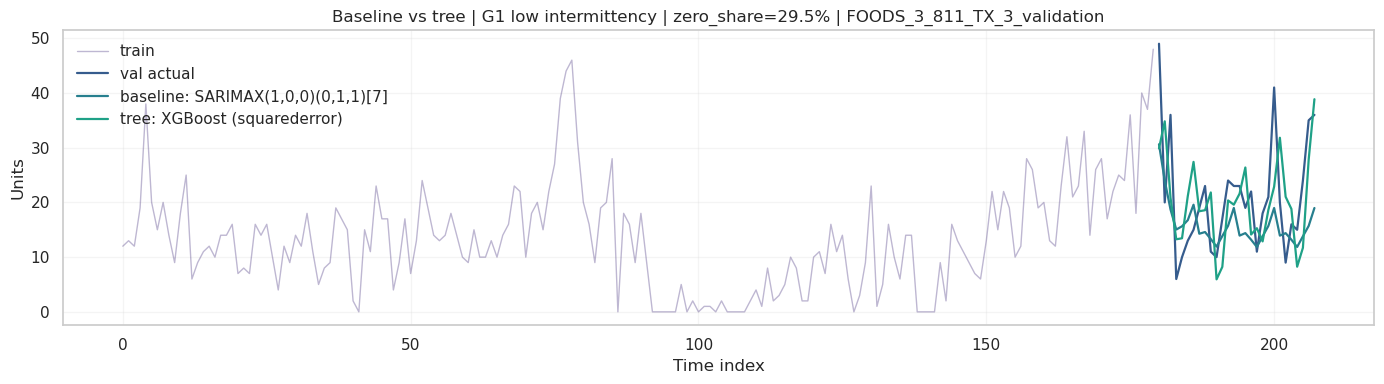

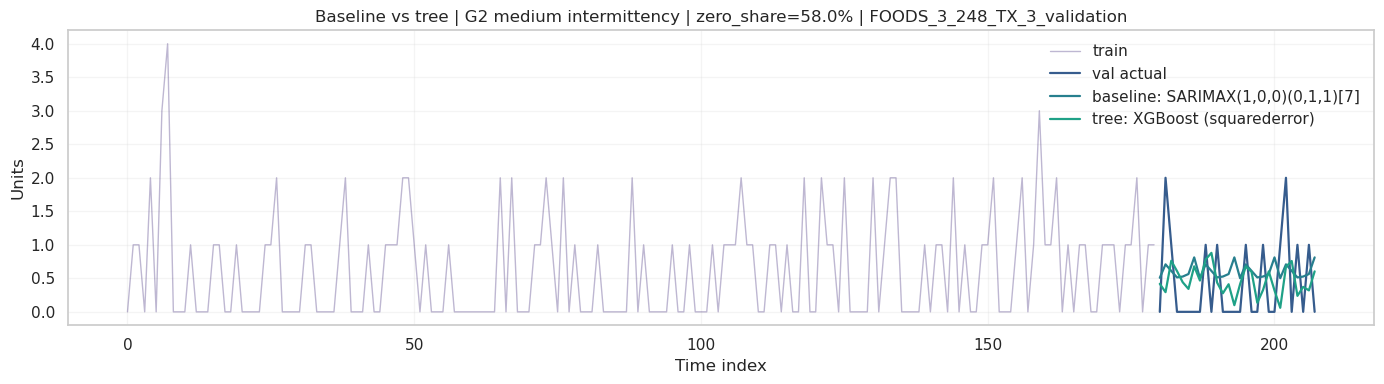

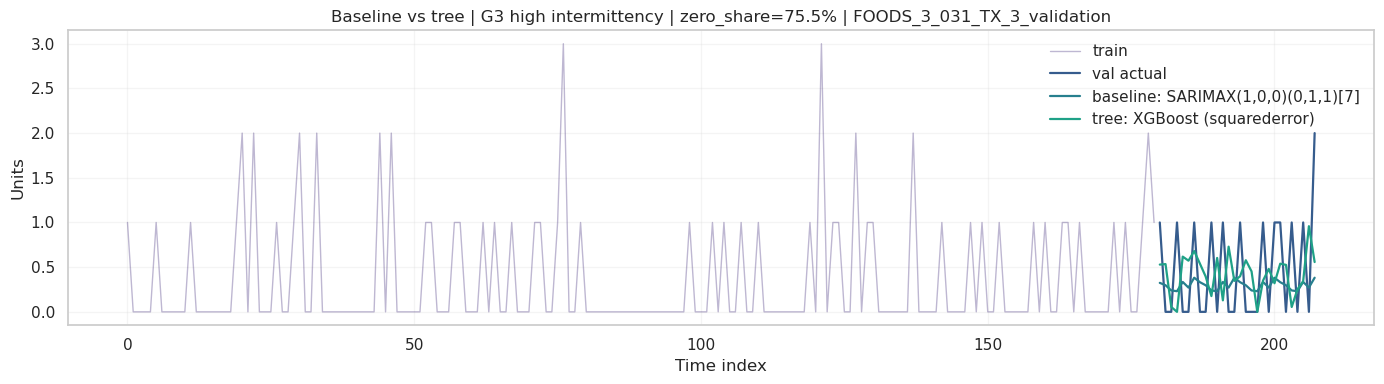

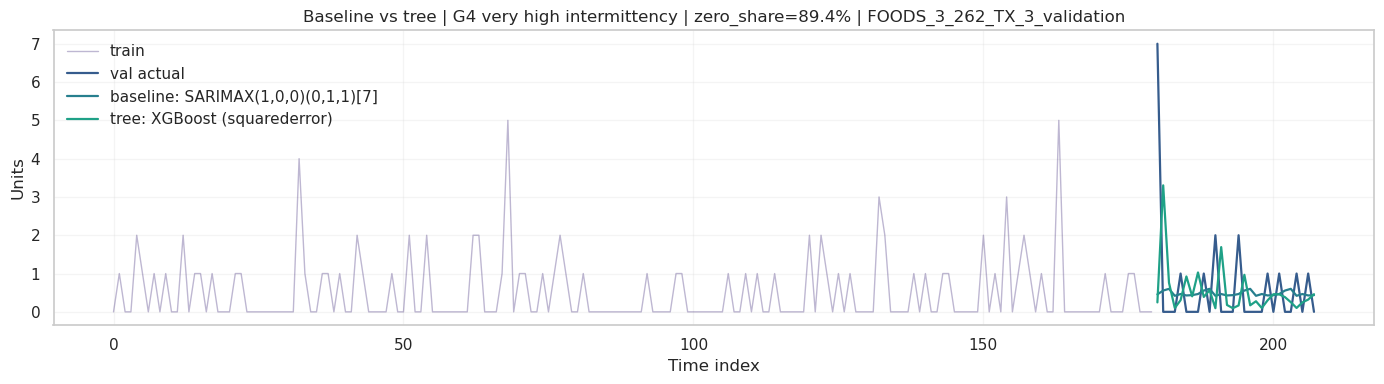

In [ ]:

baseline_pred_wide = pd.DataFrame(best_pred, index=val_wide.index, columns=val_wide.columns)

# Tree predictions as wide DF (already on baseline grid in your eval function, but align defensively)
tree_pred_wide = best_tree["Y_pred_wide"].copy()
tree_pred_wide = tree_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns)

# Hard stop if anything is missing (prevents silent NaNs -> garbage metrics)
missing_base = int(baseline_pred_wide.isna().sum().sum())
missing_tree = int(tree_pred_wide.isna().sum().sum())
if missing_base > 0:
    raise ValueError(f"baseline_pred_wide has {missing_base} NaN cells after alignment.")
if missing_tree > 0:
    raise ValueError(f"tree_pred_wide has {missing_tree} NaN cells after alignment. Check val_long_exact grid.")

# Clip negatives (counts) (demand can not be neg)
baseline_pred_wide = baseline_pred_wide.clip(lower=0.0)
tree_pred_wide = tree_pred_wide.clip(lower=0.0)

Y_true = val_wide.to_numpy(dtype=float)
Y_base = baseline_pred_wide.to_numpy(dtype=float)
Y_tree = tree_pred_wide.to_numpy(dtype=float)

# Overall H1-style comparison (same grid)
tree_rmse_all = rmse(Y_true, Y_tree)
tree_mae_all  = mae(Y_true, Y_tree)

print("Overall comparison on the 28-day hold-out (all items)")
print(f"Best baseline: {best_name} | RMSE={best_baseline_rmse:.4f} | MAE={best_baseline_mae:.4f}")
print(f"Best tree   : {best_tree['model']} | RMSE={tree_rmse_all:.4f} | MAE={tree_mae_all:.4f}")

rmse_imp_all = best_baseline_rmse - tree_rmse_all
mae_imp_all  = best_baseline_mae  - tree_mae_all
print(f"Improvement (baseline - tree): RMSE={rmse_imp_all:.4f} ({rmse_imp_all / best_baseline_rmse:.1%}) | "
      f"MAE={mae_imp_all:.4f} ({mae_imp_all / best_baseline_mae:.1%})")

# ----------------------------
# 3) H2: Baseline vs tree by intermittency group (same groups, same grid)
# ----------------------------
group_order = ["G1 low intermittency", "G2 medium intermittency", "G3 high intermittency", "G4 very high intermittency"]

rows = []
for g in group_order:
    idx = np.where(groups.values == g)[0]

    base_rmse_g = rmse(Y_true[idx, :], Y_base[idx, :])
    base_mae_g  = mae(Y_true[idx, :], Y_base[idx, :])

    tree_rmse_g = rmse(Y_true[idx, :], Y_tree[idx, :])
    tree_mae_g  = mae(Y_true[idx, :], Y_tree[idx, :])

    rows.append({
        "group": g,
        "n_items": int(len(idx)),
        "zero_share_mean": float(zero_share[groups == g].mean()),
        "baseline_RMSE": base_rmse_g,
        "tree_RMSE": tree_rmse_g,
        "RMSE_improvement": base_rmse_g - tree_rmse_g,
        "baseline_MAE": base_mae_g,
        "tree_MAE": tree_mae_g,
        "MAE_improvement": base_mae_g - tree_mae_g,
    })

compare_by_group = pd.DataFrame(rows)
display(compare_by_group)

# Plots: same representative items, but baseline and tree in the same figure
def plot_item_baseline_vs_tree(
    item_id: str,
    group_label: str,
    zs: float,
    tail: int = 180,
):
    if item_id not in train_wide.index:
        raise ValueError(f"item_id not in train_wide: {item_id}")
    if item_id not in val_wide.index:
        raise ValueError(f"item_id not in val_wide: {item_id}")

    y_train = train_wide.loc[item_id].astype(float)
    y_val   = val_wide.loc[item_id].astype(float)

    pred_base = baseline_pred_wide.loc[item_id].astype(float).values
    pred_tree = tree_pred_wide.loc[item_id].astype(float).values

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(14, 4))

    # Keep lines thin and readable
    plt.plot(x_train, train_tail.values, linewidth=1.0, alpha=0.35, label="train")
    plt.plot(x_val, y_val.values,       linewidth=1.6, label="val actual")
    plt.plot(x_val, pred_base,          linewidth=1.6, label=f"baseline: {best_name}")
    plt.plot(x_val, pred_tree,          linewidth=1.6, label=f"tree: {best_tree['model']}")

    plt.title(f"Baseline vs tree | {group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for g, rid, zs in rep_items:
    plot_item_baseline_vs_tree(rid, g, zs, tail=180)

## (Preliminary) H2 results (who benefits most)

Performance gains from the tree-based model vary strongly with intermittency.
The largest improvement occurs for low-intermittency items (G1): RMSE drops from 4.75 to 4.23 (- 0.52) and MAE drops from 2.64 to 2.34 (-0.30). 


**This is where learning calendar/price effects and reacting to level changes adds clear value beyond smoothing.**

For G2–G4, improvements are much smaller. RMSE decreases by about 0.04–0.05 in each group, and MAE also improves slightly (+0.02 in G2, +0.04 in G3, +0.01 in G4).
So, in this dataset, the tree model’s advantage is concentrated in the higher-volume / less intermittent series, while for very intermittent series it mainly provides marginal gains.

## Improving Model Feature importance for the best tree model (permutation, RMSE-based)
After selecting the best-performing tree model on the 28-day hold-out, we check which inputs it actually relies on.


### Feature engineering for intermittent demand

The pooled tree model improves over baselines, but performance remains weakest for highly intermittent series (long stretches of zeros with occasional spikes).  
Single lags (`lag_1`, `lag_7`, `lag_28`) help, but they do not fully capture:

1. **Recent level** (is the item currently “active” or “quiet”?)  
2. **Persistence of zeros** (how long since the last non-zero sale?)  
3. **Short-term vs medium-term regime** (last week vs last month)

To address this, we extend the feature set with **rolling statistics** computed *per item* using only past information:

- Rolling mean of sales over the previous 7 and 28 days  
- Rolling zero-share over the previous 28 days (intermittency in the recent window)  
- Time since last sale (a simple “zero-run length” signal)

These features are designed specifically to reduce systematic overprediction during long zero stretches, while still allowing spikes when recent activity suggests demand.

### We compute **permutation importance** on the validation grid:
we randomly shuffle one feature at a time and measure how much validation **RMSE worsens**.
A larger RMSE increase means the feature was more important for predictive accuracy.

Because lag features are correlated (lag_1, lag_7, lag_28), permutation importance should be interpreted as a **global ranking**, not as a causal effect size.

Full features used: ['lag_1', 'lag_7', 'lag_28', 'sell_price', 'price_change', 'sell_price_was_missing', 'wday', 'month', 'year', 'snap_TX', 'roll_mean_7', 'roll_sum_7', 'roll_std_7', 'roll_zero_share_7', 'roll_mean_28', 'roll_sum_28', 'roll_std_28', 'roll_zero_share_28', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
Numeric: ['lag_1', 'lag_7', 'lag_28', 'sell_price', 'price_change', 'sell_price_was_missing', 'wday', 'month', 'year', 'snap_TX', 'roll_mean_7', 'roll_sum_7', 'roll_std_7', 'roll_zero_share_7', 'roll_mean_28', 'roll_sum_28', 'roll_std_28', 'roll_zero_share_28']
Categorical: ['weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2452
[LightGBM] [Info] Number of data points i

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM (FULL_FEATURES) | RMSE=2.302142 | MAE=1.174600


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have v

,feature,importance_rmse_drop,std
2,lag_28,-0.021764,0.002019
3,sell_price,-0.006834,0.005621
7,month,-0.000423,0.000554
22,event_type_2,0.000000,0.000000
5,sell_price_was_missing,0.000000,0.000000
20,event_type_1,0.000000,0.000000
8,year,0.000000,0.000000
19,event_name_1,0.000000,0.000000
21,event_name_2,0.000000,0.000000
4,price_change,0.000627,0.000972


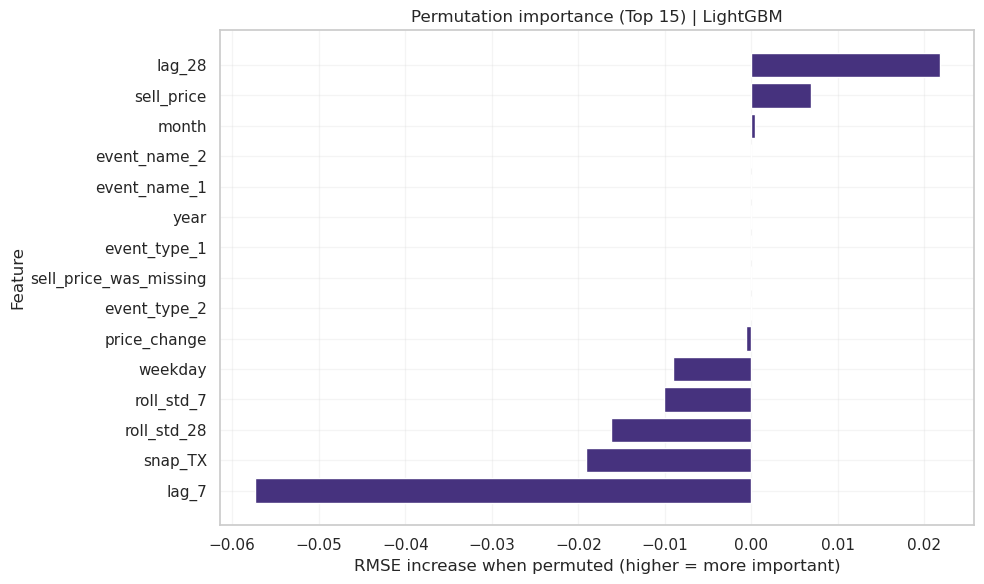

In [15]:

def build_train_long_exact(
    sales_long: pd.DataFrame,
    cutoff: int,
    ids: pd.Index,
    n_days: int = 730
):
    start_day = max(1, cutoff - n_days + 1)
    days = list(range(start_day, cutoff + 1))

    out = sales_long[
        (sales_long["d_index"].isin(days)) &
        (sales_long["id"].isin(ids))
    ].copy()

    # Hard sanity check: full grid
    expected = len(ids) * len(days)
    got = len(out)
    if got != expected:
        all_pairs = pd.MultiIndex.from_product([ids, days], names=["id", "d_index"])
        have_pairs = pd.MultiIndex.from_frame(out[["id", "d_index"]])
        missing = all_pairs.difference(have_pairs)
        print(f"train_long_exact incomplete: expected={expected}, got={got}, missing={len(missing)}")
        print("First 20 missing:", list(missing[:20]))
        raise ValueError("Training grid incomplete (ids/days mismatch or upstream filtering).")

    return out



def add_rollout_features(train_df: pd.DataFrame, val_df: pd.DataFrame, windows=(7, 28)):
    train_df = train_df.copy()
    val_df   = val_df.copy()

    train_df["_split"] = "train"
    val_df["_split"]   = "val"

    both = pd.concat([train_df, val_df], axis=0, ignore_index=True)
    both = both.sort_values(["id", "d_index"]).reset_index(drop=True)

    # leakage-safe: use lagged sales (t uses <= t-1)
    both["_sales_lagged"] = both.groupby("id")["sales"].shift(1).astype(float)

    for w in windows:
        both[f"roll_mean_{w}"] = both.groupby("id")["_sales_lagged"].transform(
            lambda s: s.rolling(window=w, min_periods=1).mean()
        )
        both[f"roll_sum_{w}"] = both.groupby("id")["_sales_lagged"].transform(
            lambda s: s.rolling(window=w, min_periods=1).sum()
        )
        both[f"roll_std_{w}"] = both.groupby("id")["_sales_lagged"].transform(
            lambda s: s.rolling(window=w, min_periods=2).std(ddof=0)
        ).fillna(0.0)
        both[f"roll_zero_share_{w}"] = both.groupby("id")["_sales_lagged"].transform(
            lambda s: (s.fillna(0.0) == 0.0).rolling(window=w, min_periods=1).mean()
        )

    both = both.drop(columns=["_sales_lagged"])

    train_out = both[both["_split"] == "train"].drop(columns=["_split"]).reset_index(drop=True)
    val_out   = both[both["_split"] == "val"].drop(columns=["_split"]).reset_index(drop=True)
    return train_out, val_out



needed = ["sales_long", "train_wide", "val_wide", "val_long_exact", "cutoff", "H", "NUM_COLS", "CAT_COLS"]
missing = [v for v in needed if v not in globals()]
if missing:
    raise NameError(f"Missing variables in notebook: {missing}")

# Ensure id types match
train_wide.index = train_wide.index.astype(str)
val_wide.index   = val_wide.index.astype(str)
sales_long["id"] = sales_long["id"].astype(str)
val_long_exact["id"] = val_long_exact["id"].astype(str)

# Build train_long_exact aligned to val ids
train_long_exact = build_train_long_exact(
    sales_long=sales_long,
    cutoff=cutoff,
    ids=val_wide.index,
    n_days=730
)

# Add rollout features leak-safely
train_long_roll, val_long_roll = add_rollout_features(
    train_long_exact, val_long_exact, windows=(7, 28)
)

# Rolling columns
ROLL_COLS = [
    "roll_mean_7", "roll_sum_7", "roll_std_7", "roll_zero_share_7",
    "roll_mean_28", "roll_sum_28", "roll_std_28", "roll_zero_share_28",
]

NUM_COLS_FULL = list(NUM_COLS) + [c for c in ROLL_COLS if c in train_long_roll.columns]
CAT_COLS_FULL = list(CAT_COLS)
FULL_FEATURES = NUM_COLS_FULL + CAT_COLS_FULL

print("Full features used:", FULL_FEATURES)
print("Numeric:", NUM_COLS_FULL)
print("Categorical:", CAT_COLS_FULL)

# ----------------------------
# Build model pipeline (OrdinalEncode categoricals, passthrough numeric)
# ----------------------------
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUM_COLS_FULL),
        ("cat", ord_enc, CAT_COLS_FULL),
    ],
    remainder="drop",
)

model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline([
    ("prep", preprocess),
    ("model", model),
])

# Train/val matrices
X_tr = train_long_roll[FULL_FEATURES].copy()
y_tr = pd.to_numeric(train_long_roll["sales"], errors="coerce").fillna(0.0).to_numpy(dtype=float)

X_va = val_long_roll[FULL_FEATURES].copy()
y_va = pd.to_numeric(val_long_roll["sales"], errors="coerce").fillna(0.0).to_numpy(dtype=float)

# Fit + evaluate
pipe.fit(X_tr, y_tr)
pred_va = np.maximum(pipe.predict(X_va), 0.0)

rmse_full = rmse(y_va, pred_va)
mae_full  = mae(y_va, pred_va)

print(f"\nLightGBM (FULL_FEATURES) | RMSE={rmse_full:.6f} | MAE={mae_full:.6f}")


rmse_scorer = make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False)

# Subsample validation rows to speed this up
N_IMP = 50000  # adjust: 20k faster, 50k decent, 100k slower
rng = np.random.RandomState(42)
if len(X_va) > N_IMP:
    idx = rng.choice(len(X_va), size=N_IMP, replace=False)
    X_imp = X_va.iloc[idx].copy()
    y_imp = y_va[idx]
else:
    X_imp = X_va
    y_imp = y_va

# Lower repeats = much faster
perm = permutation_importance(
    pipe,
    X_imp,
    y_imp,
    scoring=rmse_scorer,
    n_repeats=3,
    random_state=42,
    n_jobs=4,   # often better than -1 here
)

imp = pd.DataFrame({
    "feature": FULL_FEATURES,
    "importance_rmse_drop": perm.importances_mean,  # more negative => worse when permuted
    "std": perm.importances_std,
}).sort_values("importance_rmse_drop")  # most negative = most important

display(imp)

# Plot top-k (clean)
TOPK = 15
top = imp.head(TOPK).copy()
top["rmse_increase"] = -top["importance_rmse_drop"]  # flip sign for readability
top = top.sort_values("rmse_increase", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["rmse_increase"])
plt.xlabel("RMSE increase when permuted (higher = more important)")
plt.ylabel("Feature")
plt.title(f"Permutation importance (Top {TOPK}) | LightGBM")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [16]:
# Sanity: required variables
needed = [
    "imp", "FULL_FEATURES",
    "train_long_roll", "val_long_roll",
    "y_tr", "y_va",
    "baseline_pred_wide", "val_wide",
    "cutoff", "H",
    "NUM_COLS_FULL", "CAT_COLS_FULL",
]
missing = [v for v in needed if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}")


# Helper: map between d_index and val_wide columns
def _parse_dcol_to_int(c):
    # handles "d_1914" -> 1914, "1914" -> 1914, 1914 -> 1914, else None
    if isinstance(c, int):
        return c
    if isinstance(c, str):
        s = c.strip()
        if s.startswith("d_"):
            s = s[2:]
        if s.isdigit():
            return int(s)
    return None


def long_pred_to_wide(pred_long: np.ndarray, val_long_df: pd.DataFrame, val_wide: pd.DataFrame, cutoff: int, H: int) -> pd.DataFrame:
    """
    pred_long must align 1-1 with val_long_df rows.
    val_long_df must contain columns ["id","d_index"].
    Returns wide preds aligned to val_wide.index + val_wide.columns.
    """
    tmp = val_long_df[["id", "d_index"]].copy()
    tmp["pred"] = np.asarray(pred_long, dtype=float)

    wide = tmp.pivot(index="id", columns="d_index", values="pred")

    # Decide how to align columns to val_wide.columns
    val_cols = list(val_wide.columns)
    parsed = [_parse_dcol_to_int(c) for c in val_cols]
    val_days = list(range(int(cutoff) + 1, int(cutoff) + int(H) + 1))

    # Case A: val_wide columns look like d_#### / ####
    if all(p is not None for p in parsed) and set(parsed) == set(val_days):
        d_to_col = {p: c for p, c in zip(parsed, val_cols)}
        wide = wide.reindex(columns=val_days)
        wide.columns = [d_to_col[d] for d in val_days]
        wide = wide.reindex(index=val_wide.index, columns=val_wide.columns)
        return wide.astype(float)

    # Case B: val_wide columns already are 1..H (horizon index)
    if len(val_cols) == H and set(val_cols) == set(range(1, H + 1)):
        # rename d_index -> horizon step
        d_to_step = {d: (d - cutoff) for d in val_days}  # cutoff+1 -> 1
        wide = wide.reindex(columns=val_days)
        wide.columns = [d_to_step[d] for d in val_days]
        wide = wide.reindex(index=val_wide.index, columns=val_wide.columns)
        return wide.astype(float)

    # Fallback: just force same order by val_days and then overwrite columns to match val_wide
    wide = wide.reindex(columns=val_days)
    wide.columns = val_wide.columns
    wide = wide.reindex(index=val_wide.index, columns=val_wide.columns)
    return wide.astype(float)


def wide_pred_to_long(baseline_pred_wide: pd.DataFrame, val_long_df: pd.DataFrame, val_wide: pd.DataFrame, cutoff: int, H: int) -> np.ndarray:
    """
    Convert baseline_pred_wide (id x horizon-cols) into a vector aligned with val_long_df rows.
    This lets you score baseline vs tree on the SAME long grid (y_va).
    """
    # Align baseline wide to val_wide
    base_w = baseline_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns).astype(float).clip(lower=0.0)

    # Build mapping from val_wide columns -> d_index
    val_cols = list(val_wide.columns)
    parsed = [_parse_dcol_to_int(c) for c in val_cols]
    val_days = list(range(int(cutoff) + 1, int(cutoff) + int(H) + 1))

    if all(p is not None for p in parsed) and set(parsed) == set(val_days):
        col_to_d = {c: p for c, p in zip(val_cols, parsed)}
        # create long aligned
        df_long = val_long_df[["id", "d_index"]].copy()
        # pick baseline prediction by (id, d_index)
        out = []
        for rid, d in zip(df_long["id"].values, df_long["d_index"].values):
            # find the right wide column
            # invert mapping: d_index -> col
            col = {v: k for k, v in col_to_d.items()}[int(d)]
            out.append(base_w.loc[str(rid), col])
        return np.asarray(out, dtype=float)

    # If val_wide cols are horizon steps 1..H
    if len(val_cols) == H and set(val_cols) == set(range(1, H + 1)):
        df_long = val_long_df[["id", "d_index"]].copy()
        out = []
        for rid, d in zip(df_long["id"].values, df_long["d_index"].values):
            step = int(d) - int(cutoff)  # cutoff+1 -> 1
            out.append(base_w.loc[str(rid), step])
        return np.asarray(out, dtype=float)

    # Fallback: assume val_wide columns are in horizon order 1..H
    df_long = val_long_df[["id", "d_index"]].copy()
    out = []
    for rid, d in zip(df_long["id"].values, df_long["d_index"].values):
        step = int(d) - int(cutoff)
        step = max(1, min(H, step))
        out.append(base_w.iloc[val_wide.index.get_loc(str(rid)), step - 1])
    return np.asarray(out, dtype=float)



imp2 = imp.copy()
imp2["rmse_increase"] = imp2["importance_rmse_drop"]  # interpret as RMSE change
imp2 = imp2.sort_values("rmse_increase", ascending=False).reset_index(drop=True)

# Evidence rule: keep features that improve performance (rmse_increase > 0)
kept_by_sign = imp2.loc[imp2["rmse_increase"] > 0, "feature"].tolist()

print(f"Features with rmse_increase > 0: {len(kept_by_sign)} / {len(FULL_FEATURES)}")
print("First 25 kept:", kept_by_sign[:25])


Features with rmse_increase > 0: 14 / 23
First 25 kept: ['roll_mean_7', 'lag_1', 'roll_zero_share_28', 'roll_zero_share_7', 'wday', 'roll_sum_28', 'roll_sum_7', 'roll_mean_28', 'lag_7', 'snap_TX', 'roll_std_28', 'roll_std_7', 'weekday', 'price_change']


### Evidence-based choice of **K** (pruned feature set)

We prune the LightGBM feature set by ranking features (via `kept_by_sign`) and then **refitting** models for **K = 5..K_max** using only the top-K features. For each K we score RMSE/MAE on the same validation grid and pick:

1) **Best K** = the K with the lowest validation RMSE  
2) **Chosen K** = the **smallest** K whose RMSE is within **0.5%** of the best (our simplicity–performance trade-off)

This gives a pruned model that is nearly as accurate as the best-performing K, but with fewer features and less complexity.


In [17]:


#  refit LightGBM on a given feature subset
def fit_lgbm_on_features(feature_list):
    # split into numeric/cat according to your already-defined sets
    num = [c for c in feature_list if c in NUM_COLS_FULL]
    cat = [c for c in feature_list if c in CAT_COLS_FULL]

    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    preprocess = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num),
            ("cat", ord_enc, cat),
        ],
        remainder="drop",
    )

    model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )

    pipe_k = Pipeline([
        ("prep", preprocess),
        ("model", model),
    ])

    X_tr_k = train_long_roll[feature_list].copy()
    X_va_k = val_long_roll[feature_list].copy()

    # keep DF inputs to avoid "no valid feature names" warnings
    pipe_k.fit(X_tr_k, y_tr)
    pred_k = np.maximum(pipe_k.predict(X_va_k), 0.0)

    return pipe_k, pred_k


# Full model prediction (for comparison)
#
pred_full_long = np.maximum(pipe.predict(val_long_roll[FULL_FEATURES].copy()), 0.0)

rmse_full = rmse(y_va, pred_full_long)
mae_full  = mae(y_va, pred_full_long)

print(f"\nFull LightGBM (all features)  RMSE={rmse_full:.6f} | MAE={mae_full:.6f}")


if len(kept_by_sign) < 5:
    raise ValueError("Too few positive-importance features to do a sensible K search.")

K_MIN = 5
K_MAX = len(kept_by_sign)
TOL_PCT = 0.005  # 0.50% tolerance

rows = []
best_rmse = np.inf
best_k = None
best_pipe = None
best_pred = None

for K in range(K_MIN, K_MAX + 1):
    feats_k = kept_by_sign[:K]
    pipe_k, pred_k = fit_lgbm_on_features(feats_k)
    r = rmse(y_va, pred_k)
    m = mae(y_va, pred_k)

    rows.append({"K": K, "RMSE": r, "MAE": m})
    if r < best_rmse:
        best_rmse = r
        best_k = K
        best_pipe = pipe_k
        best_pred = pred_k

prune_curve = pd.DataFrame(rows)
display(prune_curve)

# Best K
print(f"Best K found: K={best_k} | RMSE={best_rmse:.6f} | MAE={prune_curve.loc[prune_curve['K']==best_k,'MAE'].iloc[0]:.6f}")

# Simplest within tolerance of best
rmse_threshold = best_rmse * (1.0 + TOL_PCT)
simple_candidates = prune_curve[prune_curve["RMSE"] <= rmse_threshold].sort_values("K")
chosen_k = int(simple_candidates.iloc[0]["K"])

print(f"Simplest within {TOL_PCT*100:.2f}% of best: K={chosen_k} (threshold RMSE <= {rmse_threshold:.6f})")

# Refit chosen K (so you have the actual chosen pruned model object)
chosen_features = kept_by_sign[:chosen_k]
pipe_pruned, pred_pruned_long = fit_lgbm_on_features(chosen_features)

rmse_pruned = rmse(y_va, pred_pruned_long)
mae_pruned  = mae(y_va, pred_pruned_long)

print("\n--- Final chosen pruned model ---")
print("Chosen K=", chosen_k)
print("Pruned RMSE=", rmse_pruned, "| MAE=", mae_pruned)
print("Delta vs FULL: RMSE", (rmse_pruned - rmse_full), "| MAE", (mae_pruned - mae_full))


# Score baseline (SARIMAX) on the SAME long grid
# baseline_pred_wide is our SARIMAX wide predictions
baseline_pred_long = wide_pred_to_long(
    baseline_pred_wide=baseline_pred_wide,
    val_long_df=val_long_roll,     # same ordering as y_va
    val_wide=val_wide,
    cutoff=cutoff,
    H=H
)
baseline_pred_long = np.maximum(baseline_pred_long, 0.0)

rmse_base = rmse(y_va, baseline_pred_long)
mae_base  = mae(y_va, baseline_pred_long)

print(f"\nBaseline (SARIMAX) on long grid  RMSE={rmse_base:.6f} | MAE={mae_base:.6f}")


# ----------------------------
# 6)  comparison table (baseline vs full vs pruned)
# ----------------------------
compare = pd.DataFrame([
    {"Model": "SARIMAX (baseline)", "RMSE": rmse_base,  "MAE": mae_base,  "n_features": np.nan},
    {"Model": "LightGBM (full)",    "RMSE": rmse_full,  "MAE": mae_full,  "n_features": len(FULL_FEATURES)},
    {"Model": f"LightGBM (pruned K={chosen_k})", "RMSE": rmse_pruned, "MAE": mae_pruned, "n_features": chosen_k},
]).sort_values("RMSE")

display(compare)


# WIDE predictions for plotting (rep items)
tree_pred_wide_full = long_pred_to_wide(
    pred_long=pred_full_long,
    val_long_df=val_long_roll,
    val_wide=val_wide,
    cutoff=cutoff,
    H=H,
)

tree_pred_wide_pruned = long_pred_to_wide(
    pred_long=pred_pruned_long,
    val_long_df=val_long_roll,
    val_wide=val_wide,
    cutoff=cutoff,
    H=H,
)

print("tree_pred_wide_full shape:", tree_pred_wide_full.shape)
print("tree_pred_wide_pruned shape:", tree_pred_wide_pruned.shape)

print("\nChosen pruned feature list:")
print(chosen_features)

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Full LightGBM (all features)  RMSE=2.302142 | MAE=1.174600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 600790, number of used features: 5
[LightGBM] [Info] Start training from score 2.005489


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 600790, number of used features: 6
[LightGBM] [Info] Start training from score 2.005489


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

Best K found: K=10 | RMSE=2.281604 | MAE=1.167225
Simplest within 0.50% of best: K=6 (threshold RMSE <= 2.293012)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 600790, number of used features: 6
[LightGBM] [Info] Start training from score 2.005489


/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



--- Final chosen pruned model ---
Chosen K= 6
Pruned RMSE= 2.2855338399933984 | MAE= 1.1675136619277882
Delta vs FULL: RMSE -0.016607938602574368 | MAE -0.00708670981665116

Baseline (SARIMAX) on long grid  RMSE=2.649734 | MAE=1.345333


,Model,RMSE,MAE,n_features
2,LightGBM (pruned K=6),2.285534,1.167514,6.0
1,LightGBM (full),2.302142,1.174600,23.0
0,SARIMAX (baseline),2.649734,1.345333,NaN


tree_pred_wide_full shape: (823, 28)
tree_pred_wide_pruned shape: (823, 28)

Chosen pruned feature list:
['roll_mean_7', 'lag_1', 'roll_zero_share_28', 'roll_zero_share_7', 'wday', 'roll_sum_28']


## Feature importance (permutation, RMSE-based)

To understand *which inputs the model actually uses*, we compute **permutation importance** on the 28-day validation grid.  
For each feature, we randomly shuffle its values and re-score the model.  
If RMSE increases a lot, the feature was important; if RMSE barely changes, the feature contributed little beyond the others.

## Key finding: LightGBM relies on short-term demand level and intermittency, not on events

Permutation importance shows that the tree model is driven mainly by **recent demand signals** and **how “intermittent” an item has been**, rather than by calendar events.

- **roll_mean_7** is the strongest driver by a large margin.  
  This indicates the model mainly predicts demand based on the *recent 7-day demand level* (a smoothed short-term signal).

- **lag_1** is the next most important feature, meaning *yesterday’s sales* still carries a lot of predictive value beyond the rolling mean.

- **roll_zero_share_28** and **roll_zero_share_7** rank high, showing that the model explicitly uses **intermittency**: how often an item has been zero recently.  
  This matches the main difficulty of retail series in this dataset (many runs of zeros).

- **wday** contributes as well, which is consistent with weekly seasonality effects.

In contrast, **event variables** (event name/type) and **price_change** show little to no contribution, suggesting that with this feature definition and encoding they do not add predictive signal beyond what is already captured by demand history and price level.

This ranking also explains why a **small pruned model** using only the top features can perform similarly (or slightly better) than the full feature set: most of the predictive signal is concentrated in a few history + intermittency variables.


**Caveat:** permutation importance can underestimate features when predictors are correlated (especially lags).  
We interpret this as a *global ranking*, not as a causal statement.


## H2: Baseline vs PRUNED tree by intermittency group (same grid)



SARIMAX H2: Baseline (baseline_pred_wide)
LIGHTBM for H2: LightGBM (pruned)


,group,n_items,zero_share_mean,baseline_RMSE,tree_RMSE,RMSE_improvement,baseline_MAE,tree_MAE,MAE_improvement
0,G1 low intermittency,206,0.275491,4.408876,3.733723,0.675153,2.596009,2.094801,0.501208
1,G2 medium intermittency,206,0.573104,2.322687,2.138810,0.183876,1.356130,1.247256,0.108874
2,G3 high intermittency,205,0.749946,1.449507,1.238305,0.211202,0.863465,0.762660,0.100805
3,G4 very high intermittency,206,0.895138,1.061288,0.910027,0.151262,0.563388,0.563372,0.000015


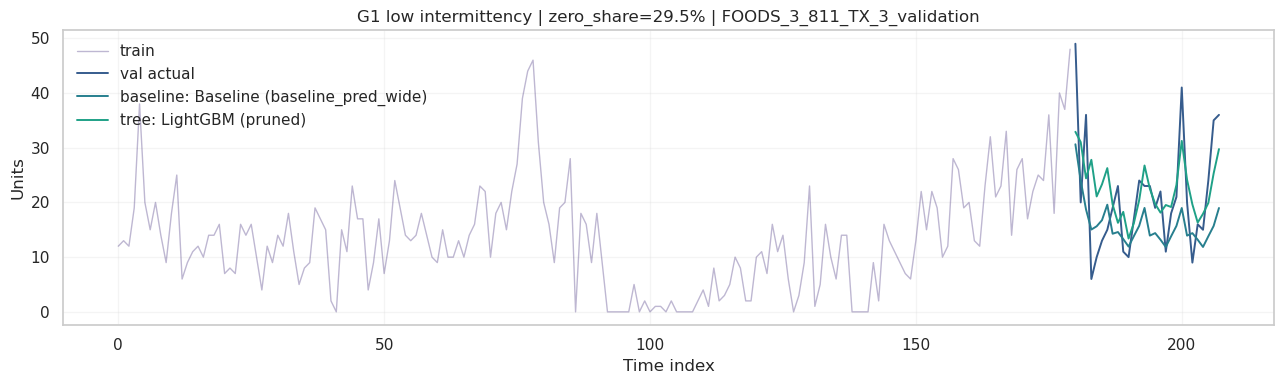

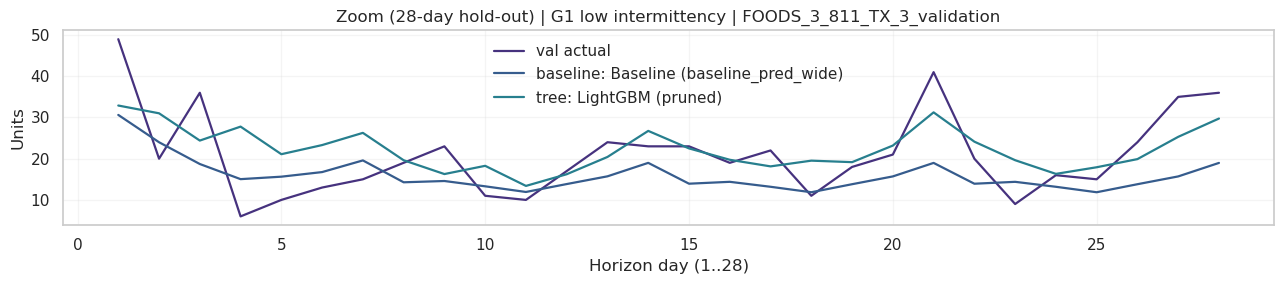

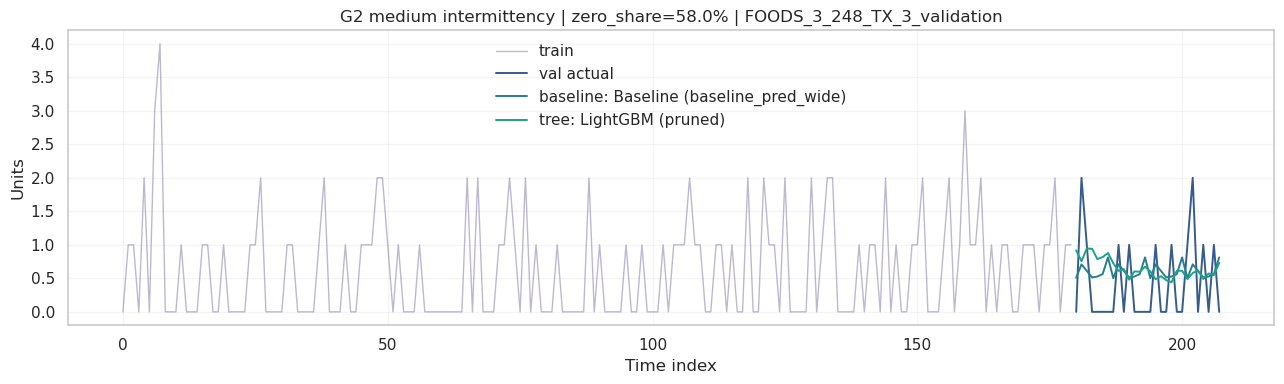

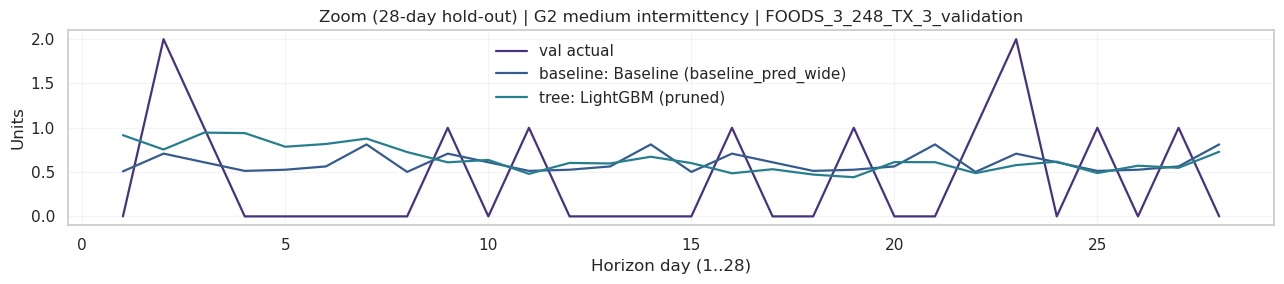

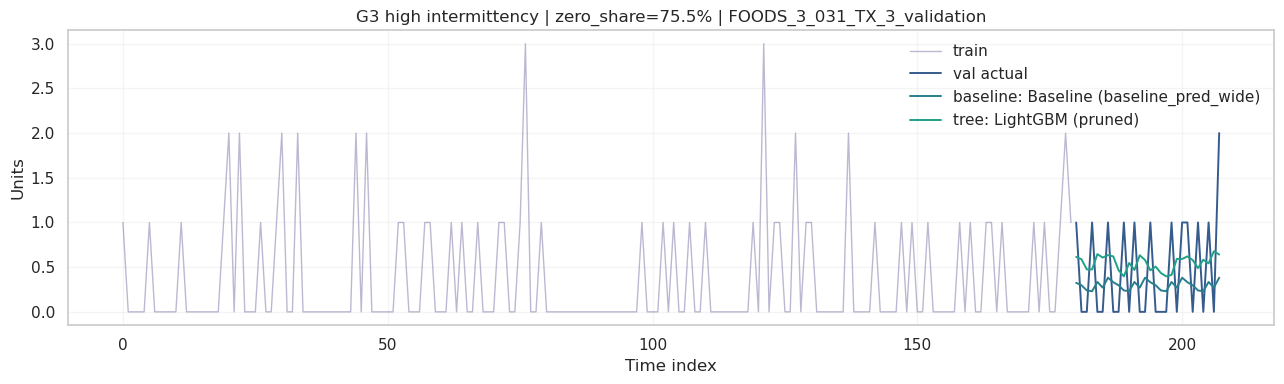

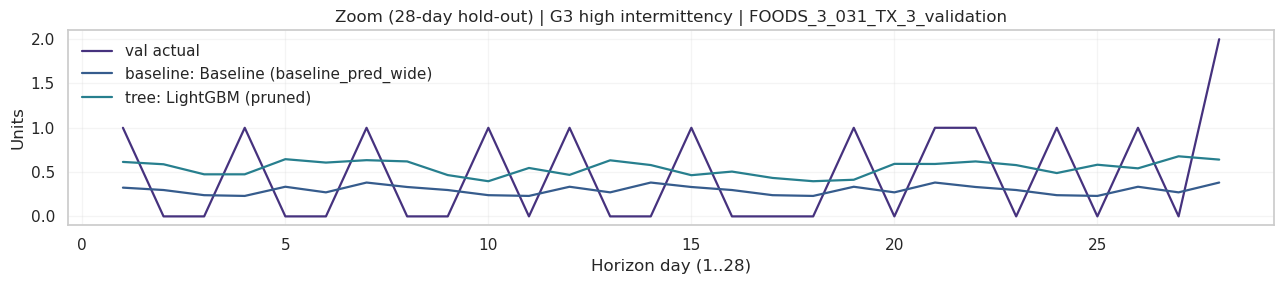

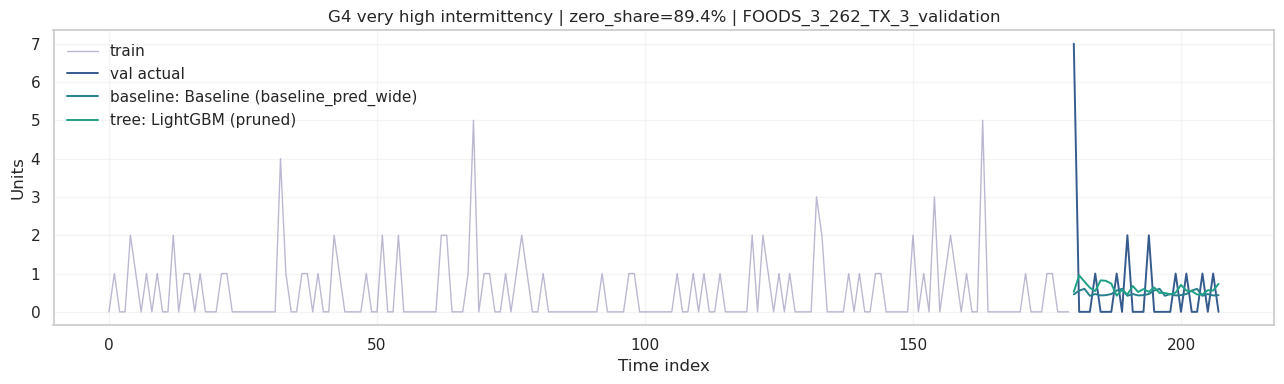

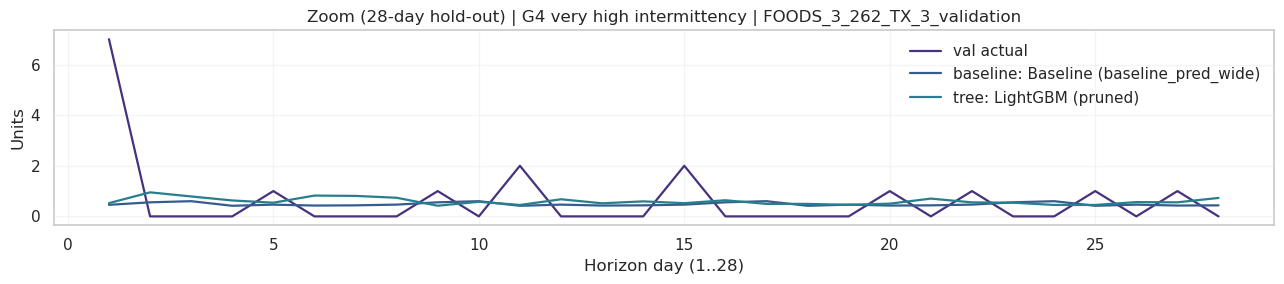

In [18]:

#checks
required = ["train_wide", "val_wide", "groups", "rep_items"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}")

# rmse/mae must exist; define if missing
if "rmse" not in globals() or "mae" not in globals():
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))
    def mae(y_true, y_pred):  return float(mean_absolute_error(y_true, y_pred))

# Making sure indices are aligned
train_wide.index = train_wide.index.astype(str)
val_wide.index   = val_wide.index.astype(str)
groups.index     = groups.index.astype(str)

# Ensure zero_share is a pandas Series with id index
if "zero_share" not in globals() or isinstance(zero_share, np.ndarray):
    Y_train = train_wide.to_numpy(dtype=float)
    zero_share = pd.Series((Y_train == 0).mean(axis=1), index=train_wide.index, name="zero_share")
else:
    # if it is a Series but might not be indexed correctly
    if not isinstance(zero_share, pd.Series):
        zero_share = pd.Series(zero_share, index=train_wide.index, name="zero_share")
    else:
        zero_share.index = zero_share.index.astype(str)

# Baseline predictions (you said baseline = SARIMAX)
def get_baseline_pred_wide():
    # If you computed SARIMAX wide predictions earlier, this should exist:
    if "sarimax_pred_wide" in globals():
        base = sarimax_pred_wide.copy()
        base_name = "SARIMAX (baseline)"
        return base, base_name

    # If you stored baseline_pred_wide but it IS sarimax in your notebook, reuse it:
    if "baseline_pred_wide" in globals():
        base = baseline_pred_wide.copy()
        base_name = "Baseline (baseline_pred_wide)"
        return base, base_name

    raise ValueError(
        "No SARIMAX baseline found. Expected `sarimax_pred_wide` (preferred) or `baseline_pred_wide`."
    )

baseline_pred_wide, baseline_used_name = get_baseline_pred_wide()
baseline_pred_wide = (
    baseline_pred_wide
    .reindex(index=val_wide.index, columns=val_wide.columns)
    .clip(lower=0.0)
)

missing_base = int(baseline_pred_wide.isna().sum().sum())
if missing_base > 0:
    raise ValueError(f"Baseline wide preds have {missing_base} NaNs after alignment. Fix baseline grid.")

# Pruned LightGBM predictions (same grid as val_wide)
def get_pruned_tree_pred_wide():
    if "tree_pred_wide_pruned" in globals():
        return tree_pred_wide_pruned.copy(), "LightGBM (pruned)"

    # optional fallback to `results`
    if "results" in globals():
        possible_keys = ["Y_pred_wide", "y_pred_wide", "pred_wide", "tree_pred_wide"]
        candidates = []
        for r in results:
            model_name = str(r.get("model", ""))
            if "PRUNED" in model_name.upper():
                for k in possible_keys:
                    if k in r:
                        candidates.append((r, k))
                        break
        if len(candidates) == 0:
            raise ValueError(
                "No PRUNED model with a wide prediction matrix found in `results`.\n"
                "Inspect: [r.get('model') for r in results]"
            )

        def get_rmse(pair):
            r, _k = pair
            return float(r.get("RMSE", np.inf))

        chosen, chosen_key = min(candidates, key=get_rmse)
        return chosen[chosen_key].copy(), str(chosen.get("model", "PRUNED_MODEL"))

    raise ValueError(
        "No pruned tree predictions found. Expected `tree_pred_wide_pruned` or a PRUNED entry in `results`."
    )

tree_pred_wide, tree_used_name = get_pruned_tree_pred_wide()
tree_pred_wide = tree_pred_wide.reindex(index=val_wide.index, columns=val_wide.columns)

missing_tree = int(tree_pred_wide.isna().sum().sum())
if missing_tree > 0:
    raise ValueError(
        f"{tree_used_name}: tree_pred_wide has {missing_tree} NaN cells after alignment.\n"
        "This means your prediction grid is not exactly (val_wide.index x val_wide.columns)."
    )

tree_pred_wide = tree_pred_wide.clip(lower=0.0)

print("SARIMAX H2:", baseline_used_name)
print("LIGHTBM for H2:", tree_used_name)

# Group metrics table (index-safe)

group_order = [
    "G1 low intermittency",
    "G2 medium intermittency",
    "G3 high intermittency",
    "G4 very high intermittency"
]

rows = []
for g in group_order:
    ids_g = groups[groups == g].index

    if len(ids_g) == 0:
        rows.append({
            "group": g,
            "n_items": 0,
            "zero_share_mean": np.nan,
            "baseline_RMSE": np.nan,
            "tree_RMSE": np.nan,
            "RMSE_improvement": np.nan,
            "baseline_MAE": np.nan,
            "tree_MAE": np.nan,
            "MAE_improvement": np.nan,
        })
        continue

    # align ids to val_wide index only (extra safety)
    ids_g = ids_g.intersection(val_wide.index)

    Y_true_g = val_wide.loc[ids_g].to_numpy(dtype=float)
    Y_base_g = baseline_pred_wide.loc[ids_g].to_numpy(dtype=float)
    Y_tree_g = tree_pred_wide.loc[ids_g].to_numpy(dtype=float)

    base_rmse_g = rmse(Y_true_g, Y_base_g)
    base_mae_g  = mae(Y_true_g, Y_base_g)

    tree_rmse_g = rmse(Y_true_g, Y_tree_g)
    tree_mae_g  = mae(Y_true_g, Y_tree_g)

    rows.append({
        "group": g,
        "n_items": int(len(ids_g)),
        "zero_share_mean": float(zero_share.loc[ids_g].mean()),
        "baseline_RMSE": base_rmse_g,
        "tree_RMSE": tree_rmse_g,
        "RMSE_improvement": base_rmse_g - tree_rmse_g,
        "baseline_MAE": base_mae_g,
        "tree_MAE": tree_mae_g,
        "MAE_improvement": base_mae_g - tree_mae_g,
    })

h2_pruned = pd.DataFrame(rows)
display(h2_pruned)

# Representative plots: baseline vs PRUNED tree (uses your rep_items)
def plot_rep_item_baseline_tree_zoom(item_id: str, group_label: str, zs: float, tail: int = 180):
    item_id = str(item_id)

    y_train = train_wide.loc[item_id].astype(float)
    y_val   = val_wide.loc[item_id].astype(float)

    pred_base = baseline_pred_wide.loc[item_id].astype(float).values
    pred_tree = tree_pred_wide.loc[item_id].astype(float).values

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(13, 4))
    plt.plot(x_train, train_tail.values, linewidth=1.0, alpha=0.35, label="train")
    plt.plot(x_val, y_val.values,       linewidth=1.4, label="val actual")
    plt.plot(x_val, pred_base,          linewidth=1.4, label=f"baseline: {baseline_used_name}")
    plt.plot(x_val, pred_tree,          linewidth=1.4, label=f"tree: {tree_used_name}")
    plt.title(f"{group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 3))
    h = len(y_val)
    plt.plot(np.arange(1, h + 1), y_val.values, linewidth=1.6, label="val actual")
    plt.plot(np.arange(1, h + 1), pred_base,    linewidth=1.6, label=f"baseline: {baseline_used_name}")
    plt.plot(np.arange(1, h + 1), pred_tree,    linewidth=1.6, label=f"tree: {tree_used_name}")
    plt.title(f"Zoom ({h}-day hold-out) | {group_label} | {item_id}")
    plt.xlabel(f"Horizon day (1..{h})")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for g, rid, zs in rep_items:
    plot_rep_item_baseline_tree_zoom(rid, g, zs, tail=180)



## Group-level aggregation sanity check 

WE converted the 823 item-level series into **four group-level time series** by aggregating items within each intermittency bucket (G1–G4).

### What this cell produces
1) `train_group_sum` / `val_group_sum`  
Daily **total units** per group (sum over items). This is the most stable representation.

2) `train_group_mean` / `val_group_mean`  
Daily **average units per item** per group. This is useful for comparability across groups (not dominated by a few high-volume items).

3) Plots per group:  
WE plot the last `tail=180` days of training plus the **same 28-day hold-out** as before.

### What WE should check in the plots
WE mainly use these plots as a diagnostic before modeling:
- Do we see **weekly seasonality** (repeating 7-day pattern)?
- Is the 28-day holdout similar to recent history or does it show a regime change?
- Are group sums smooth enough that SARIMAX is defensible?

If the plots look stable (especially for G1/G2 sums), group-level SARIMAX becomes meaningful.


# Final evaluation on the official test set (File 6)

We use `sales_test_evaluation_afcs_2025.csv` as the **final, unseen** evaluation set.  
It contains exactly **823 series** and the next **28 days of realized sales** (`d_1942` to `d_1969`).

To ensure a fair comparison, we:
1) Refit the chosen baseline and the chosen tree model using **all available historical sales up to `d_1941`**  
2) Produce **true 28-step-ahead forecasts** for `d_1942..d_1969`  
3) Score RMSE and MAE on the exact same `(n_items × 28)` grid as the test file  
4) Repeat the H2 analysis by intermittency group using the same grouping definition (computed from training history only)


In [61]:
TEST_PATH = Path("data/sales_test_evaluation_afcs_2025.csv")
test_df = pd.read_csv(TEST_PATH)

test_d_cols = [c for c in test_df.columns if c.startswith("d_")]
test_wide = test_df.set_index("id")[test_d_cols].astype(float).sort_index()

print("Test wide shape:", test_wide.shape)
print("Test days:", test_d_cols[0], "to", test_d_cols[-1])
display(test_wide.head(3))

path = Path("data/sales_test_evaluation_afcs_2025.csv")

df6 = pd.read_csv(path)
print("Path:", path.resolve())
print("Shape:", df6.shape)
print("\nColumns (first 20):", df6.columns[:20].tolist())
print("Columns (last 20):", df6.columns[-20:].tolist())

# Basic missingness overview
na_rate = df6.isna().mean().sort_values(ascending=False)
print("\nTop columns by NA rate (if any):")
print(na_rate.head(15))

# Identify id columns vs day columns
d_cols = [c for c in df6.columns if c.startswith("d_")]
id_cols = [c for c in df6.columns if c not in d_cols]

print("\n#id_cols:", len(id_cols), "->", id_cols)
print("#d_cols :", len(d_cols), "from", d_cols[0], "to", d_cols[-1])

# Check whether d_ columns look like exactly a 28-day horizon
d_nums = [int(c.split("_")[1]) for c in d_cols]
print("\nDay index summary:")
print("min d:", min(d_nums), "max d:", max(d_nums), "count:", len(d_nums))
if len(d_nums) >= 2:
    diffs = np.diff(sorted(d_nums))
    print("Unique gaps between d's:", sorted(set(diffs))[:10], "(showing up to 10)")

# Quick peek at the data
display(df6.head(3))

# Sanity checks for duplicates in id space
if id_cols:
    dup = df6.duplicated(subset=id_cols).sum()
    print("\nDuplicate rows by id columns:", dup)

# Optional: if you expect store/item identifiers, show unique counts
for c in ["id", "item_id", "store_id", "dept_id", "cat_id", "state_id"]:
    if c in df6.columns:
        print(f"Unique {c}:", df6[c].nunique())

Test wide shape: (823, 28)
Test days: d_1942 to d_1969


,d_1942,d_1943,d_1944,d_1945,d_1946,d_1947,d_1948,d_1949,d_1950,d_1951,...,d_1960,d_1961,d_1962,d_1963,d_1964,d_1965,d_1966,d_1967,d_1968,d_1969
id,,,,,,,,,,,,,,,,,,,,,
FOODS_3_001_TX_3_validation,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FOODS_3_002_TX_3_validation,5.0,0.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,2.0,...,6.0,2.0,3.0,4.0,4.0,6.0,6.0,0.0,0.0,0.0
FOODS_3_003_TX_3_validation,2.0,2.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,2.0,...,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


Path: /home/djameldino/Documents/forecasting_final_project/data/sales_test_evaluation_afcs_2025.csv
Shape: (823, 29)

Columns (first 20): ['id', 'd_1942', 'd_1943', 'd_1944', 'd_1945', 'd_1946', 'd_1947', 'd_1948', 'd_1949', 'd_1950', 'd_1951', 'd_1952', 'd_1953', 'd_1954', 'd_1955', 'd_1956', 'd_1957', 'd_1958', 'd_1959', 'd_1960']
Columns (last 20): ['d_1950', 'd_1951', 'd_1952', 'd_1953', 'd_1954', 'd_1955', 'd_1956', 'd_1957', 'd_1958', 'd_1959', 'd_1960', 'd_1961', 'd_1962', 'd_1963', 'd_1964', 'd_1965', 'd_1966', 'd_1967', 'd_1968', 'd_1969']

Top columns by NA rate (if any):
id        0.0
d_1956    0.0
d_1968    0.0
d_1967    0.0
d_1966    0.0
d_1965    0.0
d_1964    0.0
d_1963    0.0
d_1962    0.0
d_1961    0.0
d_1960    0.0
d_1959    0.0
d_1958    0.0
d_1957    0.0
d_1955    0.0
dtype: float64

#id_cols: 1 -> ['id']
#d_cols : 28 from d_1942 to d_1969

Day index summary:
min d: 1942 max d: 1969 count: 28
Unique gaps between d's: [1] (showing up to 10)


,id,d_1942,d_1943,d_1944,d_1945,d_1946,d_1947,d_1948,d_1949,d_1950,...,d_1960,d_1961,d_1962,d_1963,d_1964,d_1965,d_1966,d_1967,d_1968,d_1969
0,FOODS_3_001_TX_3_validation,0,0,0,0,0,1,2,0,2,...,0,0,1,0,0,0,0,0,0,0
1,FOODS_3_002_TX_3_validation,5,0,2,2,2,0,1,0,1,...,6,2,3,4,4,6,6,0,0,0
2,FOODS_3_003_TX_3_validation,2,2,0,0,2,0,1,0,0,...,0,2,0,1,0,0,0,1,0,0



Duplicate rows by id columns: 0
Unique id: 823


### Recursive 28-day rollout evaluation 

In [21]:
def recursive_28day_eval(
    df: pd.DataFrame,
    pipe,
    feature_cols,
    num_cols,
    cat_cols,
    horizon: int = 28,
    cat_categories: dict | None = None,
):

    df = df.copy()
    df["d_index"] = df["d_index"].astype(int)
    df = df.sort_values(["id", "d_index"])

    max_d = int(df["d_index"].max())
    cutoff = max_d - horizon

    # Build history arrays from the train portion
    train_hist = (
        df.loc[df["d_index"] <= cutoff, ["id", "d_index", "sales"]]
        .sort_values(["id", "d_index"])
        .groupby("id")["sales"]
        .apply(lambda s: s.astype(float).to_numpy())
    )
    ids = train_hist.index.to_numpy()
    n = len(ids)
    hist = {i: train_hist.loc[i].tolist() for i in ids}

    df_idx = df.set_index(["id", "d_index"])

    preds, trues = [], []
    days = list(range(cutoff + 1, cutoff + horizon + 1))

    for d in days:
        rows = []
        y_true = np.zeros(n, dtype=np.float32)

        for j, series_id in enumerate(ids):
            base = df_idx.loc[(series_id, d)]
            hlist = hist[series_id]

            row = {}
            for col in num_cols:
                if col == "lag_1":
                    row[col] = hlist[-1]
                elif col == "lag_7":
                    row[col] = hlist[-7]
                elif col == "lag_28":
                    row[col] = hlist[-28]
                else:
                    row[col] = float(base[col]) if col in base.index else np.nan
            for col in cat_cols:
                row[col] = base[col] if col in base.index else "none"

            rows.append(row)
            y_true[j] = float(base["sales"])

        X_step = pd.DataFrame(rows, columns=feature_cols)

        # Enforce the same categorical levels as training to avoid LightGBM mismatch
        if cat_categories is not None:
            for c in cat_cols:
                cats = cat_categories.get(c)
                if cats is not None and c in X_step.columns:
                    X_step[c] = pd.Categorical(X_step[c], categories=cats)

        y_pred = pipe.predict(X_step).astype(np.float32)

        preds.append(y_pred)
        trues.append(y_true)

        for j, series_id in enumerate(ids):
            hist[series_id].append(float(y_pred[j]))

    P = np.stack(preds, axis=0)
    T = np.stack(trues, axis=0)

    rmse = float(np.sqrt(np.mean((T - P) ** 2)))
    mae = float(np.mean(np.abs(T - P)))

    return {
        "cutoff": cutoff,
        "days": days,
        "ids": ids,
        "pred_matrix": P,
        "true_matrix": T,
        "rmse": rmse,
        "mae": mae,
    }


# Official test evaluation and diagnostics (from here onward we use the 28-day test window)


In [ ]:


# ----------------------------
# Metrics
# ----------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(mean_absolute_error(y_true, y_pred))

# ----------------------------
# Paths
# ----------------------------

TEST_PATH = DATA_DIR / "sales_test_evaluation_afcs_2025.csv"
TRAIN_PATH = DATA_DIR / "sales_train_validation_afcs2025.csv"
TEST_VAL_PATH = DATA_DIR / "sales_test_validation_afcs2025.csv"
CAL_PATH = DATA_DIR / "calendar_afcs2025.csv"
PRICES_PATH = DATA_DIR / "sell_prices_afcs2025.csv"

CACHE_FEATURES = DATA_DIR / "sales_features_with_calendar_prices.csv"  # optional cache

# Load official test wide
test_df = pd.read_csv(TEST_PATH)
test_d_cols = [c for c in test_df.columns if c.startswith("d_")]
test_wide = test_df.set_index("id")[test_d_cols].astype(float).sort_index()
test_wide.index = test_wide.index.astype(str)

H = len(test_d_cols)
first_test_day = int(test_d_cols[0].replace("d_", ""))
last_test_day = int(test_d_cols[-1].replace("d_", ""))
cutoff = first_test_day - 1  # d_1941

print("Official test wide shape:", test_wide.shape)
print("Official test days:", test_d_cols[0], "to", test_d_cols[-1])
assert test_wide.shape == (823, 28)


# Load official test wide to define last_test_day (d_1969)
test_df = pd.read_csv(TEST_PATH)
test_d_cols = [c for c in test_df.columns if c.startswith("d_")]
test_wide = test_df.set_index("id")[test_d_cols].astype(float).sort_index()

last_test_day = int(test_d_cols[-1].replace("d_", ""))
print("Official test wide shape:", test_wide.shape)
print("Official test days:", test_d_cols[0], "to", test_d_cols[-1])
print("last_test_day =", last_test_day)


if "cutoff" not in globals():
    cutoff = 1941
    print("cutoff not found in globals(). Defaulting cutoff=1941 for grouping/history.")

# Build sales_long from wide files (train + test_val + test_eval)
def build_sales_long_all() -> pd.DataFrame:
    train_wide_df = pd.read_csv(TRAIN_PATH)
    test_val_wide_df = pd.read_csv(TEST_VAL_PATH)
    test_eval_wide_df = pd.read_csv(TEST_PATH)

    # Merge to one wide table with all d_ columns
    sales_wide = (
        train_wide_df
        .merge(test_val_wide_df, on="id", how="left")
        .merge(test_eval_wide_df, on="id", how="left")
    )

    calendar = pd.read_csv(CAL_PATH)
    calendar["d_index"] = calendar.index + 1
    sell_prices = pd.read_csv(PRICES_PATH)

    day_cols_all = [c for c in sales_wide.columns if c.startswith("d_")]
    id_cols = [c for c in sales_wide.columns if c not in day_cols_all]

    sales_long = sales_wide.melt(
        id_vars=id_cols,
        value_vars=day_cols_all,
        var_name="d_col",
        value_name="sales"
    )
    sales_long["id"] = sales_long["id"].astype(str)
    sales_long["d_index"] = sales_long["d_col"].str.replace("d_", "", regex=False).astype(int)

    # Merge calendar vars
    sales_long = sales_long.merge(calendar, on="d_index", how="left")

    # Parse item/store for price join
    base = (
        sales_long["id"]
        .str.replace("_validation$", "", regex=True)
        .str.replace("_evaluation$", "", regex=True)
    )
    parts = base.str.split("_", expand=True)
    sales_long["item_id"] = parts[0] + "_" + parts[1] + "_" + parts[2]
    sales_long["store_id"] = parts[3] + "_" + parts[4]

    # Join prices
    sales_long = sales_long.merge(
        sell_prices,
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left"
    ).sort_values(["store_id", "item_id", "d_index"])

    # Price filling (no look-ahead):
    #
    sales_long["sell_price_was_missing"] = sales_long["sell_price"].isna().astype(int)
    sales_long["sell_price"] = sales_long.groupby(["store_id", "item_id"])["sell_price"].ffill()

    med = sales_long.groupby(["store_id", "item_id"])["sell_price"].transform("median")
    sales_long["sell_price"] = sales_long["sell_price"].fillna(med).fillna(0.0)

    sales_long["price_change"] = (
        sales_long.groupby(["store_id", "item_id"])["sell_price"].diff().fillna(0.0)
    )

    # Sales lags (used for training; recursive eval will create its own lags from history)
    sales_long = sales_long.sort_values(["id", "d_index"])
    sales_long["sales"] = pd.to_numeric(sales_long["sales"], errors="coerce")  # keep NaN if any
    for lag in [1, 7, 28]:
        sales_long[f"lag_{lag}"] = sales_long.groupby("id")["sales"].shift(lag)

    return sales_long

#  Load cache if COMPLETE, otherwise rebuild & overwrite
def load_or_build_sales_long(cache_path: Path, min_last_day_required: int) -> pd.DataFrame:
    if cache_path.exists():
        sl = pd.read_csv(cache_path)
        sl["id"] = sl["id"].astype(str)
        sl["d_index"] = sl["d_index"].astype(int)
        max_d = int(sl["d_index"].max())
        print(f"Loaded cached feature dataset: {cache_path} shape={sl.shape} | max d_index={max_d}")

        if max_d >= min_last_day_required:
            return sl

        print(
            f"Cache is INCOMPLETE (max d_index={max_d} < required {min_last_day_required}). "
            "Rebuilding and overwriting cache..."
        )
        # backup old cache
        backup = cache_path.with_suffix(".OLD.csv")
        try:
            cache_path.rename(backup)
            print(f"Backed up old cache to: {backup}")
        except Exception as e:
            print(f"Warning: could not back up cache ({e}). Will overwrite anyway.")

    sl = build_sales_long_all()
    sl.to_csv(cache_path, index=False)
    print(f"Built + cached features: {cache_path} shape={sl.shape} | max d_index={int(sl['d_index'].max())}")
    return sl

sales_long = load_or_build_sales_long(CACHE_FEATURES, min_last_day_required=last_test_day)

# sanity
assert int(sales_long["d_index"].min()) == 1
assert int(sales_long["d_index"].max()) >= last_test_day
print("sales_long d_index min/max:", int(sales_long["d_index"].min()), int(sales_long["d_index"].max()))
print("unique ids in sales_long:", sales_long["id"].nunique())


#Intermittency groups from HISTORY ONLY (<= cutoff)
hist = sales_long.loc[sales_long["d_index"] <= cutoff, ["id", "sales"]].copy()
hist["id"] = hist["id"].astype(str)

# zero share per id (treat NaN as 0 sales)
def zero_share_fn(s: pd.Series) -> float:
    v = pd.to_numeric(s, errors="coerce").fillna(0.0)
    return float((v == 0.0).mean())

zero_share = hist.groupby("id")["sales"].apply(zero_share_fn)

# Align to the official test ids (823)
zero_share = zero_share.reindex(test_wide.index)

# check if not something is missing, t
n_missing = int(zero_share.isna().sum())
if n_missing > 0:
    missing_ids = zero_share[zero_share.isna()].index[:10].tolist()
    raise ValueError(
        f"zero_share is missing for {n_missing} ids after reindex to official test ids.\n"
        f"Example missing ids: {missing_ids}\n"
        "This indicates an id mismatch between your sales_long and the official test file."
    )

q25, q50, q75 = zero_share.quantile([0.25, 0.50, 0.75]).tolist()

def assign_group(z: float) -> str:
    if z <= q25:
        return "G1 low intermittency"
    if z <= q50:
        return "G2 medium intermittency"
    if z <= q75:
        return "G3 high intermittency"
    return "G4 very high intermittency"

groups = zero_share.apply(assign_group)

print(f"Zero-share cut points (history <= d_{cutoff}): 25%={q25:.3f} | 50%={q50:.3f} | 75%={q75:.3f}")
display(groups.value_counts().rename("n_items").to_frame())

# representative items: closest to median zero_share within each group
rep_items = []
group_order = ["G1 low intermittency","G2 medium intermittency","G3 high intermittency","G4 very high intermittency"]

for g in group_order:
    ids_g = groups[groups == g].index
    if len(ids_g) == 0:
        continue
    zs_g = zero_share.loc[ids_g]
    med_g = float(zs_g.median())
    rid = (zs_g - med_g).abs().sort_values().index[0]
    rep_items.append((g, rid, float(zero_share.loc[rid])))

print("Representative items (median zero-share per group):")
for g, rid, zs in rep_items:
    print(f"{g}: {rid} | zero_share={zs:.1%}")


Official test wide shape: (823, 28)
Official test days: d_1942 to d_1969
Official test wide shape: (823, 28)
Official test days: d_1942 to d_1969
last_test_day = 1969
Loaded cached feature dataset: data/sales_features_with_calendar_prices.csv shape=(1574399, 27) | max d_index=1913
Cache is INCOMPLETE (max d_index=1913 < required 1969). Rebuilding and overwriting cache...
Backed up old cache to: data/sales_features_with_calendar_prices.OLD.csv
Built + cached features: data/sales_features_with_calendar_prices.csv shape=(1620487, 23) | max d_index=1969
sales_long d_index min/max: 1 1969
unique ids in sales_long: 823
Zero-share cut points (history <= d_1941): 25%=0.455 | 50%=0.658 | 75%=0.818


,n_items
sales,
G4 very high intermittency,206
G2 medium intermittency,206
G1 low intermittency,206
G3 high intermittency,205


Representative items (median zero-share per group):
G1 low intermittency: FOODS_3_495_TX_3_validation | zero_share=28.8%
G2 medium intermittency: FOODS_3_392_TX_3_validation | zero_share=57.7%
G3 high intermittency: FOODS_3_429_TX_3_validation | zero_share=74.8%
G4 very high intermittency: FOODS_3_545_TX_3_validation | zero_share=88.6%


In [23]:

# Helpers: ensure roll features exist for TRAINING (shift(1) to avoid leakage)

def ensure_roll_features_for_training(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["id", "d_index"]).copy()
    g = df.groupby("id", sort=False)

    # past sales only (safe)
    s_prev = g["sales"].shift(1)
    z_prev = (pd.to_numeric(s_prev, errors="coerce").fillna(0.0) == 0.0).astype(float)

    for w in [7, 28]:
        # rolling over past values only
        df[f"roll_mean_{w}"] = (
            s_prev.groupby(df["id"]).rolling(w, min_periods=w).mean().droplevel(0)
        )
        df[f"roll_sum_{w}"] = (
            s_prev.groupby(df["id"]).rolling(w, min_periods=w).sum().droplevel(0)
        )
        df[f"roll_std_{w}"] = (
            s_prev.groupby(df["id"]).rolling(w, min_periods=w).std().droplevel(0)
        )
        df[f"roll_zero_share_{w}"] = (
            z_prev.groupby(df["id"]).rolling(w, min_periods=w).mean().droplevel(0)
        )

    return df


# Recursive forecaster (true 28-step recursion) WITH roll features computed from history

def recursive_forecast_wide(
    df: pd.DataFrame,
    model,
    feature_cols: list[str],
    num_cols: list[str],
    cat_cols: list[str],
    cutoff: int,
    horizon: int,
    future_d_cols: list[str],
    ids: pd.Index,
    cat_categories: dict | None = None,
):
    df = df.copy()
    df["id"] = df["id"].astype(str)
    df["d_index"] = df["d_index"].astype(int)
    df = df.sort_values(["id", "d_index"])
    df_idx = df.set_index(["id", "d_index"])

    # history up to cutoff (true sales)
    train_hist = (
        df.loc[df["d_index"] <= cutoff, ["id", "d_index", "sales"]]
        .sort_values(["id", "d_index"])
        .groupby("id")["sales"]
        .apply(lambda s: pd.to_numeric(s, errors="coerce").fillna(0.0).astype(float).to_list())
    ).reindex(ids)

    bad = train_hist.apply(len) < 28
    if bad.any():
        raise ValueError(
            f"Some series have <28 history points before cutoff. Example: {train_hist[bad].index[:3].tolist()}"
        )

    hist_dict = {i: train_hist.loc[i] for i in ids}

    preds = []
    days = list(range(cutoff + 1, cutoff + horizon + 1))

    def roll_from_hist(hlist: list[float], w: int, kind: str) -> float:
        arr = np.asarray(hlist[-w:], dtype=float)
        if kind == "mean":
            return float(arr.mean())
        if kind == "sum":
            return float(arr.sum())
        if kind == "std":
            return float(arr.std(ddof=0))
        if kind == "zero_share":
            return float((arr == 0.0).mean())
        raise ValueError("Unknown roll kind")

    for d in days:
        rows = []
        for series_id in ids:
            base = df_idx.loc[(series_id, d)]
            hlist = hist_dict[series_id]

            row = {}

            for col in num_cols:
                # lags from recursive history
                if col == "lag_1":
                    row[col] = hlist[-1]
                elif col == "lag_7":
                    row[col] = hlist[-7]
                elif col == "lag_28":
                    row[col] = hlist[-28]

                # rolling features from recursive history (NO leakage)
                elif col == "roll_mean_7":
                    row[col] = roll_from_hist(hlist, 7, "mean")
                elif col == "roll_sum_7":
                    row[col] = roll_from_hist(hlist, 7, "sum")
                elif col == "roll_std_7":
                    row[col] = roll_from_hist(hlist, 7, "std")
                elif col == "roll_zero_share_7":
                    row[col] = roll_from_hist(hlist, 7, "zero_share")

                elif col == "roll_mean_28":
                    row[col] = roll_from_hist(hlist, 28, "mean")
                elif col == "roll_sum_28":
                    row[col] = roll_from_hist(hlist, 28, "sum")
                elif col == "roll_std_28":
                    row[col] = roll_from_hist(hlist, 28, "std")
                elif col == "roll_zero_share_28":
                    row[col] = roll_from_hist(hlist, 28, "zero_share")

                # exogenous / calendar / price features from the base row
                else:
                    row[col] = float(base[col]) if col in base.index else np.nan

            for col in cat_cols:
                row[col] = base[col] if col in base.index else "none"

            rows.append(row)

        X_step = pd.DataFrame(rows, columns=feature_cols)

        if cat_categories is not None:
            for c in cat_cols:
                cats = cat_categories.get(c)
                if cats is not None and c in X_step.columns:
                    X_step[c] = pd.Categorical(X_step[c], categories=cats)

        y_pred = np.maximum(model.predict(X_step).astype(float), 0.0)
        preds.append(y_pred)

        for j, series_id in enumerate(ids):
            hist_dict[series_id].append(float(y_pred[j]))

    P = np.stack(preds, axis=0)  # (H, n_items)
    pred_wide = pd.DataFrame(P.T, index=ids, columns=future_d_cols)
    return pred_wide


### What this block does

- Fits the **final LightGBM regressor** on training data (days ≤ `cutoff`), handling categorical features.
- Generates the **SARIMAX baseline** per item on the same history; if SARIMAX fails or history is short, it falls back to **MA(28)**.


In [24]:

def fit_lgbm(train_df: pd.DataFrame, feature_cols: list[str], cat_cols: list[str], params: dict):
    X = train_df[feature_cols].copy()
    y = pd.to_numeric(train_df["sales"], errors="coerce").fillna(0.0).astype(float)

    cat_categories = {}
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype("category")
            cat_categories[c] = X[c].cat.categories

    model = LGBMRegressor(**params)
    model.fit(X, y, categorical_feature=[c for c in cat_cols if c in X.columns])
    return model, cat_categories


def baseline_ma28_per_series(y_hist: np.ndarray, horizon: int) -> np.ndarray:
    mu = float(np.mean(y_hist[-28:])) if len(y_hist) >= 28 else float(np.mean(y_hist)) if len(y_hist) > 0 else 0.0
    return np.full(horizon, max(mu, 0.0), dtype=float)

def baseline_sarimax_wide(
    df: pd.DataFrame,
    cutoff: int,
    horizon: int,
    future_d_cols: list[str],
    ids: pd.Index,
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 7),
    maxiter: int = 50,
):
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    df = df.copy()
    df["id"] = df["id"].astype(str)
    df["d_index"] = df["d_index"].astype(int)

    hist = (
        df.loc[df["d_index"] <= cutoff, ["id", "d_index", "sales"]]
        .sort_values(["id", "d_index"])
    )
    hist["sales"] = pd.to_numeric(hist["sales"], errors="coerce").fillna(0.0).astype(float)

    out = np.zeros((len(ids), horizon), dtype=float)

    for i, sid in enumerate(ids):
        y = hist.loc[hist["id"] == sid, "sales"].to_numpy(dtype=float)
        if len(y) < 30:
            out[i, :] = baseline_ma28_per_series(y, horizon)
            continue

        try:
            mod = SARIMAX(
                y,
                order=order,
                seasonal_order=seasonal_order,
                trend="n",
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            res = mod.fit(disp=False, maxiter=maxiter)
            fc = res.forecast(steps=horizon)
            fc = np.asarray(fc, dtype=float)
            out[i, :] = np.maximum(fc, 0.0)
        except Exception:
            out[i, :] = baseline_ma28_per_series(y, horizon)

    return pd.DataFrame(out, index=ids, columns=future_d_cols)


In [25]:
import matplotlib.pyplot as plt

TEAL    = "#1663A2"
MAGENTA = "#BC1052"
GOLD    = "#34676F"
BLUEISH = "#CCAA00"
GRAY    = "#4D4D4D"

# Map models → colors (adjust labels to match your exact Model strings)
MODEL_COLORS = {
    "SARIMAX": MAGENTA,
    "SARIMAX(1,0,0)(0,1,1)[7]": MAGENTA,  # if you use that exact name in tables
    "LightGBM (old/full)": TEAL,
    "LightGBM (pruned K=6)": BLUEISH,
    "Actual": GRAY,  # optional
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


## Recursive multi-step forecasting (what we do here, and why it’s slow)

Tree-based models (like LightGBM) need **lagged** and **rolling-window** features such as `lag_1`, `lag_7`, `lag_28`, `roll_mean_7`, and `roll_sum_28`.  
For a **true 28-day-ahead forecast**, those predictors are **not observed** after the cutoff day `cutoff`, because the future sales values are unknown.  
So we must generate forecasts **sequentially**, feeding the model’s own predictions back into the feature updates. This is called **recursive forecasting**.

### What “recursive” means in our code
We train the LightGBM model on all days up to the cutoff:

- **Training window:** days `≤ cutoff`
- **Validation window:** the next **H = 28** days (`test_d_cols`)

Then, for each horizon step \(h = 1,\ldots,28\):

1. **Start from history up to the current time point**
   - For step \(h=1\), history ends at `cutoff`.
   - For step \(h>1\), history includes the **previous predictions** \(\hat{y}_{cutoff+1}, \ldots, \hat{y}_{cutoff+h-1}\).

2. **Recompute lag and rolling features causally**
   - Example: `lag_1` becomes the most recent value in the history  
   - Example: `roll_mean_7` is computed from the last 7 values in the history  
   - For later horizons, those “last values” increasingly consist of the model’s own predictions.

3. **Predict the next day**
   - Produce h, append it to history, and move to \(h+1\).

That is exactly what `recursive_forecast_wide(...)` does for:
- the **full** feature model (`pred_full`)
- the **pruned** feature model (`pred_pruned`)

### Why recursive forecasting takes very long
Recursive forecasting is slow because it is **not one prediction pass**. It is a loop over:

- **items** (all `ids`)  
- **horizon steps** (H = 28)
- **feature recomputation** at each step (lags + rolling windows)

So the work scales roughly like:

\[
\text{cost} \approx (\#\text{items}) \times 28 \times (\text{feature updates} + \text{model prediction})
\]

and the feature updates are the expensive part: rolling sums/means/zero-share often require scanning or aggregating recent history repeatedly.

In contrast, a direct multi-output model would predict all 28 horizons in one pass (no repeated feature rebuilding), and direct-by-horizon would still avoid the “roll forward with predictions” part (but trains more models).

### What this protects against (leakage)
Recursive forecasting is the deployable setting because it ensures:
- features for day `cutoff+h` are built **without using observed sales from that day or later**
- future information from the validation window is never used to construct predictors

So it is slower, but it is the correct “real-world” simulation of how the model would run after deployment.


In [26]:

H = len(test_d_cols)
ids = test_wide.index.astype(str)

# make sure roll features exist for training, but recursion will recompute them from history anyway
sales_long = ensure_roll_features_for_training(sales_long)

train_tree = sales_long.loc[sales_long["d_index"] <= cutoff].copy()

# Feature sets (keep your originals)

PRUNED_FEATURES = ['roll_mean_7', 'lag_1', 'roll_zero_share_28', 'roll_zero_share_7', 'wday', 'roll_sum_28']

# keep only columns that exist, BUT ALSO: if something is missing unexpectedly, fail loudly
missing_full = [c for c in FULL_FEATURES if c not in train_tree.columns]
missing_pruned = [c for c in PRUNED_FEATURES if c not in train_tree.columns]
if missing_full:
    print("WARNING: Missing FULL_FEATURES columns (they will be dropped):", missing_full)
if missing_pruned:
    raise ValueError(
        f"Your PRUNED feature list is missing columns in sales_long: {missing_pruned}\n"
        "This is exactly why you previously ended up with only ['lag_1','wday'].\n"
        "Fix: ensure_roll_features_for_training(sales_long) ran and sales_long contains the roll_* columns."
    )

FULL_FEATURES = [c for c in FULL_FEATURES if c in train_tree.columns]
PRUNED_FEATURES = [c for c in PRUNED_FEATURES if c in train_tree.columns]

CAT_COLS_FULL = [c for c in ["weekday","event_name_1","event_type_1","event_name_2","event_type_2"] if c in FULL_FEATURES]
NUM_COLS_FULL = [c for c in FULL_FEATURES if c not in CAT_COLS_FULL]

CAT_COLS_PRUNED = []
NUM_COLS_PRUNED = PRUNED_FEATURES.copy()

print("FULL features used:", len(FULL_FEATURES), FULL_FEATURES)
print("PRUNED features used:", len(PRUNED_FEATURES), PRUNED_FEATURES)

# training rows must have lag_28 (and for FULL_FEATURES, need enough history for roll_28 too)
need_cols_full = [c for c in ["lag_1","lag_7","lag_28"] if c in train_tree.columns]
train_tree_full = train_tree.dropna(subset=need_cols_full + [c for c in FULL_FEATURES if c.startswith("roll_")])

train_tree_pruned = train_tree.dropna(subset=["lag_1","lag_7","lag_28"])  # roll features computed from shift(1), so also NaN early

lgbm_params = dict(
    n_estimators=800,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)

# Fit models
model_full, cats_full = fit_lgbm(train_tree_full, FULL_FEATURES, CAT_COLS_FULL, lgbm_params)
model_pruned, cats_pruned = fit_lgbm(train_tree_pruned, PRUNED_FEATURES, CAT_COLS_PRUNED, lgbm_params)


# 5) BASELINE = SARIMAX 

baseline_pred_wide = baseline_sarimax_wide(
    df=sales_long,
    cutoff=cutoff,
    horizon=H,
    future_d_cols=test_d_cols,
    ids=ids,
    order=(1,0,0),
    seasonal_order=(0,1,1,7),
    maxiter=50,
).reindex(index=ids, columns=test_d_cols)

baseline_name = "SARIMAX(1,0,0)(0,1,1)[7]"


# Recursive forecasts
pred_full = recursive_forecast_wide(
    df=sales_long,
    model=model_full,
    feature_cols=FULL_FEATURES,
    num_cols=NUM_COLS_FULL,
    cat_cols=CAT_COLS_FULL,
    cutoff=cutoff,
    horizon=H,
    future_d_cols=test_d_cols,
    ids=ids,
    cat_categories=cats_full,
)

pred_pruned = recursive_forecast_wide(
    df=sales_long,
    model=model_pruned,
    feature_cols=PRUNED_FEATURES,
    num_cols=NUM_COLS_PRUNED,
    cat_cols=CAT_COLS_PRUNED,
    cutoff=cutoff,
    horizon=H,
    future_d_cols=test_d_cols,
    ids=ids,
    cat_categories=cats_pruned,
)


FULL features used: 23 ['lag_1', 'lag_7', 'lag_28', 'sell_price', 'price_change', 'sell_price_was_missing', 'wday', 'month', 'year', 'snap_TX', 'roll_mean_7', 'roll_sum_7', 'roll_std_7', 'roll_zero_share_7', 'roll_mean_28', 'roll_sum_28', 'roll_std_28', 'roll_zero_share_28', 'weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
PRUNED features used: 6 ['roll_mean_7', 'lag_1', 'roll_zero_share_28', 'roll_zero_share_7', 'wday', 'roll_sum_28']
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.132950 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2321
[LightGBM] [Info] Number of data points in the train set: 1574399, number of used features: 23
[LightGBM] [Info] Start training from score 1.914929
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012813 seconds.
You can set `force_row

/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/djameldino/anaconda3/envs/geoenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Final evaluation: overall scores, intermittency breakdown, and representative plots

This cell runs the **final evaluation** on the official 28-day test window (`d_1942 .. d_1969`). We compare three models that all produce a **28-step-ahead forecast** for every item:

- **SARIMAX(1,0,0)(0,1,1)[7]** as the statistical baseline
- **LightGBM (old/full)** using the full feature set with leakage-safe recursive rollout
- **LightGBM (pruned K=6)** using a smaller feature set (K=6) with leakage-safe recursive rollout

### What the code does

1. **Build the evaluation target matrix**
   - `Y_true` is the ground-truth sales for every item (`ids`) and every test day (`test_d_cols`).
   - Each model produces a wide prediction matrix with the same shape: rows = items, columns = the 28 test days.

2. **Compute overall accuracy (all items pooled)**
   - For each model we compute:
     - **RMSE** (penalizes large errors more strongly)
     - **MAE** (average absolute error; less sensitive to spikes)
   - These are computed over the full item × day matrix, so they reflect global performance on the official window.

3. **Compute accuracy per intermittency group (H2 check)**
   - Items are split into quartiles based on **zero-share** (fraction of days with zero sales):
     - **G1** low intermittency (few zeros)
     - **G4** very high intermittency (mostly zeros)
   - For each group we compute RMSE and MAE for each model on only those items.
   - We also report `zero_share_mean` per group to confirm the ordering and interpret difficulty.

4. **Create representative plots**
   - For one “typical” (median zero-share) item per group, we plot:
     - the last part of training history (tail)
     - the 28-day test actuals
     - the three model forecasts
   - This makes it easier to visually understand where each model wins or fails (especially spikes).

5. **Export tables**
   - The overall and per-group results are written to CSV so we can use them directly in the report and appendix.

### How to interpret the outputs

#### Overall table (headline result)
- The model with the **lowest RMSE** is best at avoiding large mistakes.
- The model with the **lowest MAE** is best on average day-to-day error.
- It is normal that a model can win on RMSE while another wins on MAE, because RMSE is more sensitive to occasional large misses.

#### Per-group tables (what H2 is about)
- Expect performance to differ by group because the data-generating process differs:
  - **G1 (low intermittency)** has more regular nonzero demand and more variation, which is harder for simple baselines.
  - **G4 (very high intermittency)** is mostly zeros, so baselines that predict near-zero can score well even if they miss rare spikes.
- A model that truly learns structure should typically show larger gains in **G1/G2** than in **G4**.

#### Reading the representative plots
- If a model tracks the level and weekday-like oscillations well, it should match the actual curve in the 28-day horizon.
- If the series is highly intermittent, focus on whether the model:
  - predicts too many false positives (predicting sales on zero days), which hurts MAE
  - misses spikes entirely, which hurts RMSE (and sometimes MAE depending on spike size)

### Quick reading of the results shown below this cell
- **Overall:** LightGBM achieves slightly lower RMSE than SARIMAX, while **SARIMAX is marginally better on MAE**.
- **By intermittency:** LightGBM improves RMSE in **G1–G3**, but SARIMAX remains best in **G4**, which is consistent with very high intermittency favoring near-zero forecasts on most days.



Overall FINAL evaluation (official test d_1942..d_1969):


,Model,RMSE,MAE
1,LightGBM (old/full),3.432431,1.587710
2,LightGBM (pruned K=6),3.459414,1.625143
0,"SARIMAX(1,0,0)(0,1,1)[7]",3.494202,1.553629



Per-group FINAL evaluation:


,group,n_items,zero_share_mean,model,RMSE,MAE
1,G1 low intermittency,206,0.274536,LightGBM (old/full),5.827113,3.070174
2,G1 low intermittency,206,0.274536,LightGBM (pruned K=6),5.871552,3.081622
0,G1 low intermittency,206,0.274536,"SARIMAX(1,0,0)(0,1,1)[7]",5.927012,3.119271
4,G2 medium intermittency,206,0.567766,LightGBM (old/full),3.005962,1.619742
5,G2 medium intermittency,206,0.567766,LightGBM (pruned K=6),3.015367,1.650333
3,G2 medium intermittency,206,0.567766,"SARIMAX(1,0,0)(0,1,1)[7]",3.079283,1.619252
7,G3 high intermittency,205,0.745070,LightGBM (old/full),1.709150,0.967740
8,G3 high intermittency,205,0.745070,LightGBM (pruned K=6),1.743254,1.014484
6,G3 high intermittency,205,0.745070,"SARIMAX(1,0,0)(0,1,1)[7]",1.749099,0.910280
9,G4 very high intermittency,206,0.890215,"SARIMAX(1,0,0)(0,1,1)[7]",1.059514,0.562590



Per-group RMSE (pivot):


model,LightGBM (old/full),LightGBM (pruned K=6),"SARIMAX(1,0,0)(0,1,1)[7]"
group,,,
G1 low intermittency,5.827113,5.871552,5.927012
G2 medium intermittency,3.005962,3.015367,3.079283
G3 high intermittency,1.709150,1.743254,1.749099
G4 very high intermittency,1.082156,1.104691,1.059514



Per-group MAE (pivot):


model,LightGBM (old/full),LightGBM (pruned K=6),"SARIMAX(1,0,0)(0,1,1)[7]"
group,,,
G1 low intermittency,3.070174,3.081622,3.119271
G2 medium intermittency,1.619742,1.650333,1.619252
G3 high intermittency,0.967740,1.014484,0.910280
G4 very high intermittency,0.690176,0.751168,0.562590


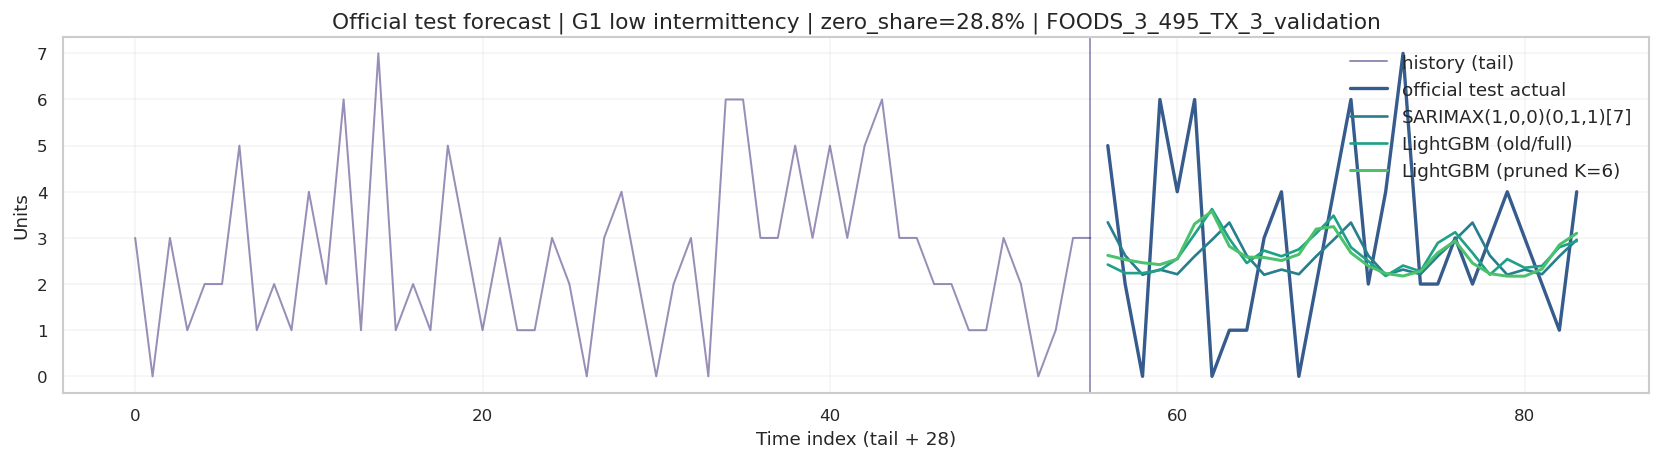

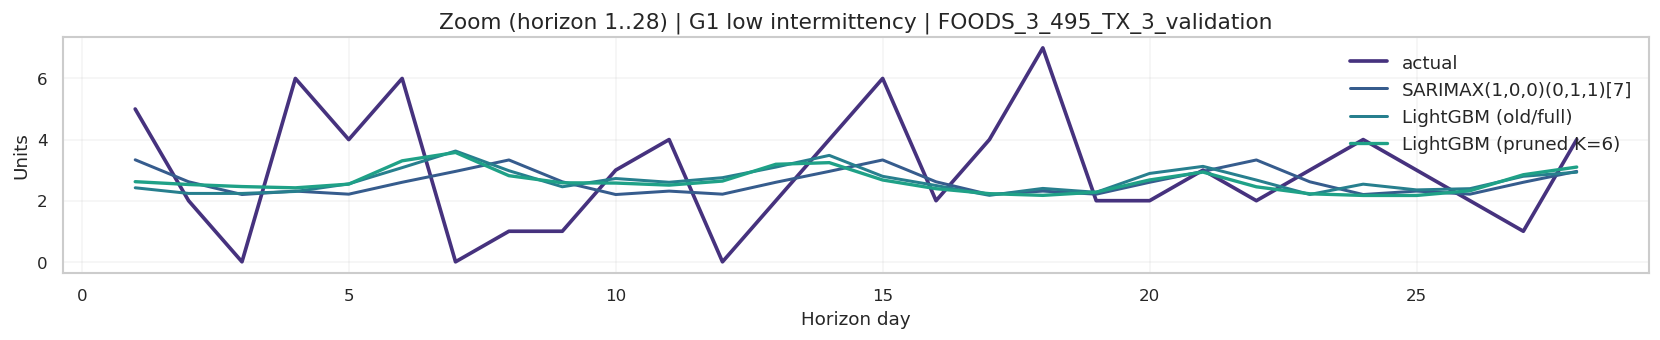

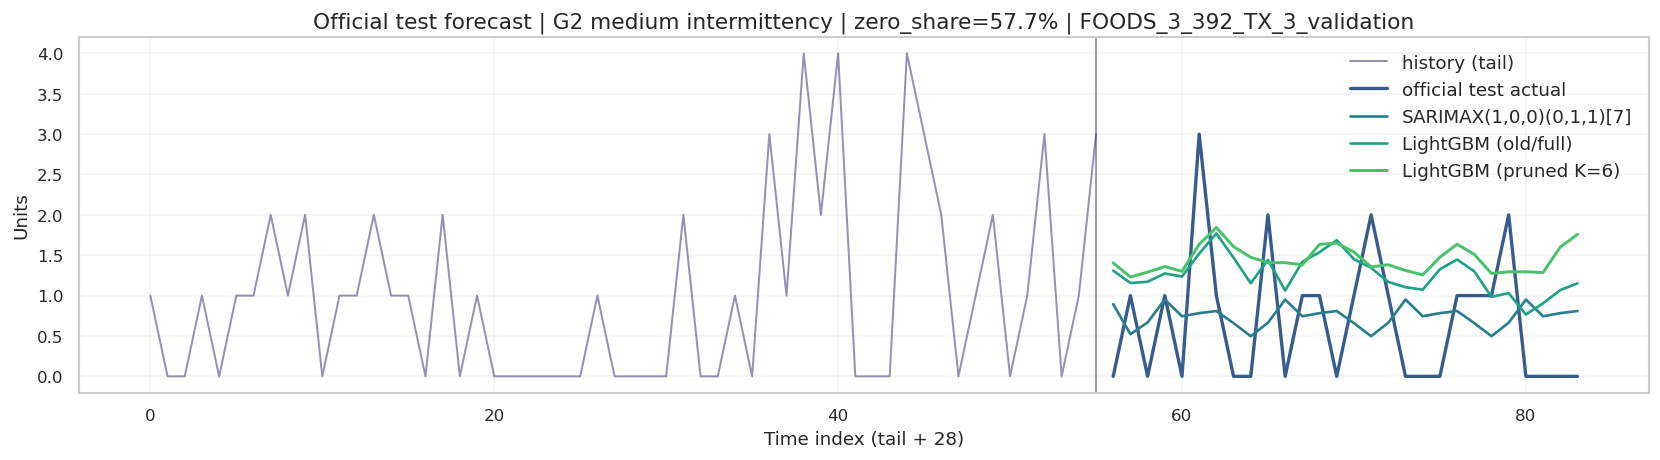

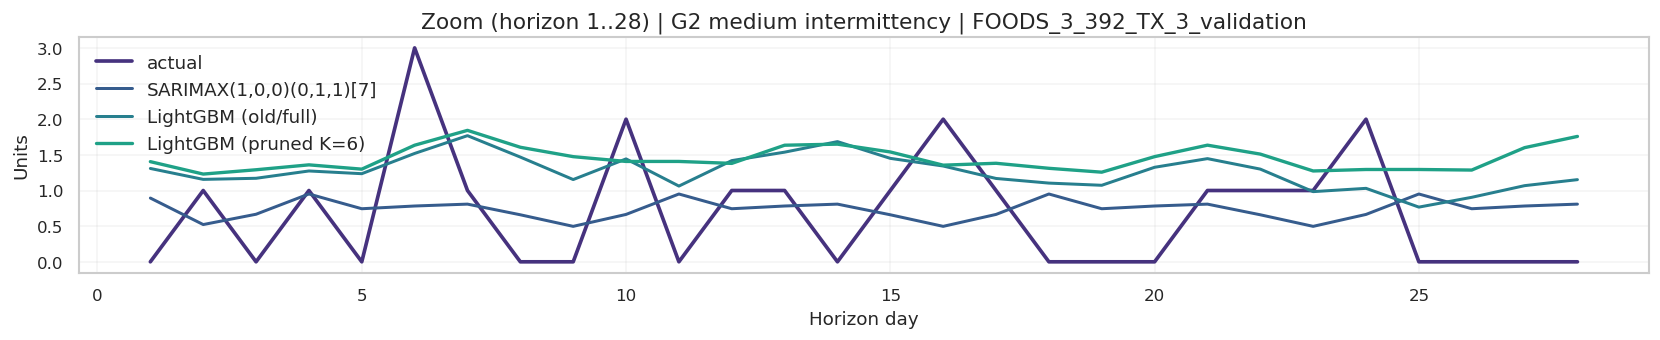

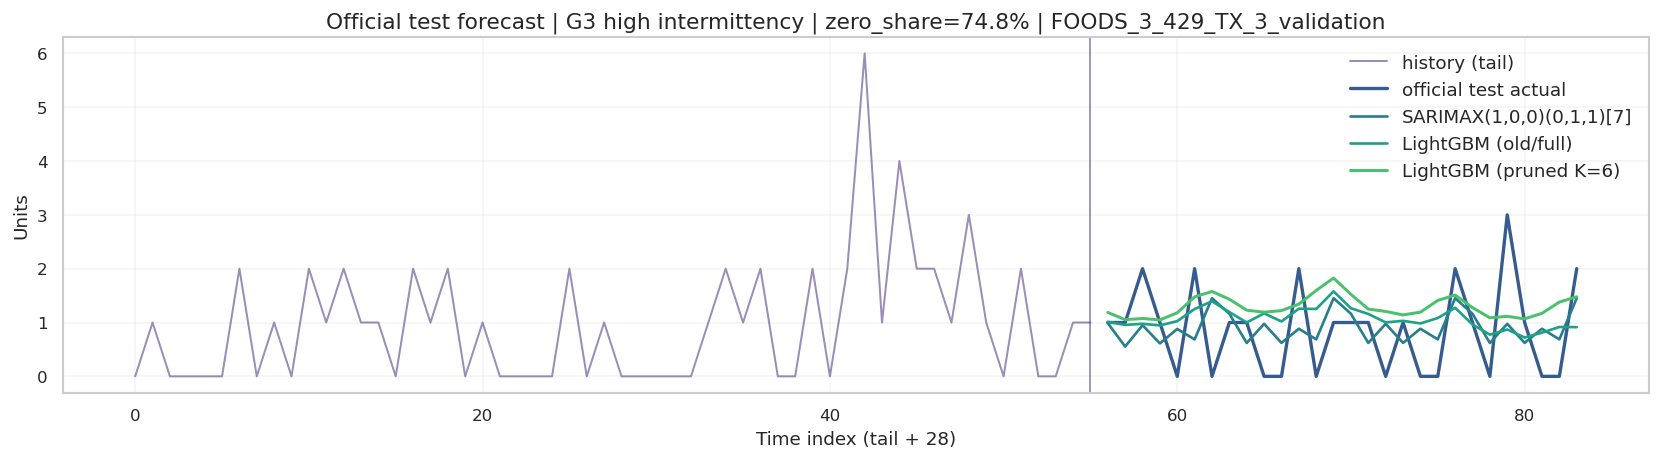

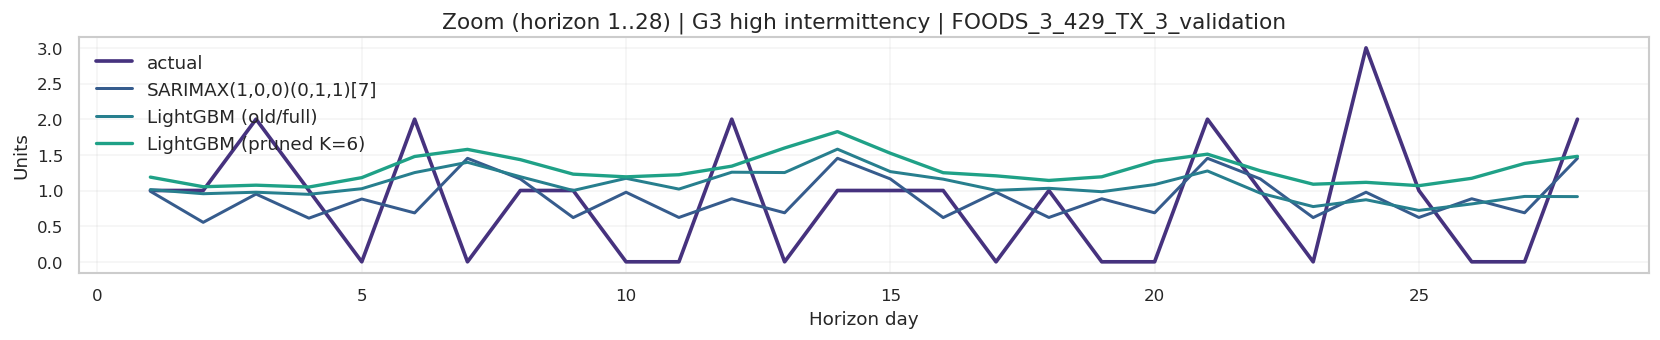

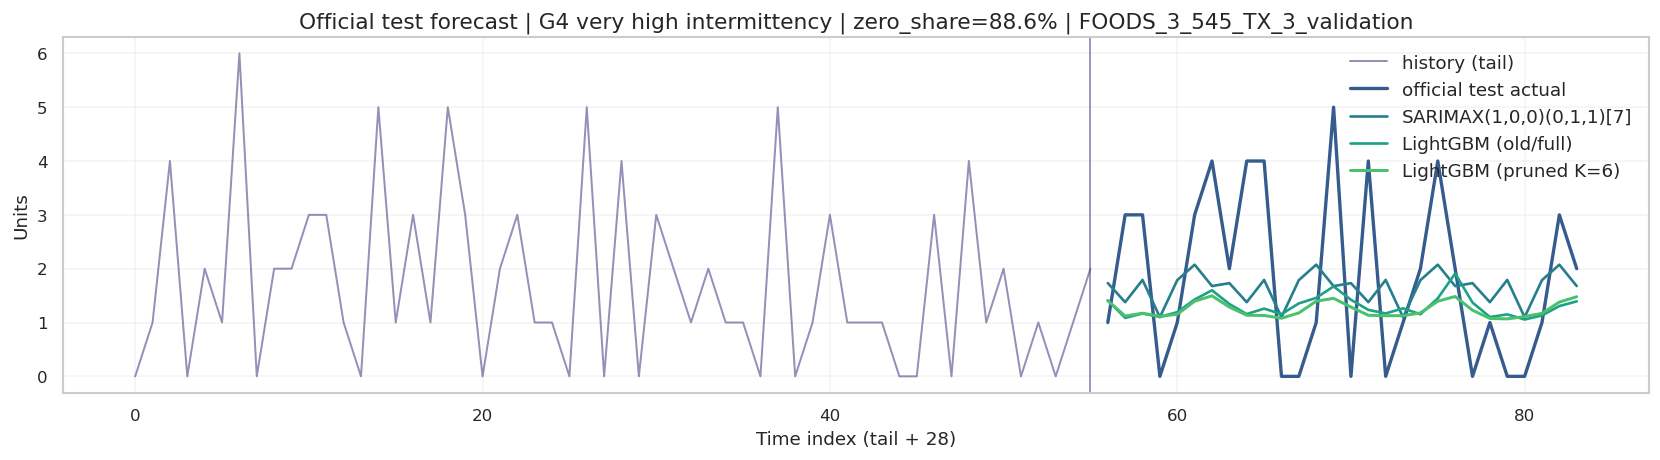

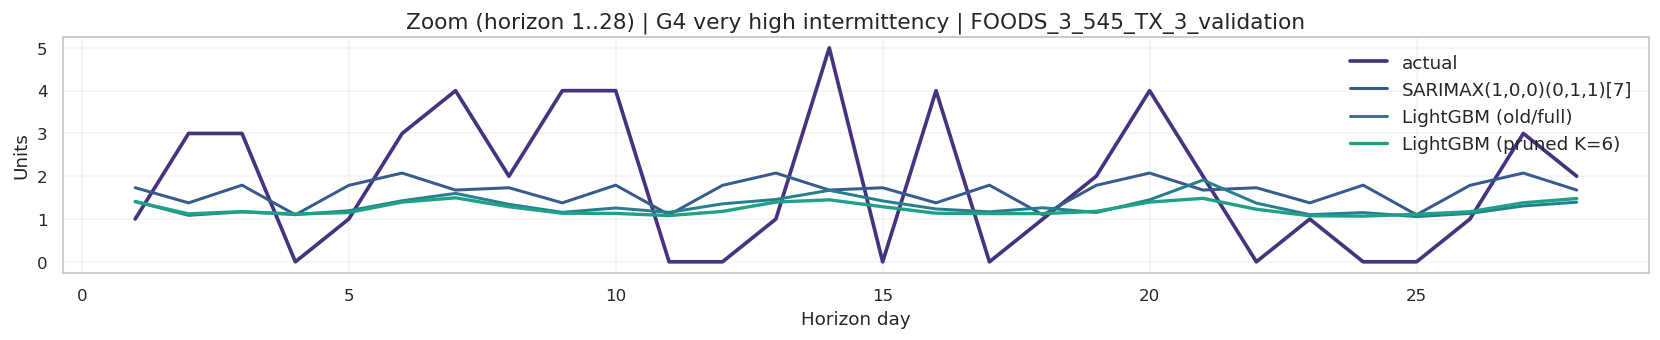

Done. Baseline is SARIMAX everywhere, and pruned stays K=6 with roll features + leakage-safe recursion.


In [ ]:



Y_true = test_wide.reindex(index=ids, columns=test_d_cols).to_numpy(dtype=float)

models = {
    baseline_name: baseline_pred_wide,
    "LightGBM (old/full)": pred_full,
    "LightGBM (pruned K=6)": pred_pruned,
}

overall_rows = []
for name, pw in models.items():
    pw = pw.reindex(index=ids, columns=test_d_cols)
    Y_hat = pw.to_numpy(dtype=float)
    overall_rows.append({"Model": name, "RMSE": rmse(Y_true, Y_hat), "MAE": mae(Y_true, Y_hat)})

overall_tbl = pd.DataFrame(overall_rows).sort_values("RMSE")
print("\nOverall FINAL evaluation (official test d_1942..d_1969):")
display(overall_tbl)

group_order = ["G1 low intermittency","G2 medium intermittency","G3 high intermittency","G4 very high intermittency"]
rows = []
for g in group_order:
    ids_g = groups[groups == g].index.astype(str)
    ids_g = ids_g.intersection(ids)

    if len(ids_g) == 0:
        continue

    Yg_true = test_wide.loc[ids_g, test_d_cols].to_numpy(dtype=float)

    for name, pw in models.items():
        Yg_hat = pw.loc[ids_g, test_d_cols].to_numpy(dtype=float)
        rows.append({
            "group": g,
            "n_items": int(len(ids_g)),
            "zero_share_mean": float(pd.Series(zero_share, index=zero_share.index.astype(str)).loc[ids_g].mean()),
            "model": name,
            "RMSE": rmse(Yg_true, Yg_hat),
            "MAE": mae(Yg_true, Yg_hat),
        })

group_tbl_long = pd.DataFrame(rows).sort_values(["group","RMSE"])
print("\nPer-group FINAL evaluation:")
display(group_tbl_long)

print("\nPer-group RMSE (pivot):")
display(group_tbl_long.pivot(index="group", columns="model", values="RMSE"))

print("\nPer-group MAE (pivot):")
display(group_tbl_long.pivot(index="group", columns="model", values="MAE"))


def plot_rep_item_three(item_id: str, group_label: str, zs: float, tail_train_days: int = 56):
    item_id = str(item_id)

    hist_series = (
        sales_long[(sales_long["id"] == item_id) & (sales_long["d_index"] <= cutoff)]
        .sort_values("d_index")["sales"]
    )
    hist_series = pd.to_numeric(hist_series, errors="coerce").fillna(0.0).astype(float).to_numpy()

    train_tail = hist_series[-tail_train_days:] if len(hist_series) > tail_train_days else hist_series
    y_val = test_wide.loc[item_id, test_d_cols].astype(float).to_numpy()

    pb = models[baseline_name].loc[item_id, test_d_cols].astype(float).to_numpy()
    pf = models["LightGBM (old/full)"].loc[item_id, test_d_cols].astype(float).to_numpy()
    pp = models["LightGBM (pruned K=6)"].loc[item_id, test_d_cols].astype(float).to_numpy()

    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(14, 4))
    plt.plot(x_train, train_tail, linewidth=1.2, alpha=0.55, label="history (tail)")
    plt.plot(x_val, y_val, linewidth=2.0, label="official test actual")
    plt.plot(x_val, pb, linewidth=1.6, label=baseline_name)
    plt.plot(x_val, pf, linewidth=1.6, label="LightGBM (old/full)")
    plt.plot(x_val, pp, linewidth=1.8, label="LightGBM (pruned K=6)")
    plt.axvline(x=len(train_tail)-1, linewidth=1.0, alpha=0.6)
    plt.title(f"Official test forecast | {group_label} | zero_share={zs:.1%} | {item_id}")
    plt.xlabel("Time index (tail + 28)")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    h = len(y_val)
    xs = np.arange(1, h + 1)
    plt.figure(figsize=(14, 3))
    plt.plot(xs, y_val, linewidth=2.2, label="actual")
    plt.plot(xs, pb, linewidth=1.8, label=baseline_name)
    plt.plot(xs, pf, linewidth=1.8, label="LightGBM (old/full)")
    plt.plot(xs, pp, linewidth=2.0, label="LightGBM (pruned K=6)")
    plt.title(f"Zoom (horizon 1..{h}) | {group_label} | {item_id}")
    plt.xlabel("Horizon day")
    plt.ylabel("Units")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

for g, rid, zs in rep_items:
    plot_rep_item_three(rid, g, zs, tail_train_days=56)

print("Done. Baseline is SARIMAX everywhere, and pruned stays K=6 with roll features + leakage-safe recursion.")

overall_tbl.to_csv("results_overall_test.csv", index=False)
group_tbl_long.to_csv("results_group_test_long.csv", index=False)

group_tbl_long.pivot(index="group", columns="model", values="RMSE").to_csv(
    "results_group_test_rmse.csv"
)
group_tbl_long.pivot(index="group", columns="model", values="MAE").to_csv(
    "results_group_test_mae.csv"
)


### Alignment check (sanity safeguard)

Before scoring, we force **all** prediction matrices to have the exact same item order (`ids`) and the same 28 test-day columns (`test_d_cols`).  
`align_wide()` reindexes each wide table and raises an error if any **NaNs remain after alignment**, which would indicate missing predictions or misalignment.  
If this prints the shapes without error, we know `Y_true` and every model forecast are directly comparable cell-by-cell.


In [28]:
def align_wide(name, wide, ref_index, ref_cols):
    wide = wide.copy()
    wide.index = wide.index.astype(str)
    wide = wide.reindex(index=ref_index.astype(str), columns=ref_cols)
    if wide.isna().any().any():
        n = int(wide.isna().sum().sum())
        raise ValueError(f"[{name}] has NaNs AFTER alignment. Total NaNs={n}. This is misalignment or missing preds.")
    return wide.astype(float)

ids = test_wide.index.astype(str)

Y_true_wide = align_wide("Y_true", test_wide, ids, test_d_cols)

models_wide = {
    "SARIMAX": align_wide("SARIMAX", baseline_pred_wide, ids, test_d_cols),
    "LightGBM (old/full)": align_wide("LGBM full", pred_full, ids, test_d_cols),
    "LightGBM (pruned K=6)": align_wide("LGBM pruned", pred_pruned, ids, test_d_cols),
}

print("All prediction matrices aligned:", {k: v.shape for k, v in models_wide.items()})


All prediction matrices aligned: {'SARIMAX': (823, 28), 'LightGBM (old/full)': (823, 28), 'LightGBM (pruned K=6)': (823, 28)}


## PLOTS AND DIAGNOSTICS

In [29]:
group_order = ["G1 low intermittency","G2 medium intermittency","G3 high intermittency","G4 very high intermittency"]

def eval_item_level(Y_true_wide, pred_wide):
    yt = Y_true_wide.to_numpy(dtype=float)
    yp = pred_wide.to_numpy(dtype=float)
    return rmse_np(yt, yp), mae_np(yt, yp)

def eval_total_daily(Y_true_wide, pred_wide):
    yt = Y_true_wide.sum(axis=0).to_numpy(dtype=float)  # 28
    yp = pred_wide.sum(axis=0).to_numpy(dtype=float)    # 28
    return rmse_np(yt, yp), mae_np(yt, yp)

def eval_group_daily(Y_true_wide, pred_wide, groups: pd.Series):
    rows = []
    for g in group_order:
        ids_g = groups[groups == g].index.astype(str).intersection(Y_true_wide.index.astype(str))
        yt = Y_true_wide.loc[ids_g].sum(axis=0).to_numpy(dtype=float)
        yp = pred_wide.loc[ids_g].sum(axis=0).to_numpy(dtype=float)
        rows.append({
            "group": g,
            "n_items": int(len(ids_g)),
            "AggRMSE(group/day)": rmse_np(yt, yp),
            "AggMAE(group/day)": mae_np(yt, yp),
        })
    return pd.DataFrame(rows)

print("Eval functions ready.")


Eval functions ready.


### Intermittency summary plot (zero-share by group)

This cell rebuilds a small table that summarizes **intermittency** per group, where intermittency is measured as **zero-share** (the fraction of days with zero sales).

- First, we compute the **25th, 50th, and 75th percentiles** of zero-share across all items. These act as the **quartile cutoffs** used to define groups G1–G4.
- Next, for each group (G1 low → G4 very high), we compute:
  - `n_items`: how many items fall in the group  
  - `zero_share_mean`: the average zero-share of items in that group
- Finally, we plot a bar chart of **mean zero-share per group**, and overlay the quartile cutoffs as dashed horizontal lines.

Interpretation: bars should increase from **G1 → G4**, confirming that the grouping correctly captures increasing intermittency.


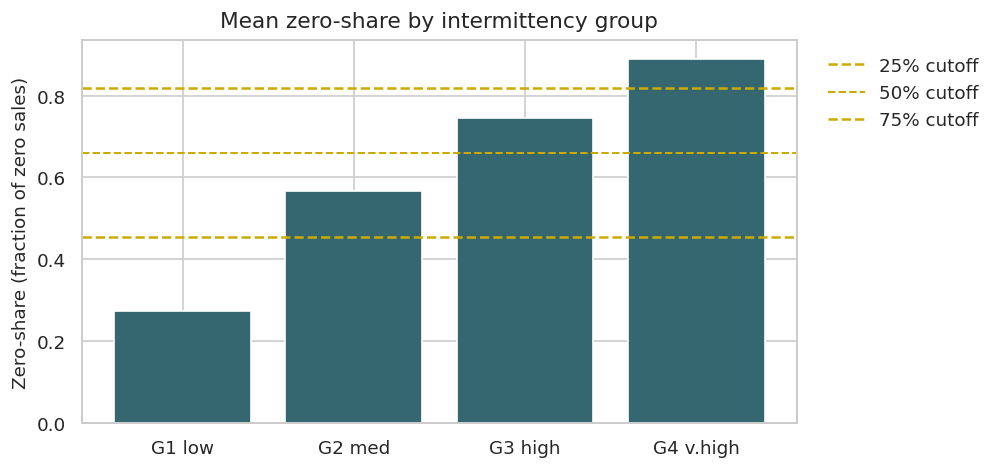

In [30]:
# Rebuild missingness table + cutoffs
q25, q50, q75 = zero_share.quantile([0.25, 0.50, 0.75]).tolist()

rows = []
for g in group_order:
    ids_g = groups[groups == g].index
    zs_g = zero_share.loc[ids_g]
    rows.append({
        "group": g,
        "n_items": int(len(ids_g)),
        "zero_share_mean": float(zs_g.mean()),
    })

group_missing_tbl = pd.DataFrame(rows)

# Plot
fig, ax = plt.subplots(figsize=(8.2, 3.8), constrained_layout=True)

label_map = {
    "G1 low intermittency": "G1 low",
    "G2 medium intermittency": "G2 med",
    "G3 high intermittency": "G3 high",
    "G4 very high intermittency": "G4 v.high",
}
x_labels = [label_map[g] for g in group_missing_tbl["group"]]

ax.bar(x_labels, group_missing_tbl["zero_share_mean"], color=GOLD)

ax.axhline(q25, color=BLUEISH, linestyle="--", linewidth=1.5, label="25% cutoff")
ax.axhline(q50, color=BLUEISH, linestyle="--",  linewidth=1.2, label="50% cutoff")
ax.axhline(q75, color=BLUEISH, linestyle="--", linewidth=1.5, label="75% cutoff")

ax.set_title("Mean zero-share by intermittency group", pad=8)
ax.set_ylabel("Zero-share (fraction of zero sales)")

ax.tick_params(axis="both", labelsize=11, width=1.2)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


### Three evaluation views (accumulated error, not averaged)

This cell scores the same 28-day forecasts in three complementary ways, focusing on **accumulated (aggregate) error** rather than “mean RMSE per item”.

1) **Item-level (823 × 28 cells)**  
   Computes RMSE/MAE over the full item-by-day matrix (cell-wise error across all items and all horizons).

2) **Total daily aggregate (28 points)**  
   First **sums sales across all 823 items per day**, producing one 28-point series, then computes RMSE/MAE on these totals.  
   This evaluates how well each model matches the **overall daily demand volume**.

3) **Group daily aggregate (4 × 28 points)**  
   For each intermittency group, we **sum sales across items in the group per day** (one 28-point series per group), then compute RMSE/MAE.  
   This shows which models best match **aggregate group-level demand**.

Finally, the three result tables are printed and exported as separate LaTeX tables for the report.


In [ ]:
# 1) Item-level (823x28)
rows_item = []
for name, pw in models_wide.items():
    r, m = eval_item_level(Y_true_wide, pw)
    rows_item.append({"Model": name, "RMSE_item": r, "MAE_item": m})
item_tbl = pd.DataFrame(rows_item).sort_values("RMSE_item")

# 2) Total daily aggregate (sum over 823 items -> 28 points)
rows_tot = []
for name, pw in models_wide.items():
    r, m = eval_total_daily(Y_true_wide, pw)
    rows_tot.append({"Model": name, "AggRMSE_total_day": r, "AggMAE_total_day": m})
total_tbl = pd.DataFrame(rows_tot).sort_values("AggRMSE_total_day")

# 3) Group aggregated (4 groups, each is 28-point aggregated daily series)
group_tbls = {}
for name, pw in models_wide.items():
    group_tbls[name] = eval_group_daily(Y_true_wide, pw, groups).assign(Model=name)
group_agg_tbl = pd.concat(group_tbls.values(), ignore_index=True).sort_values(["group","AggRMSE(group/day)"])

display(item_tbl)
display(total_tbl)
display(group_agg_tbl)





,Model,RMSE_item,MAE_item
1,LightGBM (old/full),3.432431,1.587710
2,LightGBM (pruned K=6),3.459414,1.625143
0,SARIMAX,3.494202,1.553629


,Model,AggRMSE_total_day,AggMAE_total_day
1,LightGBM (old/full),264.242926,230.607472
2,LightGBM (pruned K=6),280.245047,222.661498
0,SARIMAX,283.984222,242.675909


,group,n_items,AggRMSE(group/day),AggMAE(group/day),Model
8,G1 low intermittency,206,211.768225,172.866457,LightGBM (pruned K=6)
4,G1 low intermittency,206,213.774290,168.316023,LightGBM (old/full)
0,G1 low intermittency,206,253.794568,201.194123,SARIMAX
1,G2 medium intermittency,206,55.489135,43.399087,SARIMAX
5,G2 medium intermittency,206,87.503671,72.479127,LightGBM (old/full)
9,G2 medium intermittency,206,96.575674,83.158896,LightGBM (pruned K=6)
2,G3 high intermittency,205,35.508677,31.302376,SARIMAX
6,G3 high intermittency,205,53.492041,42.844283,LightGBM (old/full)
10,G3 high intermittency,205,72.207749,59.830370,LightGBM (pruned K=6)
3,G4 very high intermittency,206,22.543849,18.699149,SARIMAX



LATEX: item-level
\begin{tabular}{lrr}
\toprule
Model & RMSE_item & MAE_item \\
\midrule
LightGBM (old/full) & 3.432431 & 1.587710 \\
LightGBM (pruned K=6) & 3.459414 & 1.625143 \\
SARIMAX & 3.494202 & 1.553629 \\
\bottomrule
\end{tabular}


LATEX: total daily aggregate
\begin{tabular}{lrr}
\toprule
Model & AggRMSE_total_day & AggMAE_total_day \\
\midrule
LightGBM (old/full) & 264.242926 & 230.607472 \\
LightGBM (pruned K=6) & 280.245047 & 222.661498 \\
SARIMAX & 283.984222 & 242.675909 \\
\bottomrule
\end{tabular}


LATEX: group daily aggregate
\begin{tabular}{lrrrl}
\toprule
group & n_items & AggRMSE(group/day) & AggMAE(group/day) & Model \\
\midrule
G1 low intermittency & 206 & 211.768225 & 172.866457 & LightGBM (pruned K=6) \\
G1 low intermittency & 206 & 213.774290 & 168.316023 & LightGBM (old/full) \\
G1 low intermittency & 206 & 253.794568 & 201.194123 & SARIMAX \\
G2 medium intermittency & 206 & 55.489135 & 43.399087 & SARIMAX \\
G2 medium intermittency & 206 & 87.503671 & 72.

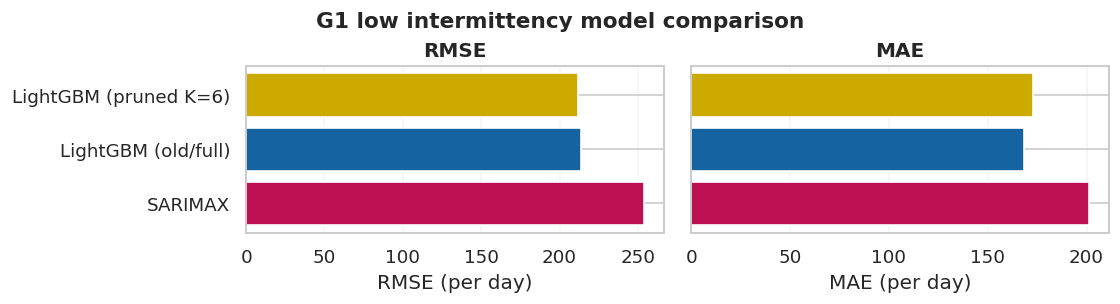

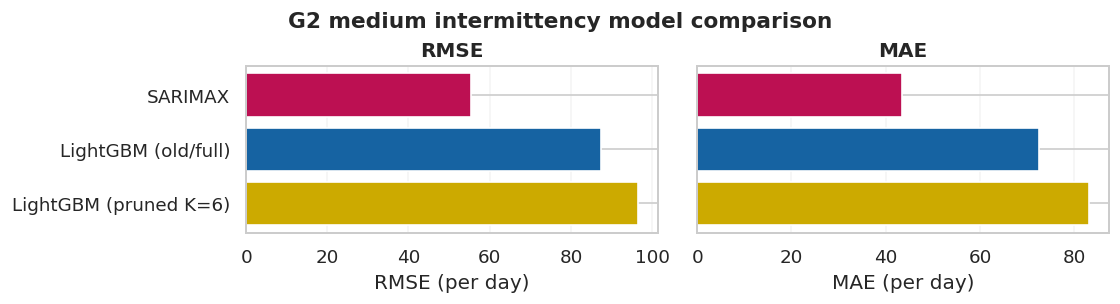

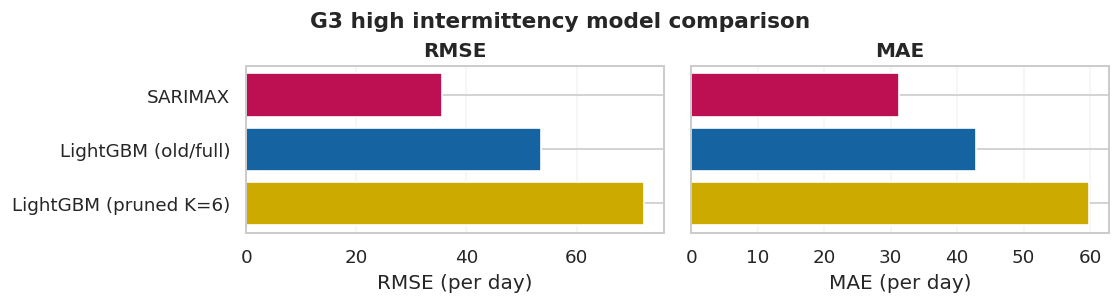

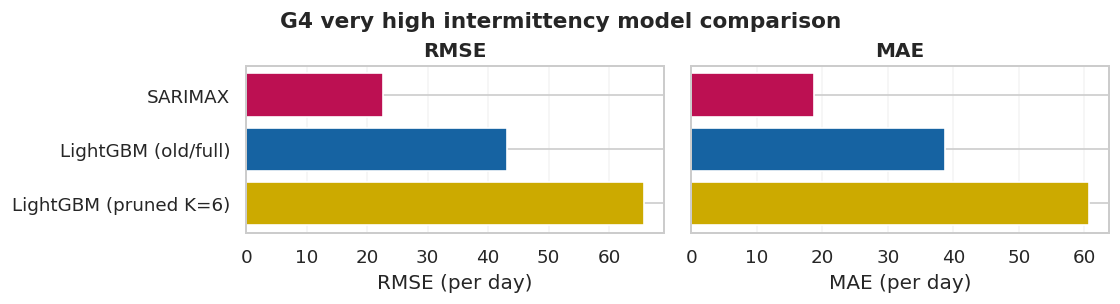

In [33]:
def barplot_rmse_mae(df: pd.DataFrame, out_path: str | None = None):
    df = df.sort_values("AggRMSE(group/day)", ascending=True).copy()
    colors = [MODEL_COLORS.get(m, "gray") for m in df["Model"]]

    fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.8), sharey=True)

    axes[0].barh(df["Model"], df["AggRMSE(group/day)"], color=colors)
    axes[0].invert_yaxis()
    axes[0].set_title("RMSE", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("RMSE (per day)", fontsize=12)
    axes[0].grid(True, axis="x", alpha=0.2)

    axes[1].barh(df["Model"], df["AggMAE(group/day)"], color=colors)
    axes[1].set_title("MAE", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("MAE (per day)", fontsize=12)
    axes[1].grid(True, axis="x", alpha=0.2)

    for ax in axes:
        ax.tick_params(axis="both", labelsize=11, width=1.2)
        ax.xaxis.label.set_size(12)
        ax.yaxis.label.set_size(12)
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

    fig.suptitle(f"{df['group'].iloc[0]} model comparison", y=0.9, fontsize=13, fontweight="bold")
    plt.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

for g in group_order:
    df_g = group_agg_tbl[group_agg_tbl["group"] == g]
    barplot_rmse_mae(df_g, out_path=f"rmse_mae_{g.replace(' ','_').replace('/','_')}.png")


### Bar plots: per-group model comparison (aggregate per-day errors)

For each intermittency group (G1–G4), we create two horizontal bar charts comparing models on:
- **AggRMSE(group/day)**
- **AggMAE(group/day)**

Models are sorted by **lowest aggregate RMSE**, and the figure is saved as a PNG per group.


In [34]:
LGBM_NAME = "LightGBM (pruned K=6)"  # or "LightGBM (old/full)"

rmse_p = group_agg_tbl.pivot(index="group", columns="Model", values="AggRMSE(group/day)").loc[group_order]
mae_p  = group_agg_tbl.pivot(index="group", columns="Model", values="AggMAE(group/day)").loc[group_order]

rmse_p["improve"] = rmse_p["SARIMAX"] - rmse_p[LGBM_NAME]
mae_p["improve"]  = mae_p["SARIMAX"]  - mae_p[LGBM_NAME]


Text(0.5, 1.0, 'MAE improvement')

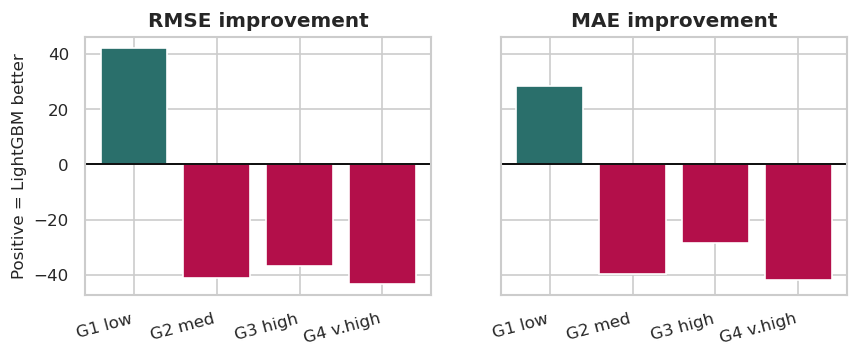

In [35]:
pos_color = "#2a6f6b"  # improvement
neg_color = "#b30f4a"  # worse than SARIMAX

fig, axes = plt.subplots(1, 2, figsize=(8.2, 2.8), sharey=True)

rmse_colors = [pos_color if v >= 0 else neg_color for v in rmse_p["improve"]]
mae_colors  = [pos_color if v >= 0 else neg_color for v in mae_p["improve"]]

axes[0].bar(rmse_p.index, rmse_p["improve"], color=rmse_colors)
axes[0].axhline(0, color="black", linewidth=1.1)
axes[0].set_title("RMSE improvement", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Positive = LightGBM better", fontsize=10)
short_labels = ["G1 low", "G2 med", "G3 high", "G4 v.high"]

axes[0].set_xticks(range(len(short_labels)))
axes[0].set_xticklabels(short_labels, rotation=15, ha="right")

axes[1].set_xticks(range(len(short_labels)))
axes[1].set_xticklabels(short_labels, rotation=15, ha="right")

axes[1].bar(mae_p.index, mae_p["improve"], color=mae_colors)
axes[1].axhline(0, color="black", linewidth=1.1)
axes[1].set_title("MAE improvement", fontsize=12, fontweight="bold")


In [36]:

def residual_diagnostics(resid: np.ndarray, name: str):
    resid = np.asarray(resid, dtype=float)
    print(f"{name} residuals: mean={resid.mean():.4f}, std={resid.std(ddof=0):.4f}")

    max_lag = max(1, len(resid) - 1)
    lags = [7, 14, 28]
    lags = [l for l in lags if l <= max_lag]

    if lags:
        display(acorr_ljungbox(resid, lags=lags, return_df=True))
    else:
        print("Skipping Ljung-Box (series too short).")

    plt.figure(figsize=(8, 3))
    plt.hist(resid, bins=40, alpha=0.8)
    plt.title(f"Residual distribution: {name}")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 3))
    plot_acf(resid, lags=min(28, max_lag), alpha=0.05)
    plt.title(f"Residual ACF: {name}")
    plt.tight_layout()
    plt.show()

### Residual diagnostics and aggregate forecast plots

This section compares model forecasts to the true 28-day test window and runs simple **residual diagnostics** on the **aggregate daily totals**.

- We first align the wide matrices and compute **daily total sales** by summing over items (823 → 28 points).
- For the baseline (SARIMAX) and the recursive tree model, we compute **aggregate residuals**:
  and pass them to `residual_diagnostics(...)` to check for systematic bias / structure left in the errors.

We then plot forecast comparisons using a consistent style:
- **Total daily sales** (aggregated over all 823 items)
- **Per intermittency group totals** (aggregated within G1–G4)
- **Global mean per item per day** (average over items, useful for scale-normalized comparison)

These plots help interpret whether differences in RMSE/MAE come from level shifts, missed peaks, or consistent over/under-forecasting across the horizon.


SARIMAX (aggregate) residuals: mean=169.7834, std=227.6415


,lb_stat,lb_pvalue
7,22.416080,0.002153
14,36.158041,0.000988


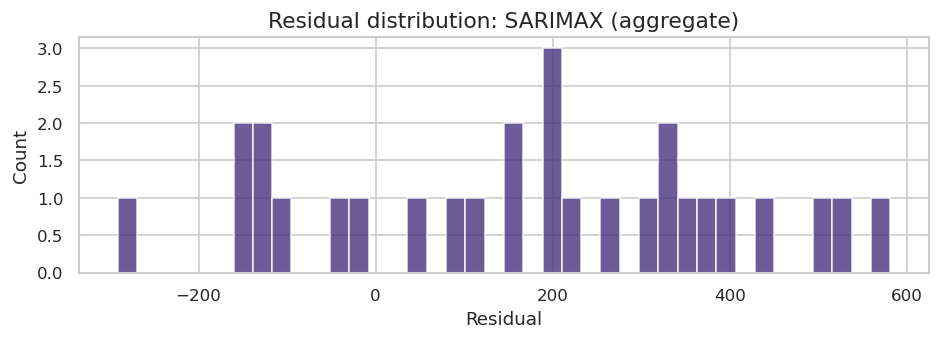

<Figure size 960x360 with 0 Axes>

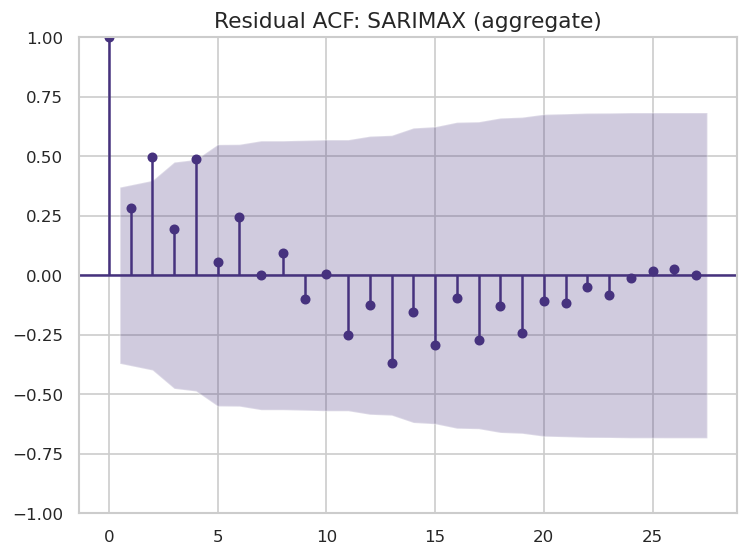

Tree recursive (aggregate) residuals: mean=-121.5806, std=252.4984


,lb_stat,lb_pvalue
7,14.548135,0.042248
14,35.061266,0.001440


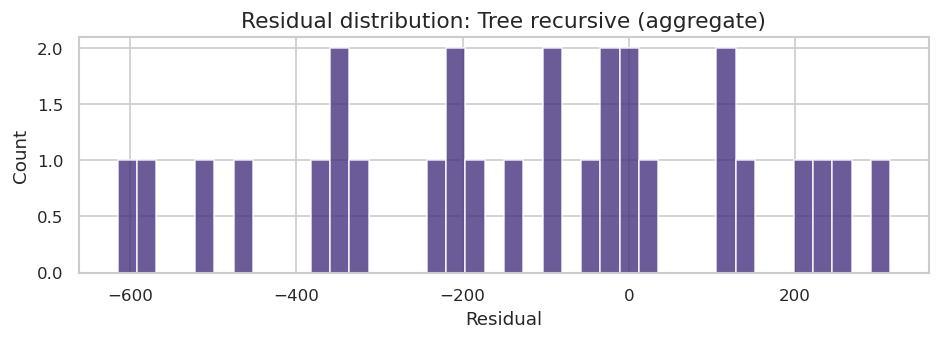

<Figure size 960x360 with 0 Axes>

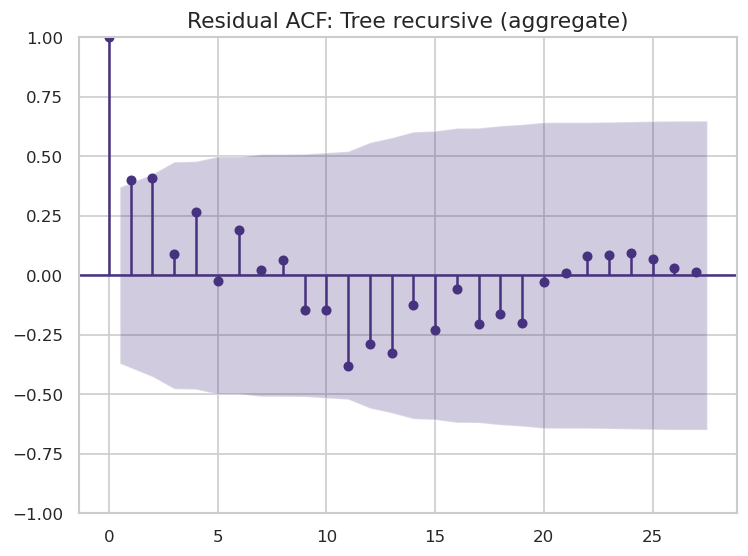

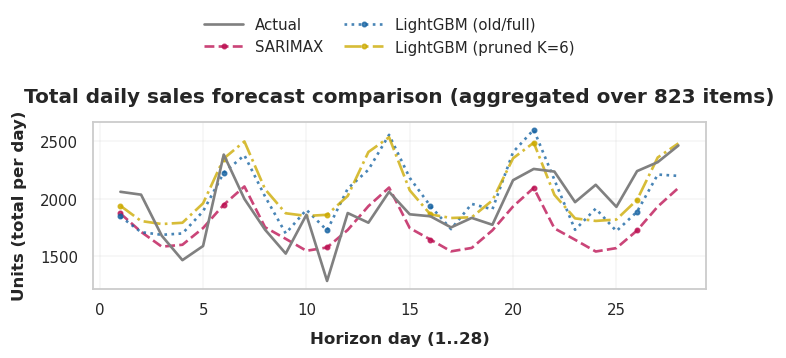

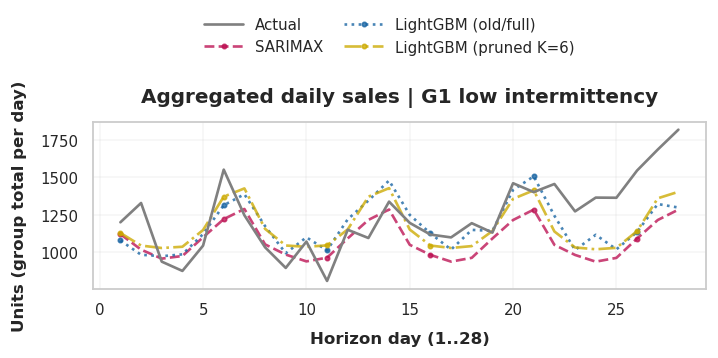

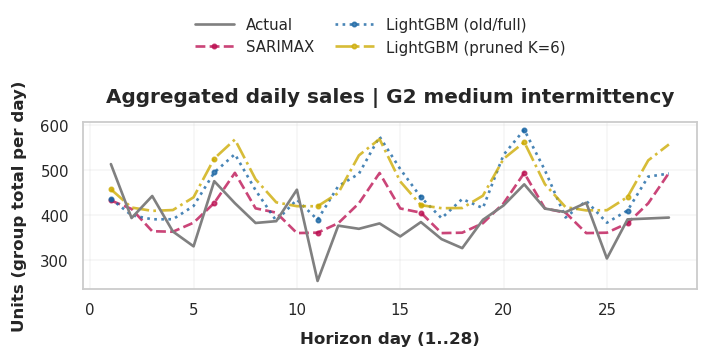

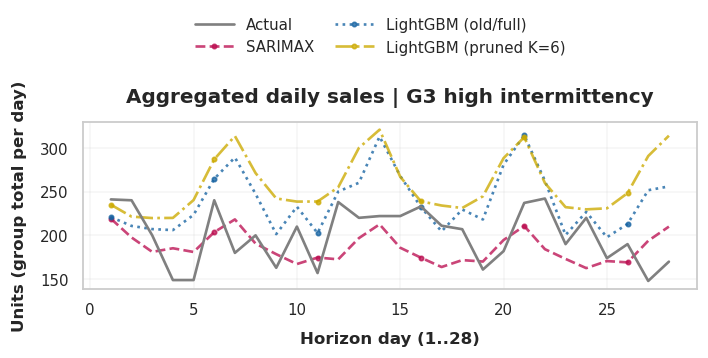

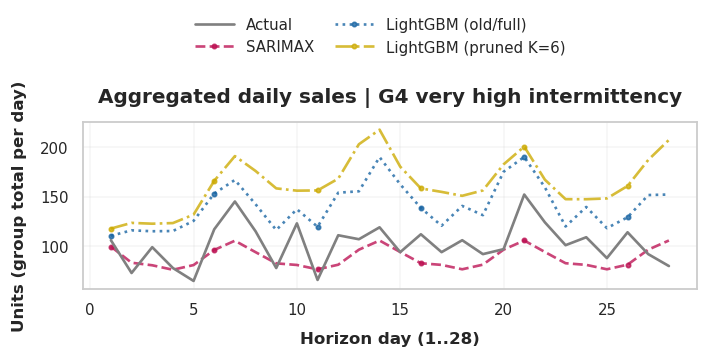

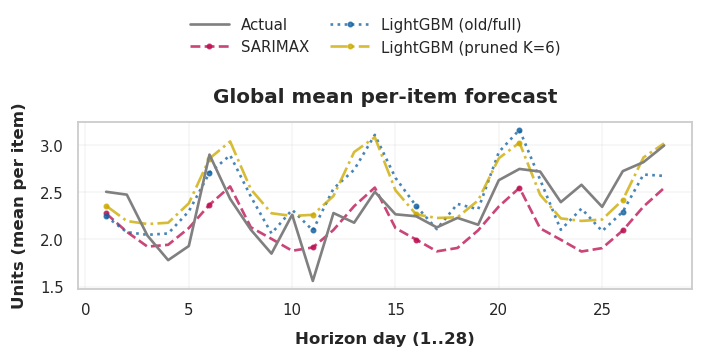

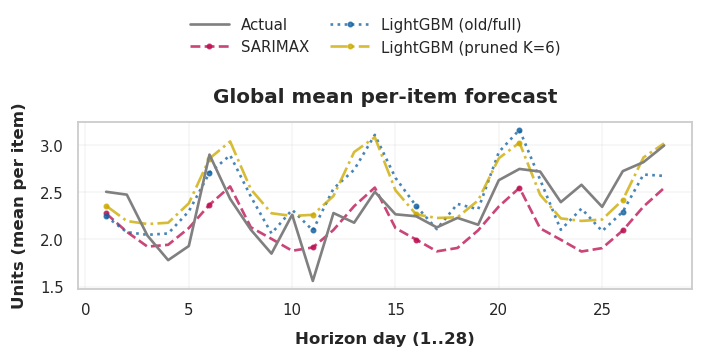

In [ ]:



PLOT_STYLE = {
    "figsize": (6.6, 2.35),   
    "title_size": 12,
    "label_size": 10,
    "tick_size": 9,

    "spine_lw": 1.1,
    "grid_alpha": 0.18,

    "actual_color": "gray",
    "actual_lw": 1.6,
    "actual_alpha": 1.0,
    "actual_zorder": 6,

    "model_lw": 1.6,
    "model_alpha": 0.78,
    "model_zorder": 3,

    "marker_size": 2.6,
    "markevery": 5,

    "legend_fontsize": 9,
    "legend_ncol": 2,     # avoid cramming 4 entries into one tiny row
    "legend_y": 1.12,
    "top_margin": 0.70,
}


LINESTYLES = ["--", ":", "-.", "-"]
MARKERS = ["o", "o", "o", "^", "v", "P", "X", "*"]

# --- restore if missing ---
def plot_series_compare(y_true, preds_dict, title, xlabel="Horizon day (1..28)", ylabel="Units"):
    xs = np.arange(1, len(y_true)+1)
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.plot(xs, y_true, linewidth=2.4, color=GRAY, label="Actual")
    for name, yhat in preds_dict.items():
        ax.plot(xs, yhat, linewidth=2.0, color=MODEL_COLORS.get(name, GRAY), label=name)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.2)
    legend_outside(ax, ncol=1)
    plt.tight_layout()
    plt.show()

# --- residual diagnostics on normal (recursive) outcomes ---
ids = test_wide.index.astype(str)
Y_true_wide = test_wide.reindex(index=ids, columns=test_d_cols)

Y_rec_wide = pred_pruned.reindex(index=ids, columns=test_d_cols)
Y_base_wide = baseline_pred_wide.reindex(index=ids, columns=test_d_cols)

y_true_daily = Y_true_wide.sum(axis=0).to_numpy(dtype=float)
base_daily = Y_base_wide.sum(axis=0).to_numpy(dtype=float)
tree_daily = Y_rec_wide.sum(axis=0).to_numpy(dtype=float)

residual_diagnostics(y_true_daily - base_daily, "SARIMAX (aggregate)")
residual_diagnostics(y_true_daily - tree_daily, "Tree recursive (aggregate)")

def plot_series_compare_big(
    y_true,
    preds_dict,
    title,
    xlabel="Horizon day (1..28)",
    ylabel="Units",
    style=PLOT_STYLE,
):
    y_true = np.asarray(y_true, dtype=float)
    xs = np.arange(1, len(y_true) + 1)

    fig, ax = plt.subplots(figsize=style["figsize"])

    # Actual (thick, black, on top)
    ax.plot(
        xs,
        y_true,
        linewidth=style["actual_lw"],
        color=style["actual_color"],
        label="Actual",
        linestyle="-",
        alpha=style["actual_alpha"],
        zorder=style["actual_zorder"],
    )

    # Models: slightly transparent + consistent differentiation
    names = list(preds_dict.keys())
    for i, name in enumerate(names):
        yhat = np.asarray(preds_dict[name], dtype=float)
        ls = LINESTYLES[i % len(LINESTYLES)]
        mk = MARKERS[i % len(MARKERS)]

        ax.plot(
            xs,
            yhat,
            linewidth=style["model_lw"],
            color=MODEL_COLORS.get(name, "gray"),
            label=name,
            linestyle=ls,
            marker=mk,
            markersize=style["marker_size"],
            markevery=style["markevery"],
            alpha=style["model_alpha"],
            zorder=style["model_zorder"],
        )

    ax.set_title(title, fontsize=style["title_size"], fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=style["label_size"], fontweight="bold", labelpad=8)
    ax.set_ylabel(ylabel, fontsize=style["label_size"], fontweight="bold", labelpad=8)

    ax.tick_params(axis="both", which="major", labelsize=style["tick_size"], width=1.2, length=5)

    for spine in ax.spines.values():
        spine.set_linewidth(style["spine_lw"])

    ax.grid(True, alpha=style["grid_alpha"])

    # Legend on top (figure-level)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, style["legend_y"]),
        ncol=style["legend_ncol"],
        frameon=False,
        fontsize=style["legend_fontsize"],
        handlelength=2.6,
        columnspacing=1.4,
    )

    fig.subplots_adjust(top=style["top_margin"])
    plt.show()


y_true_total = Y_true_wide.sum(axis=0).to_numpy(dtype=float)
preds_total = {name: pw.sum(axis=0).to_numpy(dtype=float) for name, pw in models_wide.items()}

plot_series_compare_big(
    y_true_total,
    preds_total,
    "Total daily sales forecast comparison (aggregated over 823 items)",
    ylabel="Units (total per day)",
)

for g in group_order:
    ids_g = groups[groups == g].index.astype(str).intersection(Y_true_wide.index.astype(str))
    y_true_g = Y_true_wide.loc[ids_g].sum(axis=0).to_numpy(dtype=float)
    preds_g = {name: pw.loc[ids_g].sum(axis=0).to_numpy(dtype=float) for name, pw in models_wide.items()}

    plot_series_compare_big(
        y_true_g,
        preds_g,
        f"Aggregated daily sales | {g}",
        ylabel="Units (group total per day)",
    )
def plot_global_mean_per_day(Y_true_wide, preds_wide_dict, title):
    y_true_mean = Y_true_wide.mean(axis=0).to_numpy(dtype=float)
    preds_mean = {name: pw.mean(axis=0).to_numpy(dtype=float) for name, pw in preds_wide_dict.items()}

    plot_series_compare_big(
        y_true_mean,
        preds_mean,
        title,
        ylabel="Units (mean per item)",
    )

# Example call
plot_global_mean_per_day(
    Y_true_wide,
    models_wide,
    "Global mean per-item forecast",
)



# Example call
plot_global_mean_per_day(
    Y_true_wide,
    models_wide,
    "Global mean per-item forecast",
)


## Interpretation (H1 + H2)

**Aggregate plots:** LightGBM tracks weekly peaks better; SARIMAX is smoother and often sits below peaks. In more intermittent groups, LightGBM tends to overshoot.

**Residuals:** SARIMAX mean residual \(+169.8\) ⇒ systematic under-forecasting. Tree recursive mean residual \(-121.6\) ⇒ systematic over-forecasting. Ljung–Box p-values \(<0.05\) ⇒ residuals are autocorrelated for both, so some structure remains unmodelled.

**Hypotheses:** H1 is partly supported (LightGBM slightly better RMSE, SARIMAX slightly better MAE). H2 is supported: tree helps most in G1–G2 (more systematic demand), while baselines stay strong in high intermittency where near-zero forecasts perform well.


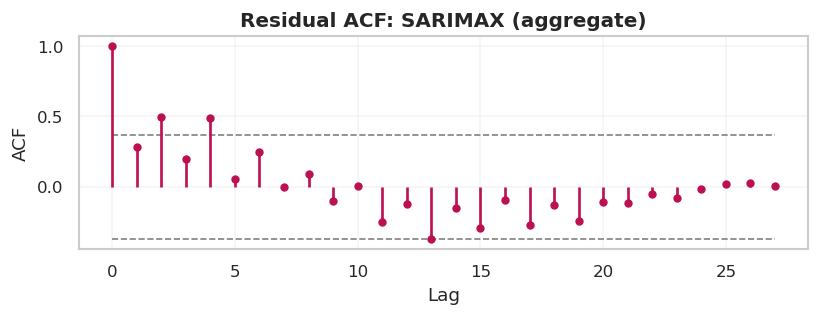

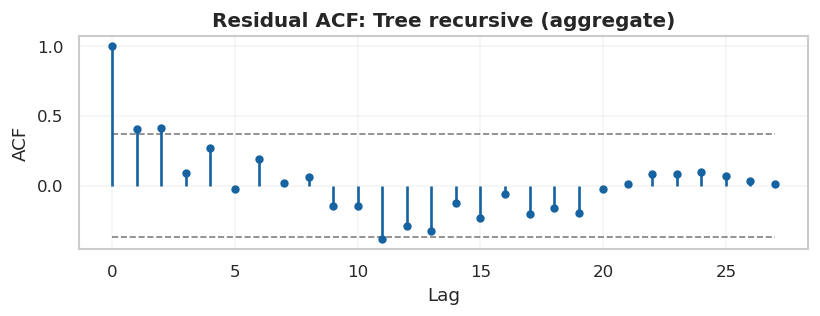

In [38]:
from statsmodels.tsa.stattools import acf

def colored_acf_plot(resid, title, color):
    resid = np.asarray(resid, dtype=float)
    n = len(resid)
    max_lag = min(28, n - 1)
    acf_vals = acf(resid, nlags=max_lag, fft=False)
    lags = np.arange(len(acf_vals))

    # 95% confidence band
    conf = 1.96 / np.sqrt(n)

    plt.figure(figsize=(7.2, 2.8))
    plt.hlines([conf, -conf], xmin=0, xmax=max_lag, colors="0.5", linestyles="--", linewidth=1.0)
    plt.vlines(lags, 0, acf_vals, color=color, linewidth=1.6)
    plt.plot(lags, acf_vals, "o", color=color, markersize=4)

    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Example usage
colored_acf_plot(y_true_daily - base_daily, "Residual ACF: SARIMAX (aggregate)", MAGENTA)
colored_acf_plot(y_true_daily - tree_daily, "Residual ACF: Tree recursive (aggregate)", TEAL)


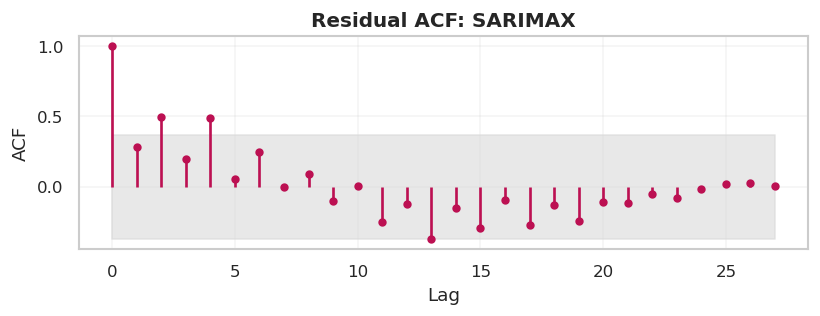

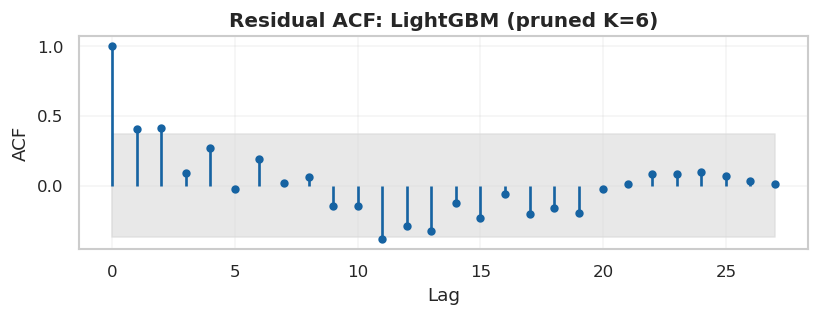

In [39]:
from statsmodels.tsa.stattools import acf

def colored_acf_plot(resid, title, color, max_lag=28, shade=True):
    resid = np.asarray(resid, dtype=float)
    n = len(resid)
    max_lag = min(max_lag, n - 1)
    acf_vals = acf(resid, nlags=max_lag, fft=False)
    lags = np.arange(len(acf_vals))

    conf = 1.96 / np.sqrt(n)

    plt.figure(figsize=(7.2, 2.8))
    if shade:
        plt.fill_between([0, max_lag], [conf, conf], [-conf, -conf], color="0.85", alpha=0.6)
    else:
        plt.hlines([conf, -conf], xmin=0, xmax=max_lag, colors="0.5", linestyles="--", linewidth=1.0)

    plt.vlines(lags, 0, acf_vals, color=color, linewidth=1.6)
    plt.plot(lags, acf_vals, "o", color=color, markersize=4)

    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Example usage with your model names
colored_acf_plot(y_true_daily - base_daily, "Residual ACF: SARIMAX", MAGENTA, shade=True)
colored_acf_plot(y_true_daily - tree_daily, "Residual ACF: LightGBM (pruned K=6)", TEAL, shade=True)


### Why horizon-wise metrics?

Overall RMSE/MAE can hide *where* the error comes from. These plots compute RMSE/MAE **separately for each horizon day (1..28)** to see whether errors **accumulate with lead time**.  
If the recursive tree suffers from rollout error, we expect its curves to **worsen for larger horizons**, while a more stable method stays flatter.


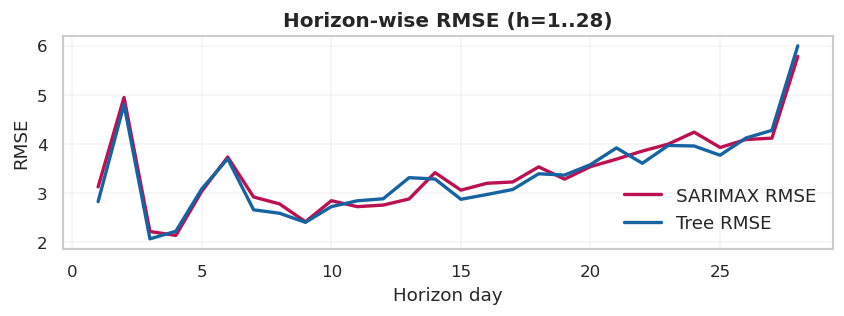

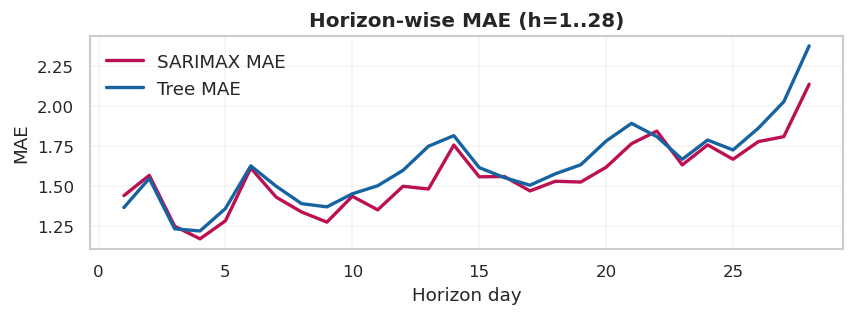

In [40]:
def horizon_metrics(y_true_wide, y_pred_wide):
    yt = y_true_wide.to_numpy(dtype=float)
    yp = y_pred_wide.to_numpy(dtype=float)
    rmse_h = np.sqrt(((yt - yp) ** 2).mean(axis=0))
    mae_h  = np.abs(yt - yp).mean(axis=0)
    return rmse_h, mae_h

rmse_sarimax, mae_sarimax = horizon_metrics(Y_true_wide, baseline_pred_wide)
rmse_tree, mae_tree       = horizon_metrics(Y_true_wide, pred_pruned)

h = np.arange(1, len(rmse_sarimax) + 1)

plt.figure(figsize=(7.2, 2.8))
plt.plot(h, rmse_sarimax, color=MAGENTA, linewidth=2.0, label="SARIMAX RMSE")
plt.plot(h, rmse_tree,    color=TEAL,    linewidth=2.0, label="Tree RMSE")
plt.title("Horizon-wise RMSE (h=1..28)", fontsize=12, fontweight="bold")
plt.xlabel("Horizon day", fontsize=11)
plt.ylabel("RMSE", fontsize=11)
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.2, 2.8))
plt.plot(h, mae_sarimax, color=MAGENTA, linewidth=2.0, label="SARIMAX MAE")
plt.plot(h, mae_tree,    color=TEAL,    linewidth=2.0, label="Tree MAE")
plt.title("Horizon-wise MAE (h=1..28)", fontsize=12, fontweight="bold")
plt.xlabel("Horizon day", fontsize=11)
plt.ylabel("MAE", fontsize=11)
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [43]:
def make_direct_view(sales_long: pd.DataFrame) -> pd.DataFrame:
    df = sales_long.copy()
    df["id"] = df["id"].astype(str)
    df["d_index"] = df["d_index"].astype(int)
    df = df.sort_values(["id","d_index"])

    s = pd.to_numeric(df["sales"], errors="coerce").fillna(0.0)
    df["_sales_clean"] = s

    g = df.groupby("id", sort=False)["_sales_clean"]

    df["lag_1"]  = g.shift(1)
    df["lag_7"]  = g.shift(7)
    df["lag_28"] = g.shift(28)

    s_prev = g.shift(1).fillna(0.0)
    z_prev = (s_prev == 0.0).astype(float)

    for w in [7, 28]:
        df[f"roll_mean_{w}"] = s_prev.groupby(df["id"]).rolling(w, min_periods=w).mean().droplevel(0)
        df[f"roll_sum_{w}"]  = s_prev.groupby(df["id"]).rolling(w, min_periods=w).sum().droplevel(0)
        df[f"roll_std_{w}"]  = s_prev.groupby(df["id"]).rolling(w, min_periods=w).std().droplevel(0)
        df[f"roll_zero_share_{w}"] = z_prev.groupby(df["id"]).rolling(w, min_periods=w).mean().droplevel(0)

    return df.drop(columns=["_sales_clean"])

sales_direct = make_direct_view(sales_long)


In [46]:
# Compare SARIMAX vs pruned/unpruned (recursive + direct)
try:
    TEAL, MAGENTA, GOLD
except NameError:
    TEAL = "#1663A2"
    MAGENTA = "#BC1052"
    GOLD = "#34676F"
required = ["test_wide", "test_d_cols", "baseline_pred_wide", "pred_pruned", "pred_full", "pred_pruned_direct", "pred_full_direct"]
missing = [v for v in required if v not in globals()]
if missing:
    print("Skipping comparison. Missing:", missing)
else:
    ids = test_wide.index.astype(str)
    Y_true_wide = test_wide.reindex(index=ids, columns=test_d_cols)

    models_cmp = {
        "SARIMAX": baseline_pred_wide,
        "Tree recursive (pruned)": pred_pruned,
        "Tree recursive (full)": pred_full
    }

    rows = []
    for name, pw in models_cmp.items():
        pw = pw.reindex(index=ids, columns=test_d_cols)
        rows.append({
            "Model": name,
            "RMSE": rmse(Y_true_wide.to_numpy(), pw.to_numpy()),
            "MAE": mae(Y_true_wide.to_numpy(), pw.to_numpy()),
        })

    display(pd.DataFrame(rows).sort_values("RMSE"))

    # Horizon plots for pruned and full (recursive) vs SARIMAX
    def horizon_metrics_simple(y_true_wide, y_pred_wide):
        yt = y_true_wide.to_numpy(dtype=float)
        yp = y_pred_wide.to_numpy(dtype=float)
        rmse_h = np.sqrt(((yt - yp) ** 2).mean(axis=0))
        mae_h  = np.abs(yt - yp).mean(axis=0)
        return rmse_h, mae_h

    h = np.arange(1, len(test_d_cols) + 1)

    rmse_s, mae_s = horizon_metrics_simple(Y_true_wide, baseline_pred_wide)
    rmse_p, mae_p = horizon_metrics_simple(Y_true_wide, pred_pruned)
    rmse_f, mae_f = horizon_metrics_simple(Y_true_wide, pred_full)

    plt.figure(figsize=(7.2, 2.8))
    plt.plot(h, rmse_s, color=MAGENTA, linewidth=2.0, label="SARIMAX")
    plt.plot(h, rmse_p, color=TEAL, linewidth=2.0, label="Tree pruned (rec)")
    plt.plot(h, rmse_f, color=GOLD, linewidth=2.0, label="Tree full (rec)")
    plt.title("Horizon-wise RMSE (recursive)", fontsize=12, fontweight="bold")
    plt.xlabel("Horizon day")
    plt.ylabel("RMSE")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7.2, 2.8))
    plt.plot(h, mae_s, color=MAGENTA, linewidth=2.0, label="SARIMAX")
    plt.plot(h, mae_p, color=TEAL, linewidth=2.0, label="Tree pruned (rec)")
    plt.plot(h, mae_f, color=GOLD, linewidth=2.0, label="Tree full (rec)")
    plt.title("Horizon-wise MAE (recursive)", fontsize=12, fontweight="bold")
    plt.xlabel("Horizon day")
    plt.ylabel("MAE")
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


Skipping comparison. Missing: ['pred_pruned_direct', 'pred_full_direct']


In [58]:
from pathlib import Path
import pandas as pd
import numpy as np

SUB_DIR = Path("data/submissions")
SUB_DIR.mkdir(parents=True, exist_ok=True)

sample_path = Path("data/sample_submission_afcs2025.csv")
sample_sub = pd.read_csv(sample_path)
sub_cols = sample_sub.columns.tolist()  # id, F1..F28

preds = {}
if "baseline_pred_wide" in globals():
    preds["sarimax"] = baseline_pred_wide
if "tree_pred_wide_pruned" in globals():
    preds["tree_recursive_pruned"] = pred_pruned
if "tree_pred_wide_full" in globals():
    preds["tree_recursive_full"] = pred_full
if "pred_pruned_direct" in globals():
    preds["tree_direct_single_pruned"] = pred_pruned_direct
if "pred_full_direct" in globals():
    preds["tree_direct_single_full"] = pred_full_direct
if "pred_direct_wide" in globals():
    preds["tree_direct_28models"] = pred_direct_wide
if "pred_multi_wide" in globals():
    preds["tree_direct_multioutput"] = pred_multi_wide
if "pred_boosted_wide" in globals():
    preds["sarimax_residual_boost"] = pred_boosted_wide

for name, wide in preds.items():
    wide = wide.copy()
    wide.index = wide.index.astype(str)

    
    if set(wide.columns) != set(sample_sub.columns[1:]):
        if "test_d_cols" in globals():
            wide = wide.reindex(index=sample_sub["id"].astype(str), columns=test_d_cols)
        else:
            wide = wide.reindex(index=sample_sub["id"].astype(str))
    else:
        wide = wide.reindex(index=sample_sub["id"].astype(str), columns=sample_sub.columns[1:])

    sub = pd.DataFrame(index=sample_sub["id"].astype(str))
    sub["id"] = sub.index
    sub.loc[:, sample_sub.columns[1:]] = wide.to_numpy(dtype=float)

    out_path = SUB_DIR / f"submission_{name}.csv"
    sub.reset_index(drop=True).to_csv(out_path, index=False)
    print("Wrote:", out_path)


Wrote: data/submissions/submission_sarimax.csv
Wrote: data/submissions/submission_tree_recursive_pruned.csv
Wrote: data/submissions/submission_tree_recursive_full.csv


## Submission (best model)
Selects best test model and writes a submission file.


In [60]:

if "pred_pruned" not in globals():
    pred_pruned = pd.read_csv("preds_lightgbm_pruned_test.csv", index_col=0)
if "pred_full" not in globals():
    pred_full = pd.read_csv("preds_lightgbm_full_test.csv", index_col=0)

# align to current test ids/columns
pred_pruned = pred_pruned.reindex(index=test_wide.index.astype(str), columns=test_d_cols)
pred_full = pred_full.reindex(index=test_wide.index.astype(str), columns=test_d_cols)

SUB_DIR = Path("data/submissions")
SUB_DIR.mkdir(parents=True, exist_ok=True)

sample_sub = pd.read_csv("data/sample_submission_afcs2025.csv")
candidates = ["LightGBM (pruned K=6)", "LightGBM (old/full)"]
name_to_pred = {
    "LightGBM (pruned K=6)": pred_pruned,
    "LightGBM (old/full)": pred_full,
}

# pick best by RMSE if overall_tbl exists; else default to pruned
if "overall_tbl" in globals():
    best_row = overall_tbl[overall_tbl["Model"].isin(candidates)].sort_values("RMSE").head(1)
    best_name = best_row["Model"].iloc[0] if not best_row.empty else candidates[0]
else:
    best_name = candidates[0]

wide = name_to_pred[best_name].copy()
wide.index = wide.index.astype(str)

# align to sample ids/cols
if set(wide.columns) != set(sample_sub.columns[1:]):
    wide = wide.reindex(index=sample_sub["id"].astype(str), columns=test_d_cols)
else:
    wide = wide.reindex(index=sample_sub["id"].astype(str), columns=sample_sub.columns[1:])

sub = pd.DataFrame(index=sample_sub["id"].astype(str))
sub["id"] = sub.index
sub.loc[:, sample_sub.columns[1:]] = wide.to_numpy(dtype=float)

out_path = SUB_DIR / f"submission_{best_name.replace(' ', '_').replace('/', '_').lower()}.csv"
sub.reset_index(drop=True).to_csv(out_path, index=False)
print(f"Wrote {out_path} using best model: {best_name}")


Wrote data/submissions/submission_lightgbm_(old_full).csv using best model: LightGBM (old/full)


## Final wrap-up (what WE found and why it is credible)

### H1: Does a tree model beat simple baselines on the 28-day holdout?
Partly. On the official 28-day test window, both LightGBM variants achieve a **slightly lower but comparable RMSE** than SARIMAX (3.43–3.46 vs. 3.49), while **SARIMAX performs marginally better on MAE** (1.55 vs. 1.59–1.63).

Interpretation: the tree models capture some larger deviations (helping RMSE), but they introduce more small day-to-day errors (hurting MAE), consistent with mild over/under-shooting in the aggregate plots.

---

### H2: Who benefits most (by intermittency group)?
The gains are **not uniform** across intermittency groups (defined by training zero-share quartiles).

Per-group comparison (test window):
- **G1 low intermittency:** LightGBM achieves lower RMSE and MAE than SARIMAX (best performance for the tree model), suggesting it benefits most when demand has consistent non-zero signal.
- **G2 medium intermittency:** RMSE improves for LightGBM, while MAE is essentially tied (SARIMAX is very slightly better).
- **G3 high intermittency:** LightGBM improves RMSE, but SARIMAX is clearly better on MAE.
- **G4 very high intermittency:** SARIMAX performs best on both RMSE and MAE; the tree models tend to over-predict small positives on mostly-zero series.

Real-world explanation: as intermittency increases, a near-zero forecasting strategy becomes competitive on MAE. Standard regression trees are not explicitly “zero-aware”, so they can reduce some large misses (RMSE) while producing too many small positive forecasts on zero days (MAE).
